# Q.1

In [1]:
import numpy as np
A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16] ])

In [2]:
#1. Calculate the mean of each row.
r_avg = np.mean(A,axis=1)
# r_avg = A.mean(axis=1)
print("Row means:",r_avg)

Row means: [11.25  9.   14.5  10.5 ]


In [3]:
#2. Replace every element that is greater than its row mean by 1.
A[A > r_avg[:, np.newaxis]] = 1
print(A)

[[ 1  5  8  1]
 [ 7  1  3  1]
 [ 1  9  1  6]
 [10  1  2  1]]


In [4]:
#3. Replace every other element by 0.
for i in range(A.shape[0]):
  for j in range(A.shape[1]):
    if A[i][j] == 1:
      pass
    else:
      A[i][j] = 0
print(A)

[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]


In [5]:
#4. Return the resulting binary matrix.
print("Binary Matrix :")
print(A)

Binary Matrix :
[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]


In [6]:
#5. Also determine which row contains the maximum number of elements above its row mean.
elements = np.sum(A, axis=1)
print("\nNumber of elements above mean per row:", elements)
print("All rows contain 2 elements above its row mean")


Number of elements above mean per row: [2 2 2 2]
All rows contain 2 elements above its row mean


In [7]:
# bmtx = (A > r_avg[:, np.newaxis]).astype(int)
# print("\nResulting binary matrix:")
# print(bmtx)

# Q.2

In [8]:
X = np.array([ [10, 100, 5], [12, 110, 6], [11, 105, 7], [13, 500, 6], [14, 108, 8], [15, 115, 9] ])

In [9]:
#For each column:
#1 Calculate the mean and standard deviation.
col_mean = np.mean(X, axis=0)
col_std = np.std(X, axis=0)
print("Column Means:", col_mean)
print("Column Standard Deviations:", col_std)

Column Means: [ 12.5        173.           6.83333333]
Column Standard Deviations: [  1.70782513 146.31017281   1.34370962]


In [10]:
#2. Identify values satisfying: ∣x−μ∣>2σ
#3. Replace such values with the corresponding column median.
#4. Do this without modifying non-outlier values.
col_median = np.median(X, axis=0)
print("Column Medians:", col_median)
values = list()
for i in range(X.shape[0]):
  for j in range(X.shape[1]):
    if abs(X[i][j] - col_mean[j]) > 2 * col_std[j]:
      values.append(X[i][j])
      X[i][j] = col_median[j]
print("Outliers:", values)

print("modified matrix:")
print(X)


Column Medians: [ 12.5 109.    6.5]
Outliers: [np.int64(500)]
modified matrix:
[[ 10 100   5]
 [ 12 110   6]
 [ 11 105   7]
 [ 13 109   6]
 [ 14 108   8]
 [ 15 115   9]]


# Q.3

In [11]:
import pandas as pd
df = pd.DataFrame({ 'Student': ['A','B','C','D','E','F','G','H'],
'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
'Gender': ['F','M','F','M','M','F','F','M'],
'Marks': [85,72,91,65,78,88,95,70],
'Attendance': [92,81,96,72,85,90,98,75] })

#1. Average marks for each department.
print(df.groupby('Department')['Marks'].mean())
#2. Average marks separately for each (Department, Gender) group.
print(df.groupby(['Department', 'Gender'])['Marks'].mean())
#3. Student with the highest marks in each department.
print(df.loc[df.groupby('Department')['Marks'].idxmax()])
#4. Students whose marks are above their department average.
print(df[df['Marks'] > df.groupby('Department')['Marks'].transform('mean')])
#5. Department having the highest average attendance.
print(df.groupby('Department')['Attendance'].mean().idxmax())


Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64
Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64
  Student Department Gender  Marks  Attendance
6       G        CSE      F     95          98
2       C        ECE      F     91          96
  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
2       C        ECE      F     91          96
5       F        ECE      F     88          90
6       G        CSE      F     95          98
CSE


# Q.4

In [12]:
df = pd.DataFrame({'ID': [101,102,103,101,104,102,105],
'Name': ['A','B','C','A','D','B','E'],
'Age': [20,21,22,20,23,21,24],
'Score': [80,75,90,85,88,75,92]})

# 1. Identify duplicated IDs.
print(df[df.duplicated('ID')])
# 2. For each ID, determine whether its records are identical.
print(df.duplicated())
print('for id = "105", records are identical')
# 3. If multiple records exist for an ID, retain the record having the highest Score.
new_df = df.sort_values('Score', ascending=False).drop_duplicates('ID')
print(df)
# 4. Produce a clean DataFrame containing exactly one record per ID.
clean_df = df.drop_duplicates('ID')
print(clean_df)
# 5. Report how many records were removed.
n = len(df) - len(clean_df)
print(n," Records were removed")

    ID Name  Age  Score
3  101    A   20     85
5  102    B   21     75
0    False
1    False
2    False
3    False
4    False
5     True
6    False
dtype: bool
for id = "105", records are identical
    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
2  103    C   22     90
3  101    A   20     85
4  104    D   23     88
5  102    B   21     75
6  105    E   24     92
    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
2  103    C   22     90
4  104    D   23     88
6  105    E   24     92
2  Records were removed


# Q.5

In [13]:
df = pd.DataFrame({ 'Date': ['2026-01-01','2026-01-02','2026-01-04','2026-01-05','2026-01-08','2026-01-09' ],
'Sales': [100,120,150,130,180,200] })

# 1. Convert Date into a proper datetime column.
df['Date'] = pd.to_datetime(df['Date'])
print(df)
# 2. Detect the missing dates.
min = df['Date'].min()
max = df['Date'].max()
range = pd.date_range(min, max)
missing_dates = range[~range.isin(df['Date'])]
print(missing_dates)
# 3. Reindex the DataFrame to contain every date between the minimum and maximum date.
# 4. Keep missing sales as NaN.
df = df.set_index('Date').reindex(range).rename_axis('Date').reset_index()
print(df)
# 5. Calculate a 3-day rolling average of sales.
df['Rolling_Average'] = df['Sales'].rolling(window=3, min_periods=1).mean()
print(df)
# 6. Identify the date on which the rolling average is maximum.
date = df.loc[df['Rolling_Average'].idxmax()]['Date']
print('maximum rolling average on ',date)

        Date  Sales
0 2026-01-01    100
1 2026-01-02    120
2 2026-01-04    150
3 2026-01-05    130
4 2026-01-08    180
5 2026-01-09    200
DatetimeIndex(['2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[ns]', freq=None)
        Date  Sales
0 2026-01-01  100.0
1 2026-01-02  120.0
2 2026-01-03    NaN
3 2026-01-04  150.0
4 2026-01-05  130.0
5 2026-01-06    NaN
6 2026-01-07    NaN
7 2026-01-08  180.0
8 2026-01-09  200.0
        Date  Sales  Rolling_Average
0 2026-01-01  100.0            100.0
1 2026-01-02  120.0            110.0
2 2026-01-03    NaN            110.0
3 2026-01-04  150.0            135.0
4 2026-01-05  130.0            140.0
5 2026-01-06    NaN            140.0
6 2026-01-07    NaN            130.0
7 2026-01-08  180.0            180.0
8 2026-01-09  200.0            190.0
maximum rolling average on  2026-01-09 00:00:00


# Q.6

In [14]:
P = np.array([ [1,2],[4,6],[7,3],[2,8],[9,5]])
# Calculate squared differences using broadcasting
diff_sq = (P[:,np.newaxis,:] - P[np.newaxis,:,:])**2
dist_sq = np.sum(diff_sq, axis=2)
distance_matrix = np.sqrt(dist_sq)
print("Euclidean Distance Matrix:")
print(distance_matrix)

Euclidean Distance Matrix:
[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]


In [15]:
dist_copy = distance_matrix.copy()
# Find the indices of the maximum value
max_idx = np.unravel_index(np.nanargmax(dist_copy), dist_copy.shape)
# Get the maximum distance value
max_dist = dist_copy[max_idx]
# Extract the points involved
p1_idx, p2_idx = max_idx
p1 = P[p1_idx]
p2 = P[p2_idx]
print("The max Euclidean distance: ",max_dist)
print(f"This occurs between Point {p1_idx} ({p1}) and Point {p2_idx} ({p2}).")

The max Euclidean distance:  8.54400374531753
This occurs between Point 0 ([1 2]) and Point 4 ([9 5]).


# Q.7

Take 10 datasets from kaggle (Tabular datasets e.g. weather dataset, housing dataset, titanic dataset, etc.) Perform exploratory data analysis on the dataset using seaborn , matplotlib. (Draw graphs like bar chart, line chart, scatter plots, etc. and explain the insights). Also clean the dataset accordingly.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
df1 = pd.read_csv('train (1).csv')
df1.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [18]:
print("\n Statistics:")
print(df1.drop(['Id'],axis=1).describe().T)


 Statistics:
                count           mean           std      min        25%  \
MSSubClass     1460.0      56.897260     42.300571     20.0      20.00   
LotFrontage    1201.0      70.049958     24.284752     21.0      59.00   
LotArea        1460.0   10516.828082   9981.264932   1300.0    7553.50   
OverallQual    1460.0       6.099315      1.382997      1.0       5.00   
OverallCond    1460.0       5.575342      1.112799      1.0       5.00   
YearBuilt      1460.0    1971.267808     30.202904   1872.0    1954.00   
YearRemodAdd   1460.0    1984.865753     20.645407   1950.0    1967.00   
MasVnrArea     1452.0     103.685262    181.066207      0.0       0.00   
BsmtFinSF1     1460.0     443.639726    456.098091      0.0       0.00   
BsmtFinSF2     1460.0      46.549315    161.319273      0.0       0.00   
BsmtUnfSF      1460.0     567.240411    441.866955      0.0     223.00   
TotalBsmtSF    1460.0    1057.429452    438.705324      0.0     795.75   
1stFlrSF       1460.0   

In [19]:
print("\nMissing Values:")
missing_values = df1.isnull().sum()
print(missing_values)


Missing Values:
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [20]:
cols_drop = missing_values[missing_values > len(df1) * 0.8].index
df1_cleaned = df1.drop(columns=cols_drop)

for col in ['LotFrontage', 'GarageYrBlt']:
    if col in df1_cleaned:
        df1_cleaned[col] = df1_cleaned[col].fillna(df1_cleaned[col].median())

for col in ['MasVnrType', 'Electrical']:
    if col in df1_cleaned:
        df1_cleaned[col] = df1_cleaned[col].fillna(df1_cleaned[col].mode()[0])

none_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df1_cleaned[none_cols] = df1_cleaned[none_cols].fillna('None')
print(df1_cleaned.isnull().sum())


Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 77, dtype: int64


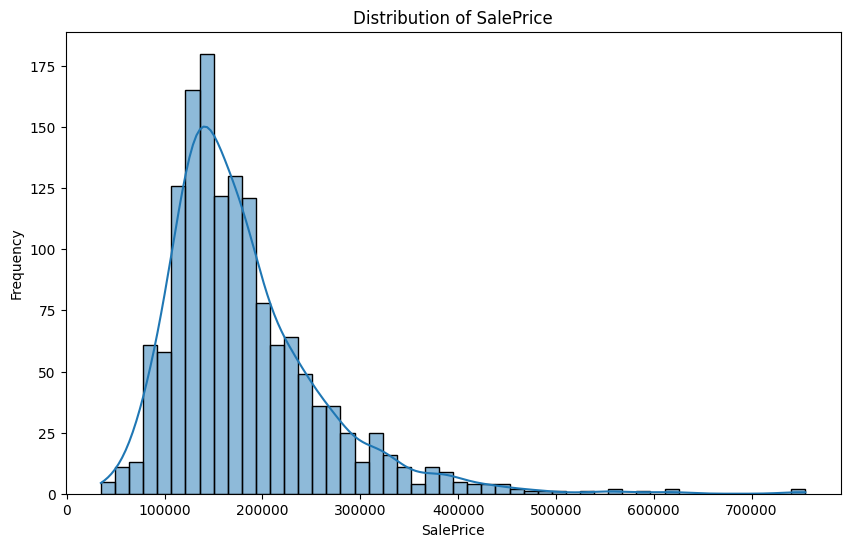

The SalePrice distribution is right-skewed, indicating that most houses are sold at lower prices.


In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df1_cleaned['SalePrice'], kde=True, bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()
print("The SalePrice distribution is right-skewed, indicating that most houses are sold at lower prices.")

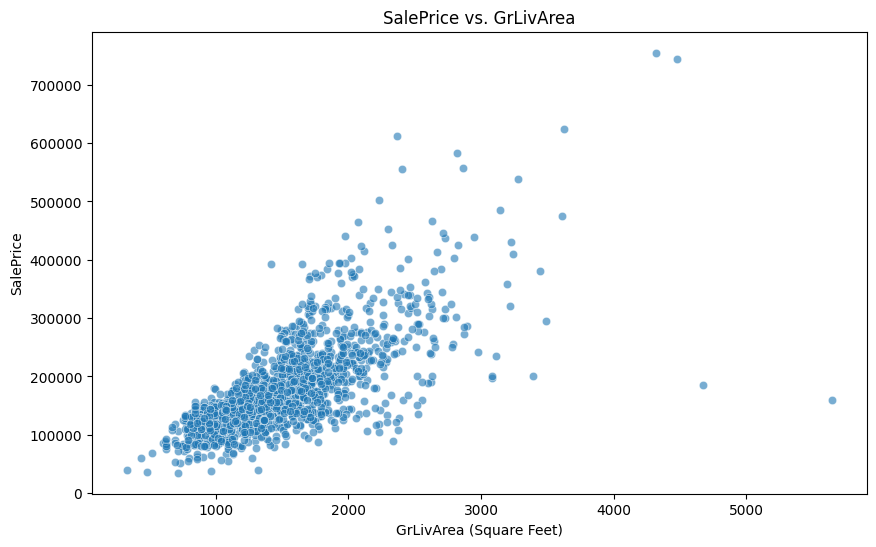

There is a strong positive linear relationship between GrLivArea and SalePrice. Larger living area means higher prices.


In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df1_cleaned, alpha=0.6)
plt.title('SalePrice vs. GrLivArea')
plt.xlabel('GrLivArea (Square Feet)')
plt.ylabel('SalePrice')
plt.show()
print("There is a strong positive linear relationship between GrLivArea and SalePrice. Larger living area means higher prices.")

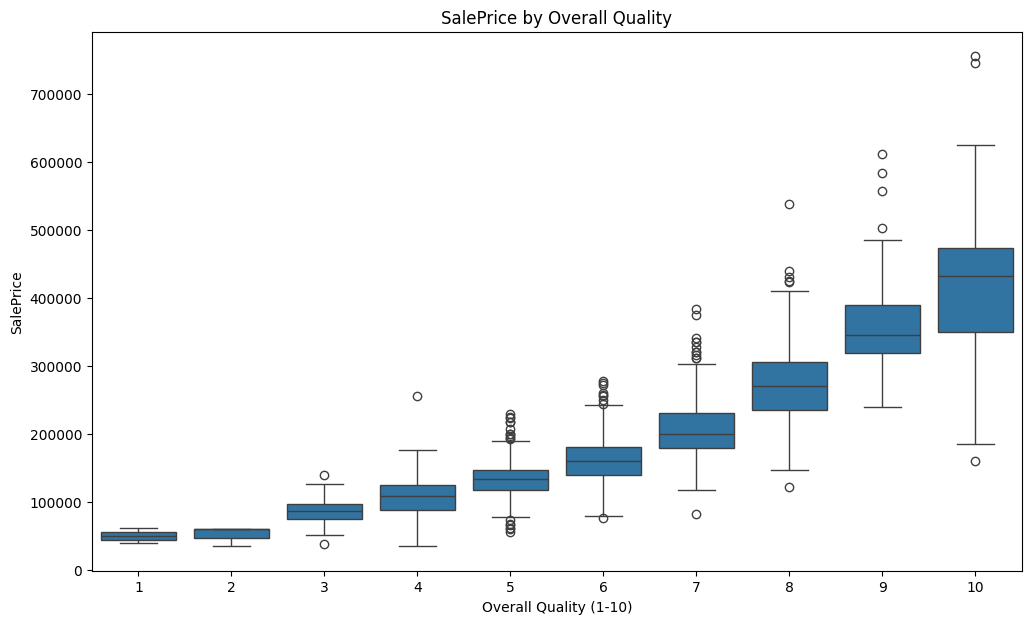

As expected, there is a clear positive trend: higher overall quality ratings are associated with significantly higher median SalePrices and a wider range of prices.


In [23]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='OverallQual', y='SalePrice', data=df1_cleaned)
plt.title('SalePrice by Overall Quality')
plt.xlabel('Overall Quality (1-10)')
plt.ylabel('SalePrice')
plt.show()
print("As expected, there is a clear positive trend: higher overall quality ratings are associated with significantly higher median SalePrices and a wider range of prices.")

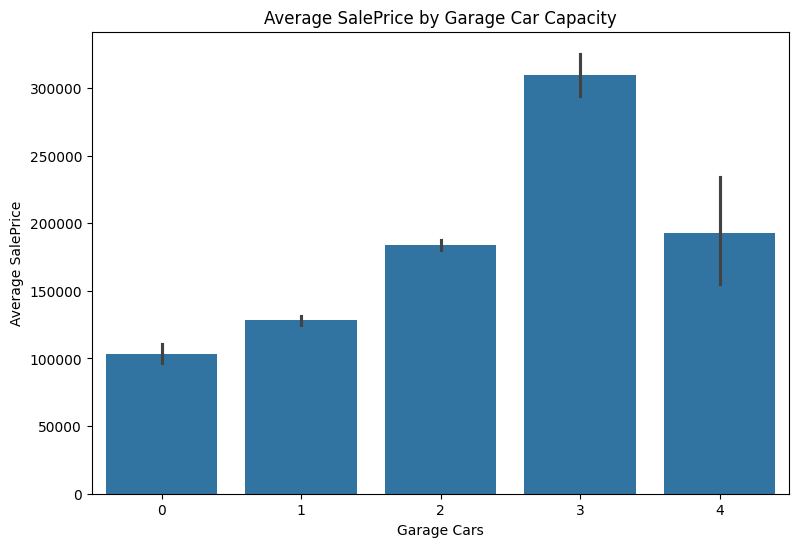

Homes with larger garage capacity tend to have higher average SalePrices.


In [24]:
plt.figure(figsize=(9, 6))
sns.barplot(x='GarageCars', y='SalePrice', data=df1_cleaned)
plt.title('Average SalePrice by Garage Car Capacity')
plt.xlabel('Garage Cars')
plt.ylabel('Average SalePrice')
plt.show()
print("Homes with larger garage capacity tend to have higher average SalePrices.")

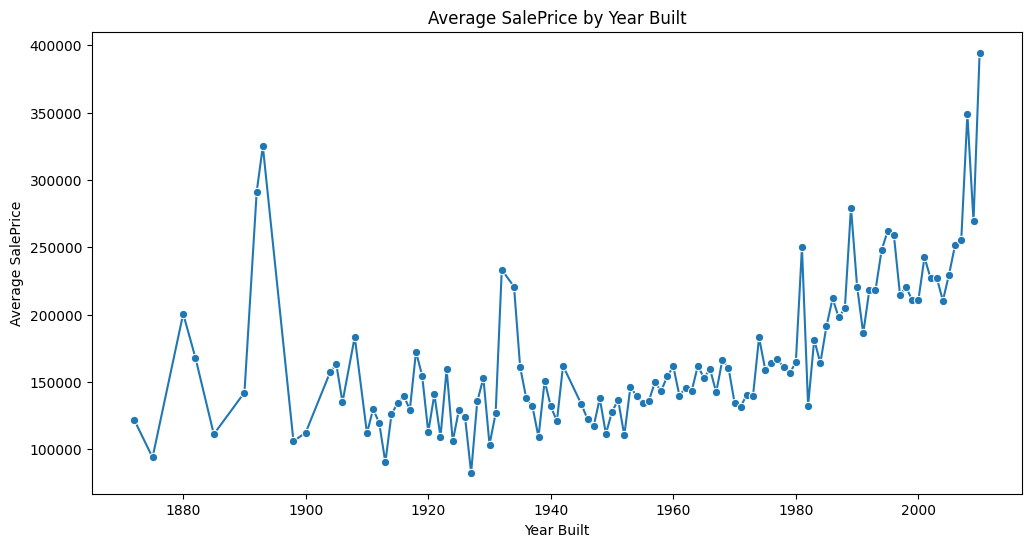

Newer houses tend to have higher average SalePrices, though there are fluctuations. This reflects modernization and better building standards.


In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='YearBuilt', y='SalePrice', data=df1_cleaned.groupby('YearBuilt')['SalePrice'].mean().reset_index(), marker='o')
plt.title('Average SalePrice by Year Built')
plt.xlabel('Year Built')
plt.ylabel('Average SalePrice')
plt.show()
print("Newer houses tend to have higher average SalePrices, though there are fluctuations. This reflects modernization and better building standards.")

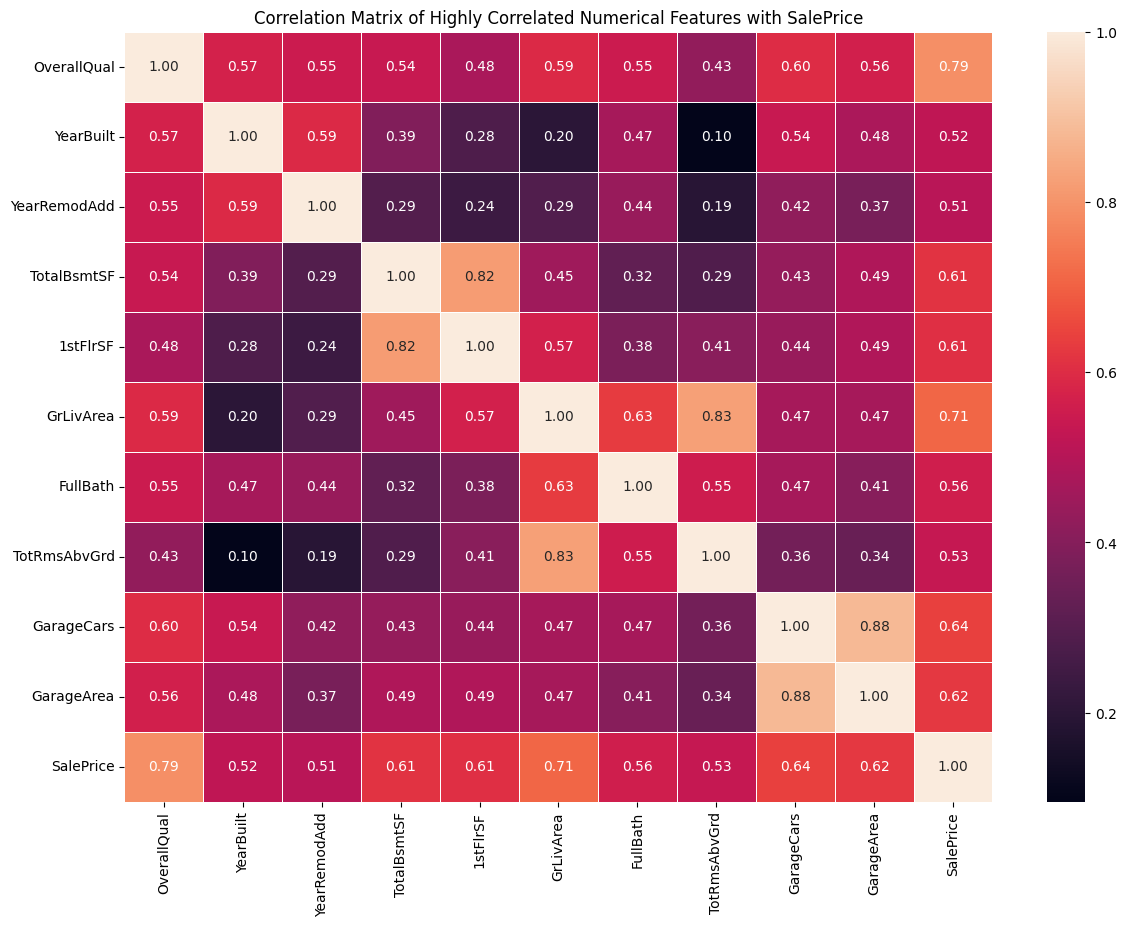

'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', and '1stFlrSF' show strong positive correlations with 'SalePrice'. This confirms their importance as predictors.


In [26]:
plt.figure(figsize=(14, 10))

numerical_cols = df1_cleaned.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df1_cleaned[numerical_cols].corr()
high_corr_features = correlation_matrix.index[abs(correlation_matrix['SalePrice']) > 0.5].tolist()

if 'SalePrice' not in high_corr_features:
    high_corr_features.append('SalePrice')

sns.heatmap(df1_cleaned[high_corr_features].corr(), annot=True, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Highly Correlated Numerical Features with SalePrice')
plt.show()
print("'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', and '1stFlrSF' show strong positive correlations with 'SalePrice'. This confirms their importance as predictors.")

In [27]:
df2 = pd.read_csv("weather.csv")
df2.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,8.0,24.3,0.0,3.4,6.3,NW,30.0,SW,NW,6.0,...,29,1019.7,1015.0,7,7,14.4,23.6,No,3.6,Yes
1,14.0,26.9,3.6,4.4,9.7,ENE,39.0,E,W,4.0,...,36,1012.4,1008.4,5,3,17.5,25.7,Yes,3.6,Yes
2,13.7,23.4,3.6,5.8,3.3,NW,85.0,N,NNE,6.0,...,69,1009.5,1007.2,8,7,15.4,20.2,Yes,39.8,Yes
3,13.3,15.5,39.8,7.2,9.1,NW,54.0,WNW,W,30.0,...,56,1005.5,1007.0,2,7,13.5,14.1,Yes,2.8,Yes
4,7.6,16.1,2.8,5.6,10.6,SSE,50.0,SSE,ESE,20.0,...,49,1018.3,1018.5,7,7,11.1,15.4,Yes,0.0,No


In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        366 non-null    float64
 1   MaxTemp        366 non-null    float64
 2   Rainfall       366 non-null    float64
 3   Evaporation    366 non-null    float64
 4   Sunshine       363 non-null    float64
 5   WindGustDir    363 non-null    object 
 6   WindGustSpeed  364 non-null    float64
 7   WindDir9am     335 non-null    object 
 8   WindDir3pm     365 non-null    object 
 9   WindSpeed9am   359 non-null    float64
 10  WindSpeed3pm   366 non-null    int64  
 11  Humidity9am    366 non-null    int64  
 12  Humidity3pm    366 non-null    int64  
 13  Pressure9am    366 non-null    float64
 14  Pressure3pm    366 non-null    float64
 15  Cloud9am       366 non-null    int64  
 16  Cloud3pm       366 non-null    int64  
 17  Temp9am        366 non-null    float64
 18  Temp3pm   

In [29]:
print("\n Statistics:")
print(df2.describe().T)


 Statistics:
               count         mean        std    min       25%      50%  \
MinTemp        366.0     7.265574   6.025800   -5.3     2.300     7.45   
MaxTemp        366.0    20.550273   6.690516    7.6    15.025    19.65   
Rainfall       366.0     1.428415   4.225800    0.0     0.000     0.00   
Evaporation    366.0     4.521858   2.669383    0.2     2.200     4.20   
Sunshine       363.0     7.909366   3.481517    0.0     5.950     8.60   
WindGustSpeed  364.0    39.840659  13.059807   13.0    31.000    39.00   
WindSpeed9am   359.0     9.651811   7.951929    0.0     6.000     7.00   
WindSpeed3pm   366.0    17.986339   8.856997    0.0    11.000    17.00   
Humidity9am    366.0    72.035519  13.137058   36.0    64.000    72.00   
Humidity3pm    366.0    44.519126  16.850947   13.0    32.250    43.00   
Pressure9am    366.0  1019.709016   6.686212  996.5  1015.350  1020.15   
Pressure3pm    366.0  1016.810383   6.469422  996.8  1012.800  1017.40   
Cloud9am       366.0    

In [30]:
print("\nMissing Values:")
missing_values = df2.isnull().sum()
print(missing_values)


Missing Values:
MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          3
WindGustDir       3
WindGustSpeed     2
WindDir9am       31
WindDir3pm        1
WindSpeed9am      7
WindSpeed3pm      0
Humidity9am       0
Humidity3pm       0
Pressure9am       0
Pressure3pm       0
Cloud9am          0
Cloud3pm          0
Temp9am           0
Temp3pm           0
RainToday         0
RISK_MM           0
RainTomorrow      0
dtype: int64


In [31]:
df2_cleaned = df2.copy()
num_cols = ['Sunshine', 'WindGustSpeed', 'WindSpeed9am']
for col in num_cols:
    if col in df2_cleaned.columns:
        df2_cleaned[col] = df2_cleaned[col].fillna(df2_cleaned[col].median())

cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in cat_cols:
    if col in df2_cleaned.columns:
        df2_cleaned[col] = df2_cleaned[col].fillna(df2_cleaned[col].mode()[0])
print(df2_cleaned.isnull().sum())

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RISK_MM          0
RainTomorrow     0
dtype: int64


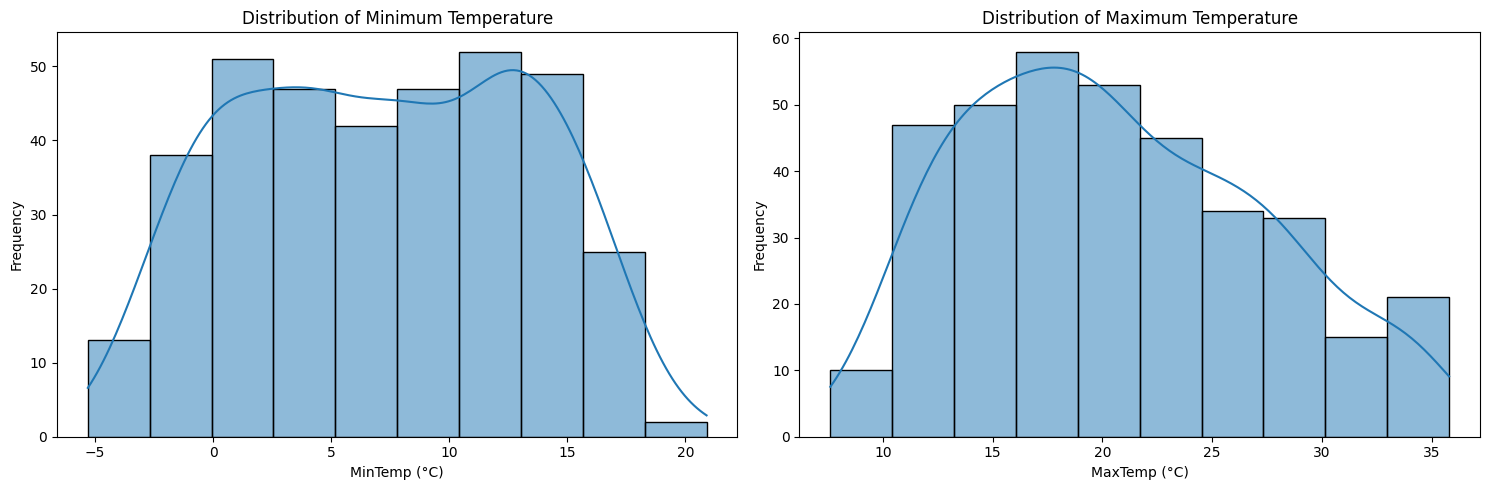

Both MinTemp and MaxTemp show normal distribution. MaxTemp having a wider spread. This suggests a seasonal variation in temperatures.


In [32]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df2_cleaned['MinTemp'], kde=True)
plt.title('Distribution of Minimum Temperature')
plt.xlabel('MinTemp (°C)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df2_cleaned['MaxTemp'], kde=True)
plt.title('Distribution of Maximum Temperature')
plt.xlabel('MaxTemp (°C)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Both MinTemp and MaxTemp show normal distribution. MaxTemp having a wider spread. This suggests a seasonal variation in temperatures.")

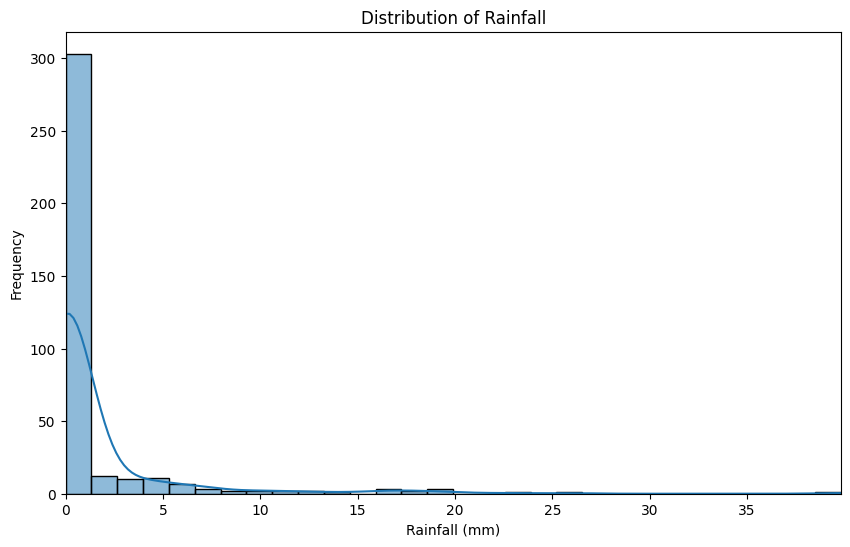

Rainfall is heavily skewed towards zero, indicating many days with no or very little rain. It shows episodic heavy rain events.


In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(df2_cleaned['Rainfall'], bins=30, kde=True)
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.xlim(0, df2_cleaned['Rainfall'].max())
plt.show()
print("Rainfall is heavily skewed towards zero, indicating many days with no or very little rain. It shows episodic heavy rain events.")

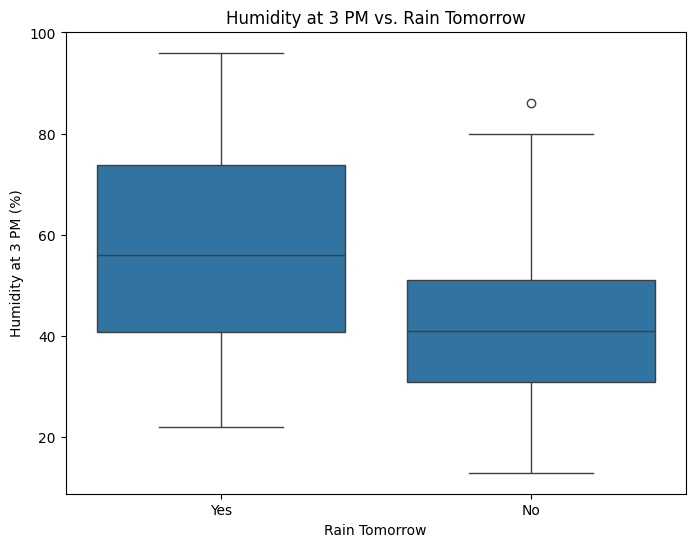

Days followed by rain ('Yes') tend to have significantly higher humidity at 3 PM compared to days not followed by rain ('No').


In [34]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df2_cleaned)
plt.title('Humidity at 3 PM vs. Rain Tomorrow')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Humidity at 3 PM (%)')
plt.show()
print("Days followed by rain ('Yes') tend to have significantly higher humidity at 3 PM compared to days not followed by rain ('No').")

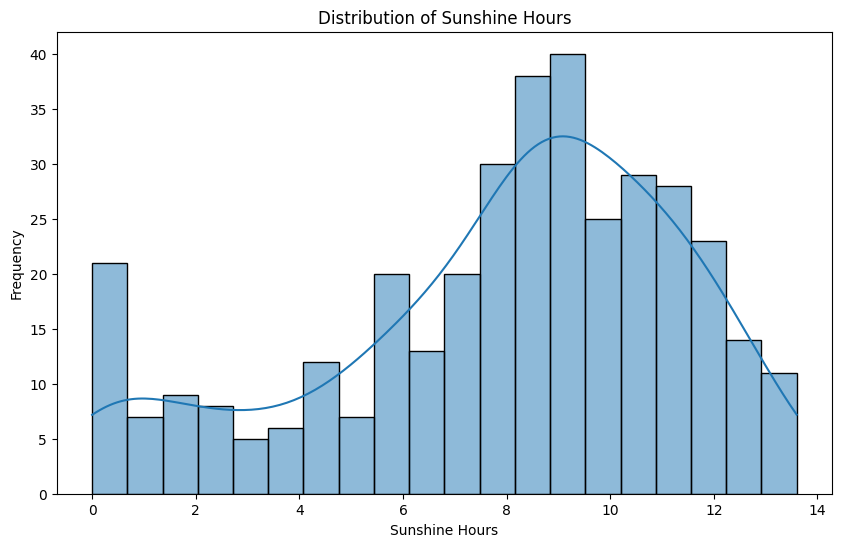

The distribution of Sunshine hours appears somewhat bimodal or flattened, suggesting periods of both very sunny days and less sunny days.


In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df2_cleaned['Sunshine'], kde=True, bins=20)
plt.title('Distribution of Sunshine Hours')
plt.xlabel('Sunshine Hours')
plt.ylabel('Frequency')
plt.show()
print("The distribution of Sunshine hours appears somewhat bimodal or flattened, suggesting periods of both very sunny days and less sunny days.")

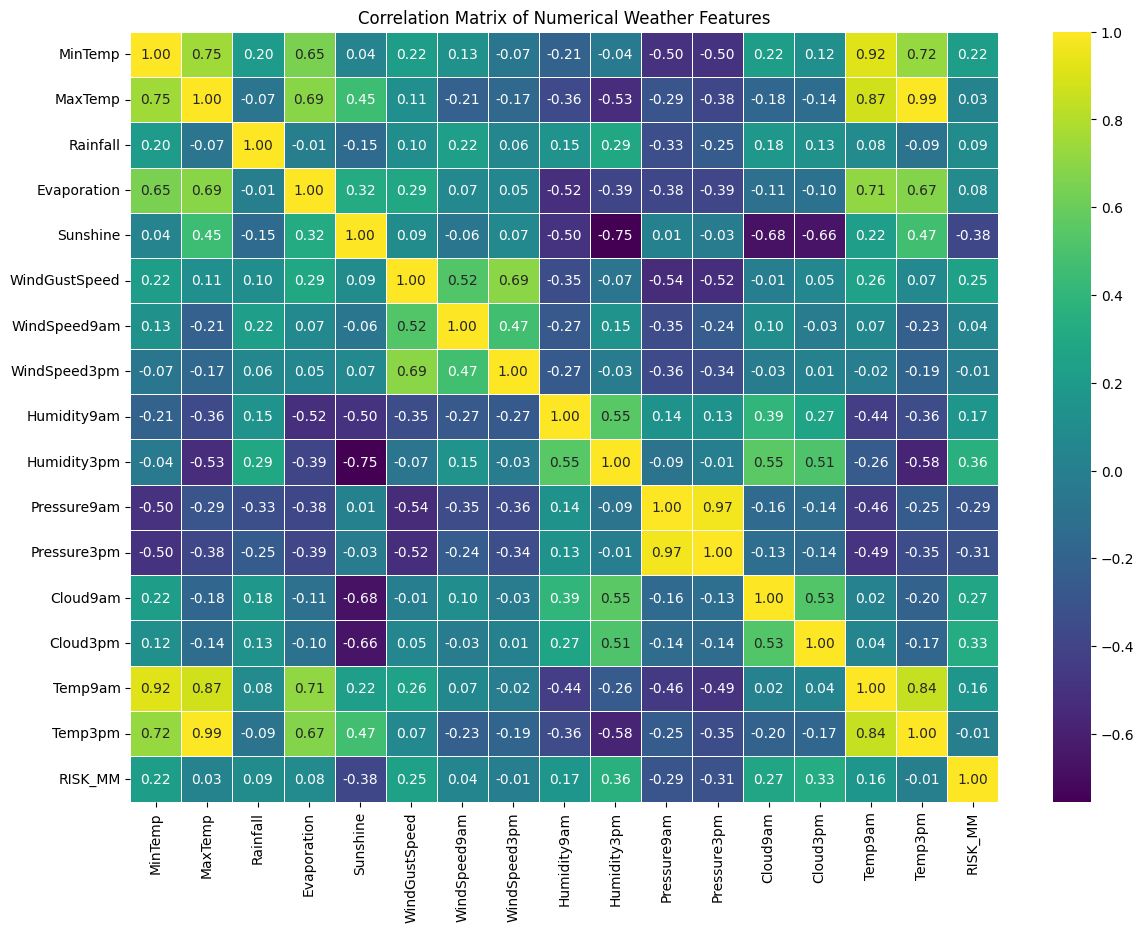

High positive correlations exist between MinTemp and MaxTemp, Temp9am and Temp3pm, and MaxTemp and Temp3pm. Sunshine has a negative correlation with Humidity and Rainfall.


In [36]:
plt.figure(figsize=(14, 10))
numerical_cols_df2 = df2_cleaned.select_dtypes(include=np.number).columns
sns.heatmap(df2_cleaned[numerical_cols_df2].corr(), annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Weather Features')
plt.show()
print("High positive correlations exist between MinTemp and MaxTemp, Temp9am and Temp3pm, and MaxTemp and Temp3pm. Sunshine has a negative correlation with Humidity and Rainfall.")

In [37]:
df3 = pd.read_csv('titanic.csv')
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [38]:
print("\n Statistics:")
print(df3.describe().T)


 Statistics:
              count        mean         std   min       25%       50%  \
Passengerid  1309.0  655.000000  378.020061  1.00  328.0000  655.0000   
Age          1309.0   29.503186   12.905241  0.17   22.0000   28.0000   
Fare         1309.0   33.281086   51.741500  0.00    7.8958   14.4542   
Sex          1309.0    0.355997    0.478997  0.00    0.0000    0.0000   
sibsp        1309.0    0.498854    1.041658  0.00    0.0000    0.0000   
zero         1309.0    0.000000    0.000000  0.00    0.0000    0.0000   
zero.1       1309.0    0.000000    0.000000  0.00    0.0000    0.0000   
zero.2       1309.0    0.000000    0.000000  0.00    0.0000    0.0000   
zero.3       1309.0    0.000000    0.000000  0.00    0.0000    0.0000   
zero.4       1309.0    0.000000    0.000000  0.00    0.0000    0.0000   
zero.5       1309.0    0.000000    0.000000  0.00    0.0000    0.0000   
zero.6       1309.0    0.000000    0.000000  0.00    0.0000    0.0000   
Parch        1309.0    0.385027    0.

In [39]:
print("\nMissing Values:")
missing_values = df3.isnull().sum()
print(missing_values)


Missing Values:
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64


In [40]:
df3_cleaned = df3.copy()
if 'Embarked' in df3_cleaned.columns:
    df3_cleaned['Embarked'] = df3_cleaned['Embarked'].fillna(
        df3_cleaned['Embarked'].mode()[0]
    )
df3_cleaned.drop(
    columns=[col for col in df3_cleaned.columns if 'zero' in col],
    inplace=True
)
df3_cleaned.rename(columns={'2urvived': 'Survived'}, inplace=True)
print(df3_cleaned.isnull().sum())

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       0
Survived       0
dtype: int64


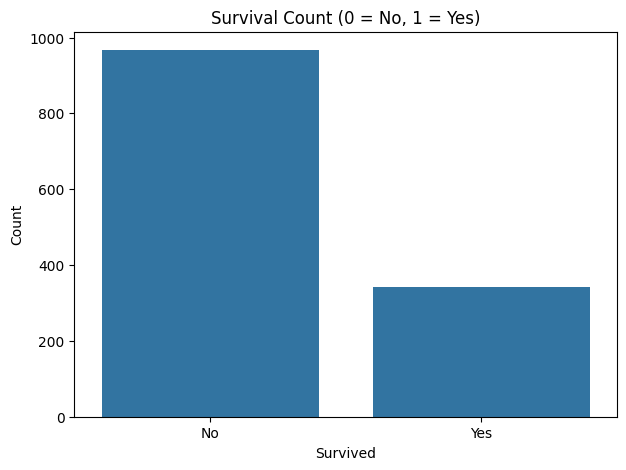

A larger number of passengers did not survive compared to those who did.


In [41]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Survived', data=df3_cleaned)
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()
print("A larger number of passengers did not survive compared to those who did.")

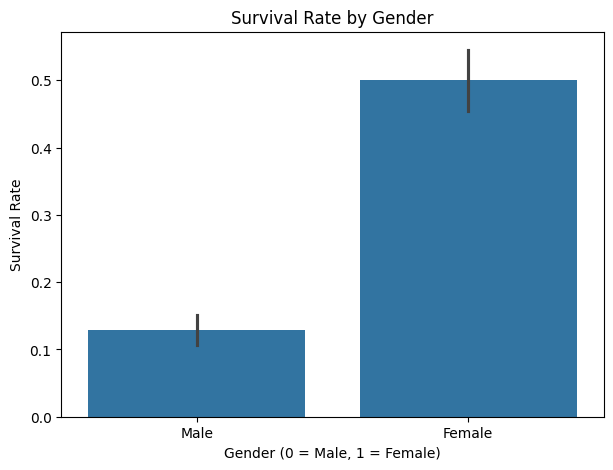

Females (1) had a significantly higher survival rate than males (0), which is a common finding in the Titanic dataset and suggests a 'women and children first' protocol.


In [42]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Sex', y='Survived', data=df3_cleaned)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender (0 = Male, 1 = Female)')
plt.ylabel('Survival Rate')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.show()
print("Females (1) had a significantly higher survival rate than males (0), which is a common finding in the Titanic dataset and suggests a 'women and children first' protocol.")

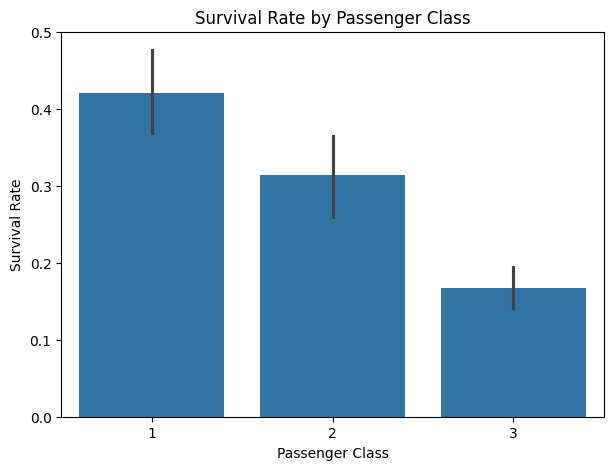

Passengers in 1st class had a much higher survival rate, followed by 2nd and then 3rd class. This suggests that socio-economic status or location on the ship played a major role in survival.


In [43]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=df3_cleaned)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()
print("Passengers in 1st class had a much higher survival rate, followed by 2nd and then 3rd class. This suggests that socio-economic status or location on the ship played a major role in survival.")

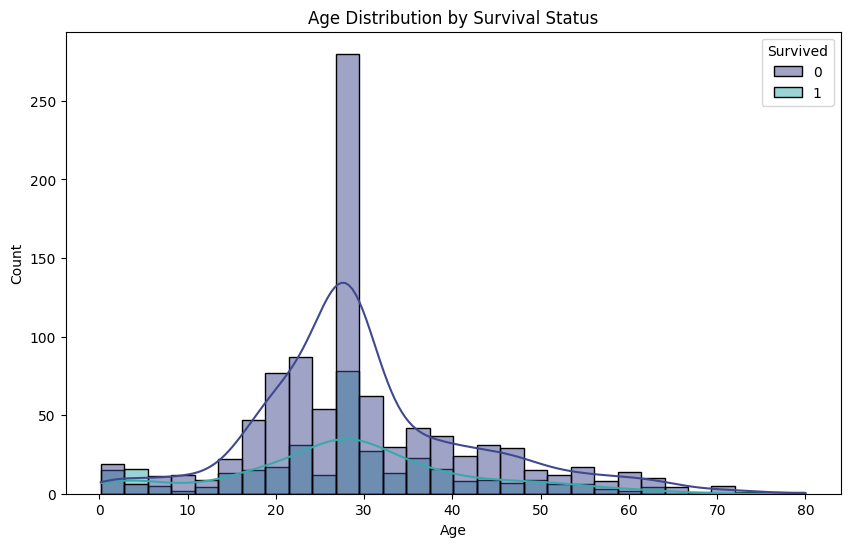

Very young children show a higher survival rate. There's a general trend of lower survival rates for adult ages, especially for males.


In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(x='Age', hue='Survived', data=df3_cleaned, bins=30, kde=True, palette='mako')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
print("Very young children show a higher survival rate. There's a general trend of lower survival rates for adult ages, especially for males.")

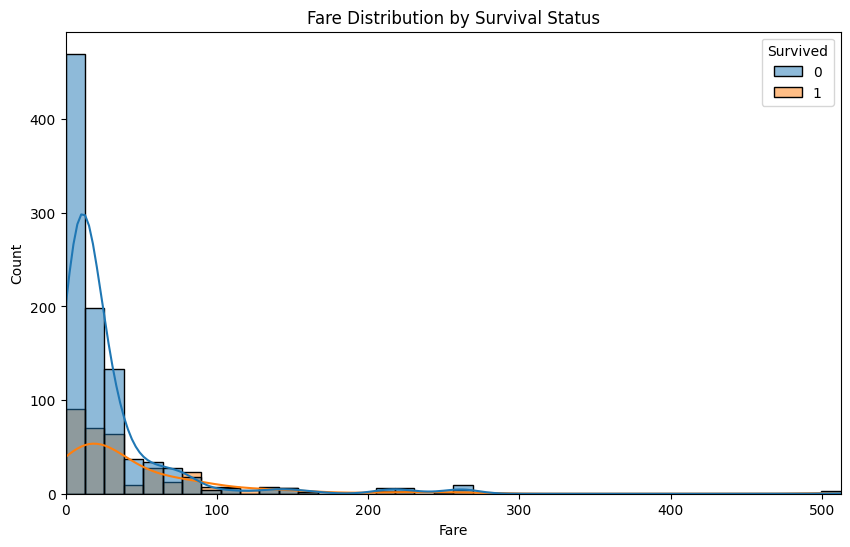

Passengers who paid higher fares (higher class) had a better chance of survival.


In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(x='Fare', hue='Survived', data=df3_cleaned, bins=40, kde=True)
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.xlim(0, df3_cleaned['Fare'].max())
plt.show()
print("Passengers who paid higher fares (higher class) had a better chance of survival.")

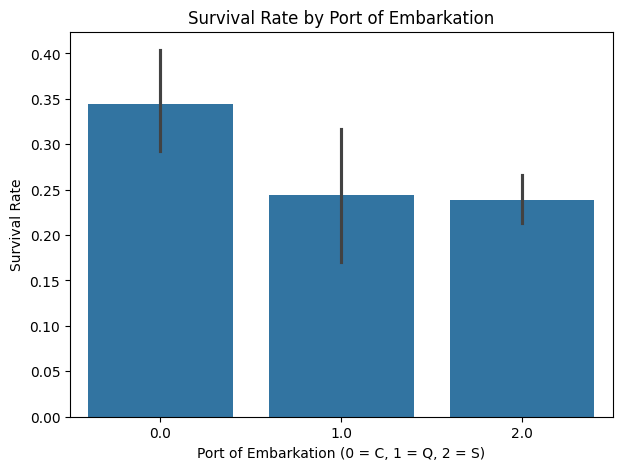

Passengers who embarked from port 0 (likely Cherbourg, 'C') had the highest survival rate, followed by port 2 (Southampton, 'S') and then port 1 (Queenstown, 'Q').


In [46]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Embarked', y='Survived', data=df3_cleaned)
plt.title('Survival Rate by Port of Embarkation')
plt.xlabel('Port of Embarkation (0 = C, 1 = Q, 2 = S)')
plt.ylabel('Survival Rate')
plt.show()
print("Passengers who embarked from port 0 (likely Cherbourg, 'C') had the highest survival rate, followed by port 2 (Southampton, 'S') and then port 1 (Queenstown, 'Q').")

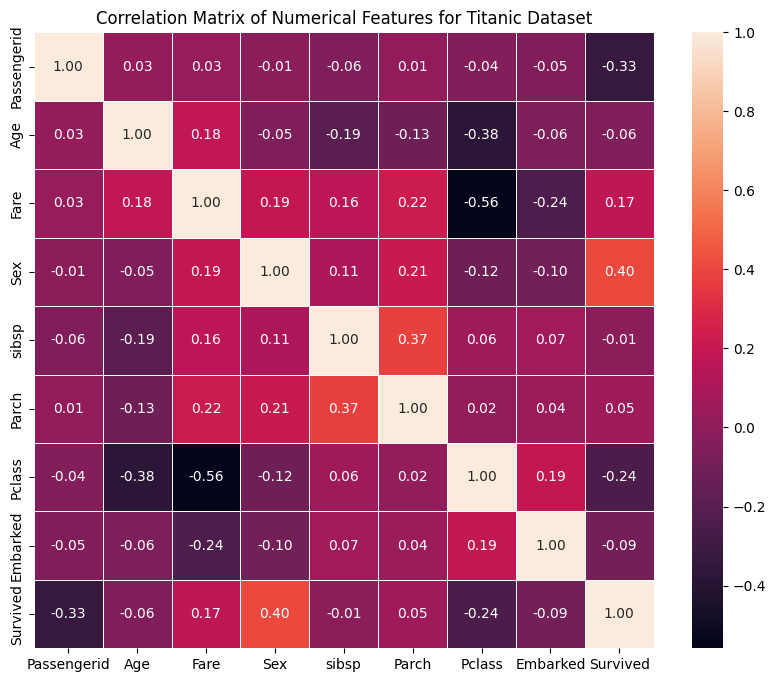

'Pclass' has a strong negative correlation with 'Fare' and 'Survived', meaning lower Pclass (1st class) correlates with higher fare and higher survival. 'Sex' (female, likely 1) has a positive correlation with 'Survived', confirming earlier findings. 'Age' shows a slight negative correlation with 'Survived', suggesting older passengers might have had a slightly lower survival chance, though this is not as strong as 'Sex' or 'Pclass'.


In [47]:
plt.figure(figsize=(10, 8))
numerical_cols_df3 = df3_cleaned.select_dtypes(include=np.number).columns
sns.heatmap(df3_cleaned[numerical_cols_df3].corr(), annot=True, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features for Titanic Dataset')
plt.show()
print("'Pclass' has a strong negative correlation with 'Fare' and 'Survived', meaning lower Pclass (1st class) correlates with higher fare and higher survival. 'Sex' (female, likely 1) has a positive correlation with 'Survived', confirming earlier findings. 'Age' shows a slight negative correlation with 'Survived', suggesting older passengers might have had a slightly lower survival chance, though this is not as strong as 'Sex' or 'Pclass'.")

In [48]:
df4 = pd.read_csv("Iris.csv")
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [49]:
print("\n Statistics:")
print(df4.describe().T)


 Statistics:
               count       mean        std  min    25%    50%     75%    max
Id             150.0  75.500000  43.445368  1.0  38.25  75.50  112.75  150.0
SepalLengthCm  150.0   5.843333   0.828066  4.3   5.10   5.80    6.40    7.9
SepalWidthCm   150.0   3.054000   0.433594  2.0   2.80   3.00    3.30    4.4
PetalLengthCm  150.0   3.758667   1.764420  1.0   1.60   4.35    5.10    6.9
PetalWidthCm   150.0   1.198667   0.763161  0.1   0.30   1.30    1.80    2.5


In [50]:
print("\nMissing Values:")
missing_values = df4.isnull().sum()
print(missing_values)


Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [51]:
df4_cleaned = df4.copy()
df4_cleaned = df4_cleaned.drop('Id', axis=1)
print(df4_cleaned.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


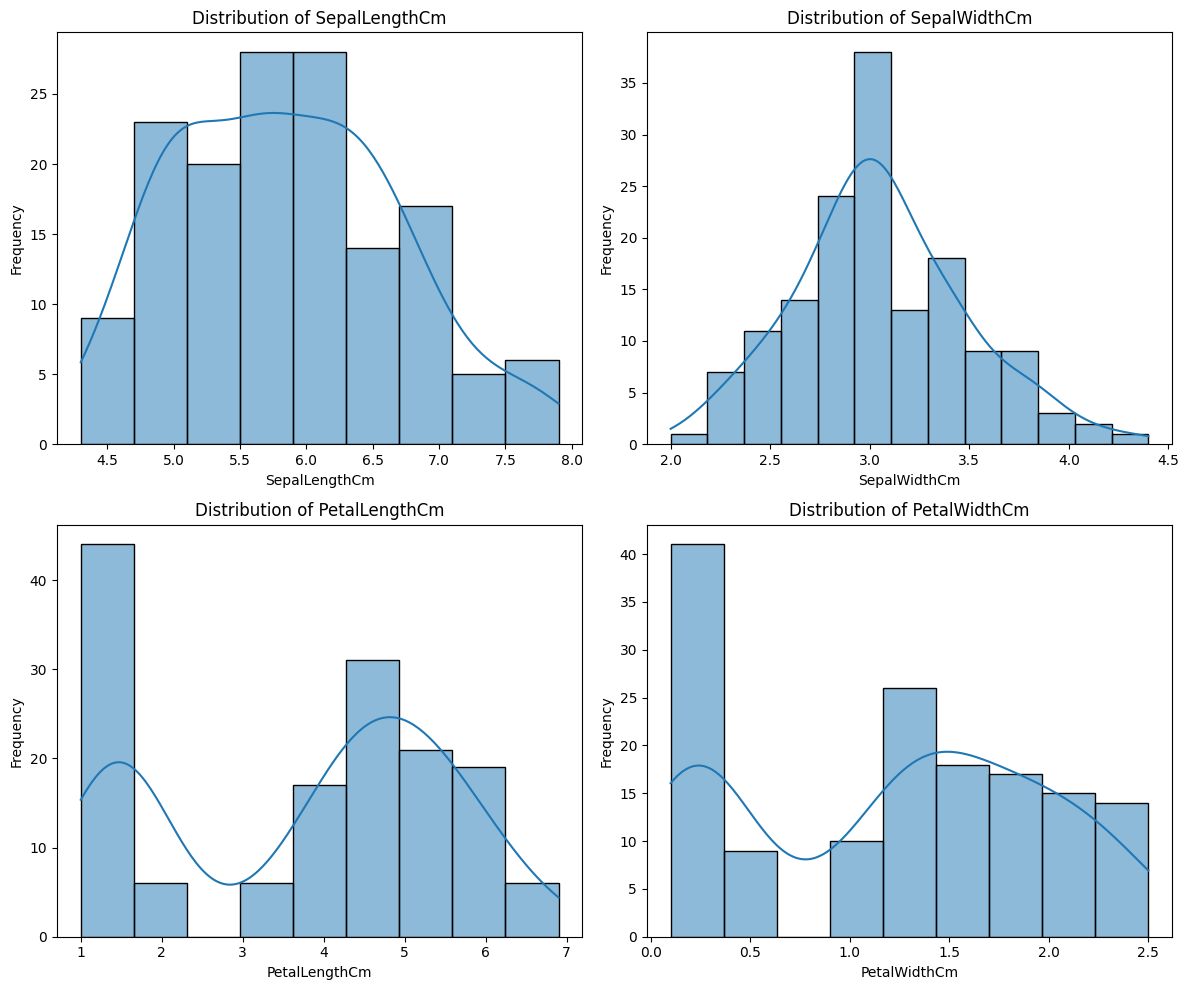

The distributions show that SepalLengthCm and SepalWidthCm are somewhat normally distributed, while PetalLengthCm and PetalWidthCm show more distinct multi-modal distributions, likely due to the different species.


In [52]:
plt.figure(figsize=(12, 10))
for i, column in enumerate(df4_cleaned.select_dtypes(include=np.number).columns):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df4_cleaned[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("The distributions show that SepalLengthCm and SepalWidthCm are somewhat normally distributed, while PetalLengthCm and PetalWidthCm show more distinct multi-modal distributions, likely due to the different species.")

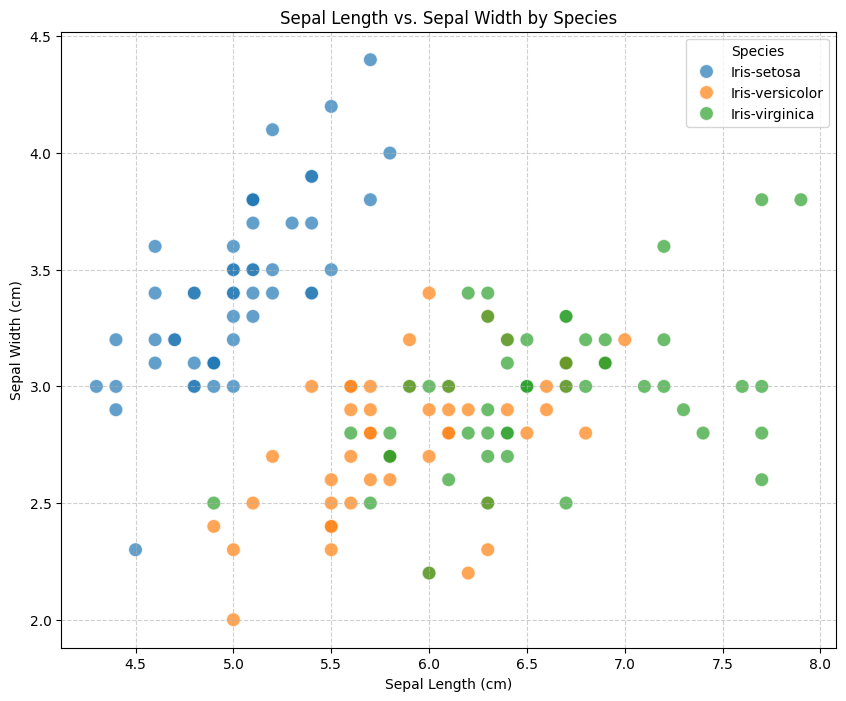

Setosa species are clearly separated, having smaller sepal lengths but wider sepals. Versicolor and Virginica show more overlap.


In [53]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=df4_cleaned, s=100, alpha=0.7)
plt.title('Sepal Length vs. Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("Setosa species are clearly separated, having smaller sepal lengths but wider sepals. Versicolor and Virginica show more overlap.")

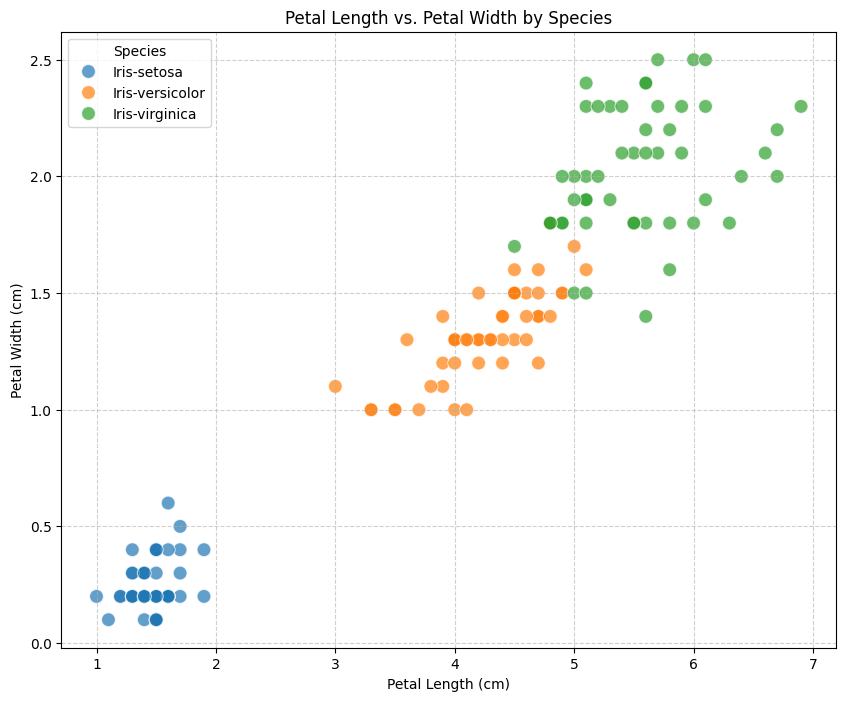

Petal length and petal width are highly correlated and are excellent features for distinguishing between the three species. Setosa has small petals, Versicolor has medium, and Virginica has large.


In [54]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Species', data=df4_cleaned, s=100, alpha=0.7)
plt.title('Petal Length vs. Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("Petal length and petal width are highly correlated and are excellent features for distinguishing between the three species. Setosa has small petals, Versicolor has medium, and Virginica has large.")

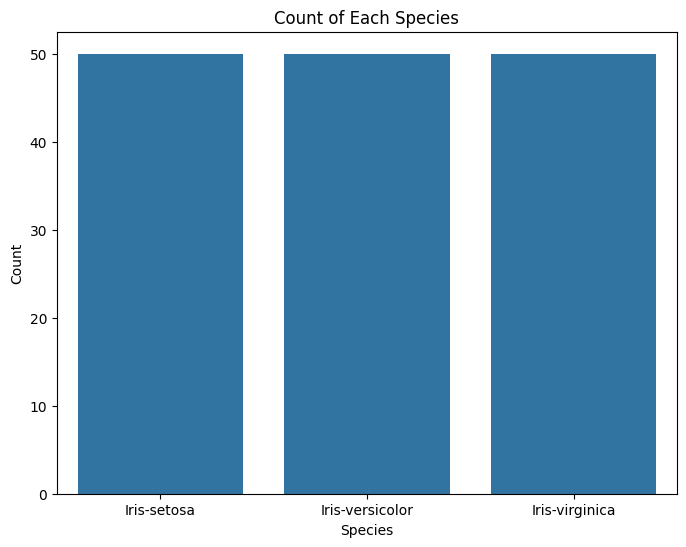

The dataset is balanced, with 50 samples for each of the three species.


In [55]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Species', data=df4_cleaned)
plt.title('Count of Each Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()
print("The dataset is balanced, with 50 samples for each of the three species.")

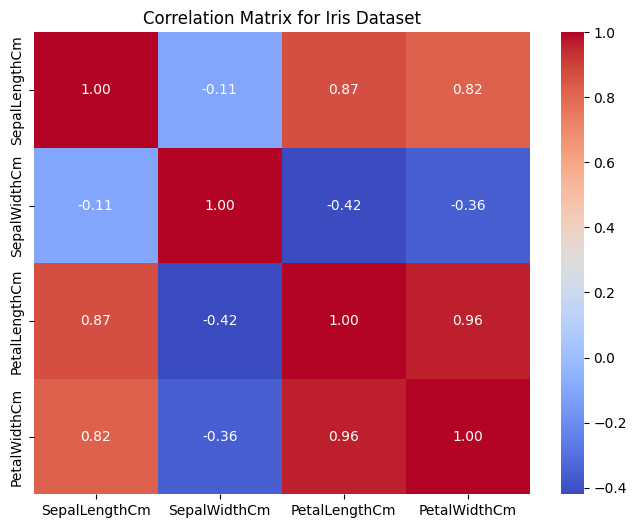

Petal Length and Petal Width are highly correlated with each other, and also with Sepal Length. Sepal Width shows a weaker correlation with other features.


In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(df4_cleaned.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Iris Dataset')
plt.show()
print("Petal Length and Petal Width are highly correlated with each other, and also with Sepal Length. Sepal Width shows a weaker correlation with other features.")

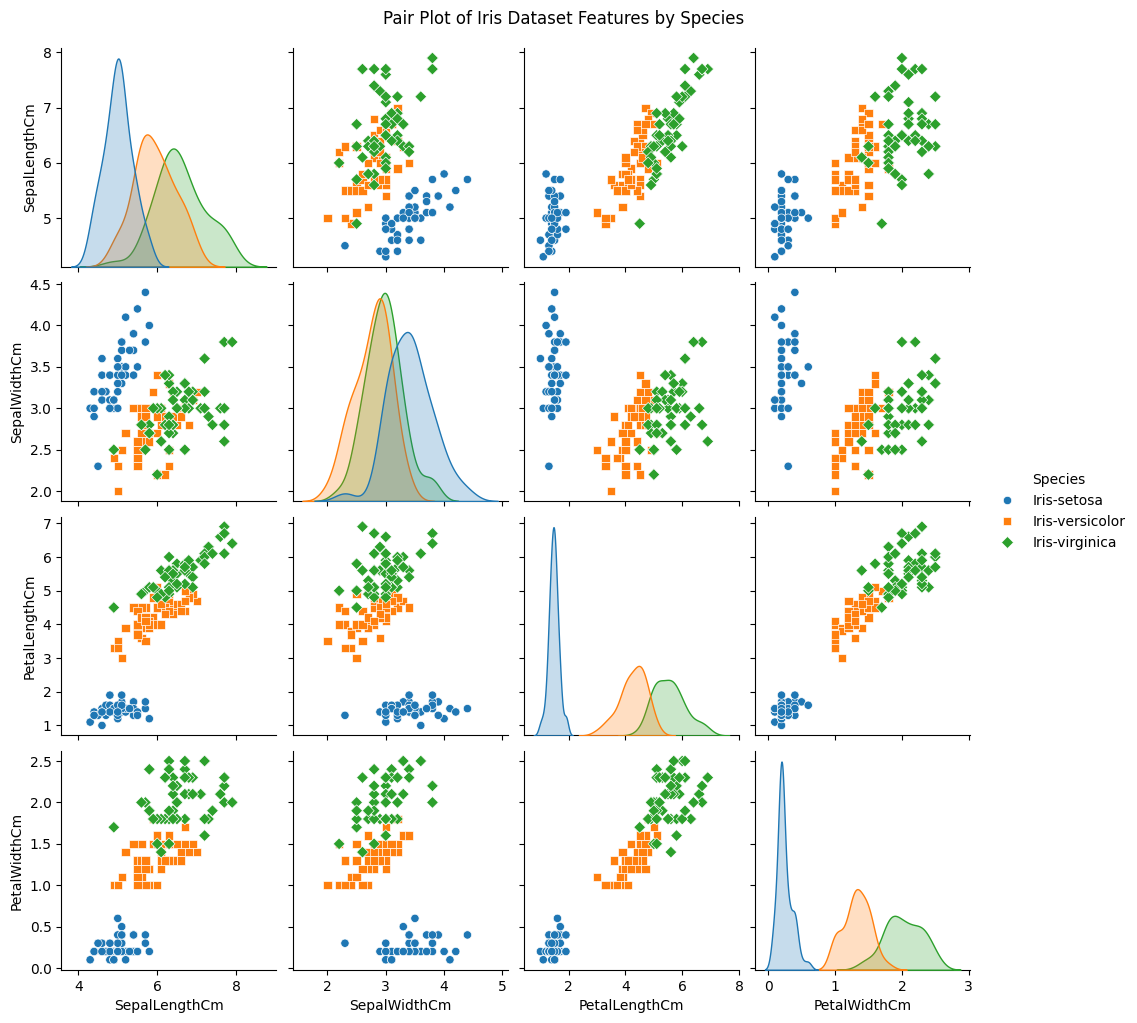

The pair plot visually confirms the distinct groupings of species based on the petal measurements, and to a lesser extent, sepal length.


In [57]:
sns.pairplot(df4_cleaned, hue='Species', markers=['o', 's', 'D'])
plt.suptitle('Pair Plot of Iris Dataset Features by Species', y=1.02)
plt.show()
print("The pair plot visually confirms the distinct groupings of species based on the petal measurements, and to a lesser extent, sepal length.")

In [58]:
df5 = pd.read_csv("Mall_Customers.csv")
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [59]:
print("\n Statistics:")
print(df5.describe().T)


 Statistics:
                        count    mean        std   min    25%    50%     75%  \
CustomerID              200.0  100.50  57.879185   1.0  50.75  100.5  150.25   
Age                     200.0   38.85  13.969007  18.0  28.75   36.0   49.00   
Annual Income (k$)      200.0   60.56  26.264721  15.0  41.50   61.5   78.00   
Spending Score (1-100)  200.0   50.20  25.823522   1.0  34.75   50.0   73.00   

                          max  
CustomerID              200.0  
Age                      70.0  
Annual Income (k$)      137.0  
Spending Score (1-100)   99.0  


In [60]:
print("\nMissing Values:")
missing_values = df5.isnull().sum()
print(missing_values)


Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [61]:
df5_cleaned = df5.copy()
df5_cleaned = df5_cleaned.drop('CustomerID', axis=1)

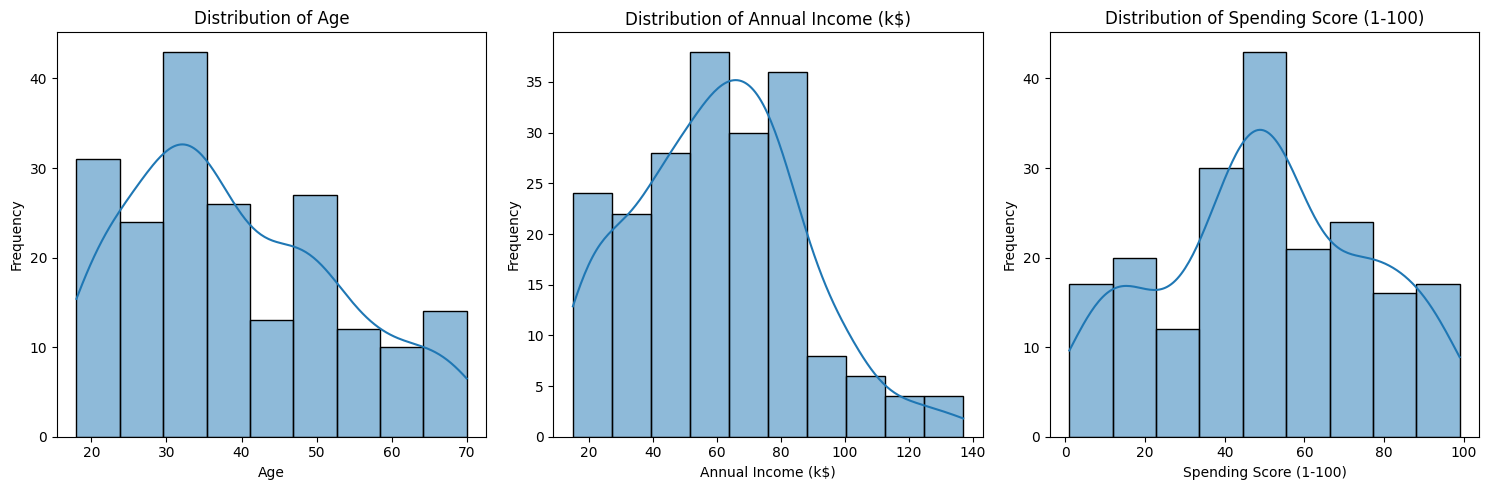

Age distribution is somewhat uniform but peaks around 30-35. Annual Income and Spending Score both show a normal-like distribution, with spending score having multiple peaks, which might indicate different customer segments.


In [62]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df5_cleaned['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df5_cleaned['Annual Income (k$)'], kde=True)
plt.title('Distribution of Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df5_cleaned['Spending Score (1-100)'], kde=True)
plt.title('Distribution of Spending Score (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Age distribution is somewhat uniform but peaks around 30-35. Annual Income and Spending Score both show a normal-like distribution, with spending score having multiple peaks, which might indicate different customer segments.")

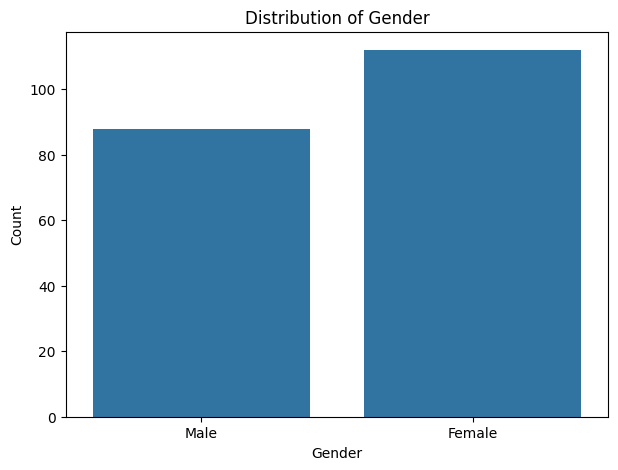

There are slightly more female customers than male customers in the dataset.


In [63]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Gender', data=df5_cleaned)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
print("There are slightly more female customers than male customers in the dataset.")

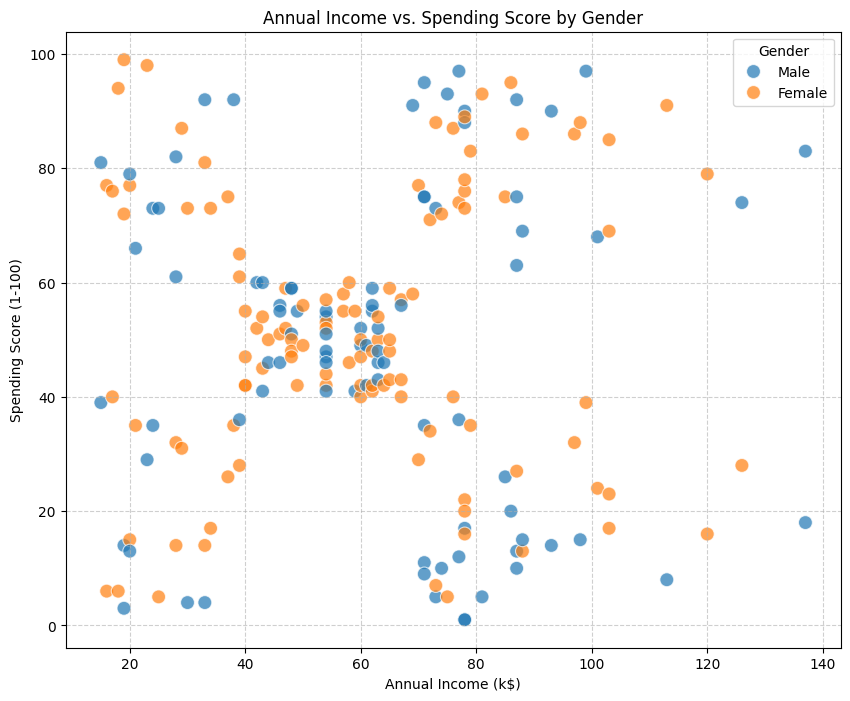

This scatter plot clearly shows distinct clusters of customers based on their annual income and spending score, irrespective of gender. This is very useful for customer segmentation.


In [64]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=df5_cleaned, s=100, alpha=0.7)
plt.title('Annual Income vs. Spending Score by Gender')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("This scatter plot clearly shows distinct clusters of customers based on their annual income and spending score, irrespective of gender. This is very useful for customer segmentation.")

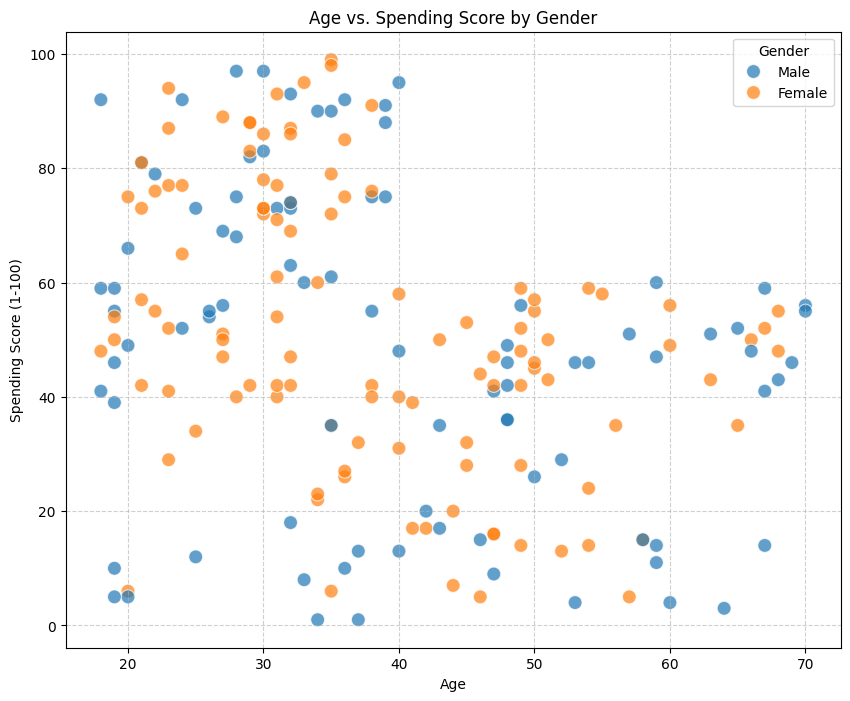

Younger customers (20-40) show a wider range of spending scores, including higher ones. Older customers tend to have lower spending scores, though there are exceptions.


In [65]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Gender', data=df5_cleaned, s=100, alpha=0.7)
plt.title('Age vs. Spending Score by Gender')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("Younger customers (20-40) show a wider range of spending scores, including higher ones. Older customers tend to have lower spending scores, though there are exceptions.")

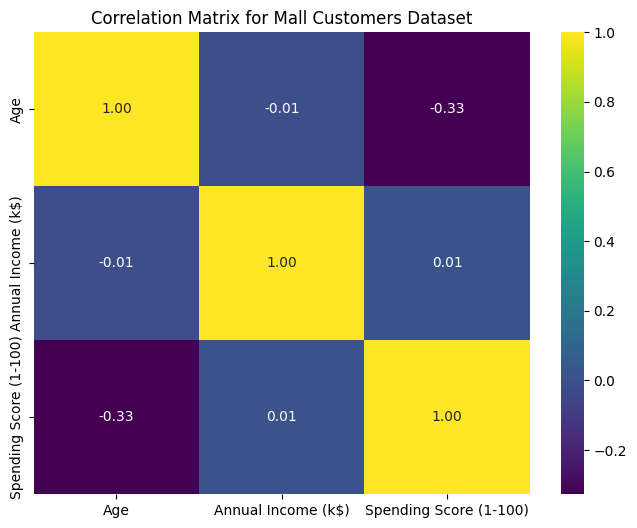

There is a weak negative correlation between Age and Spending Score, suggesting younger customers tend to have slightly higher spending scores. Annual Income and Spending Score show very little linear correlation, which reinforces the idea of distinct customer segments rather than a simple linear relationship.


In [66]:
plt.figure(figsize=(8, 6))
sns.heatmap(df5_cleaned.select_dtypes(include=np.number).corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix for Mall Customers Dataset')
plt.show()
print("There is a weak negative correlation between Age and Spending Score, suggesting younger customers tend to have slightly higher spending scores. Annual Income and Spending Score show very little linear correlation, which reinforces the idea of distinct customer segments rather than a simple linear relationship.")

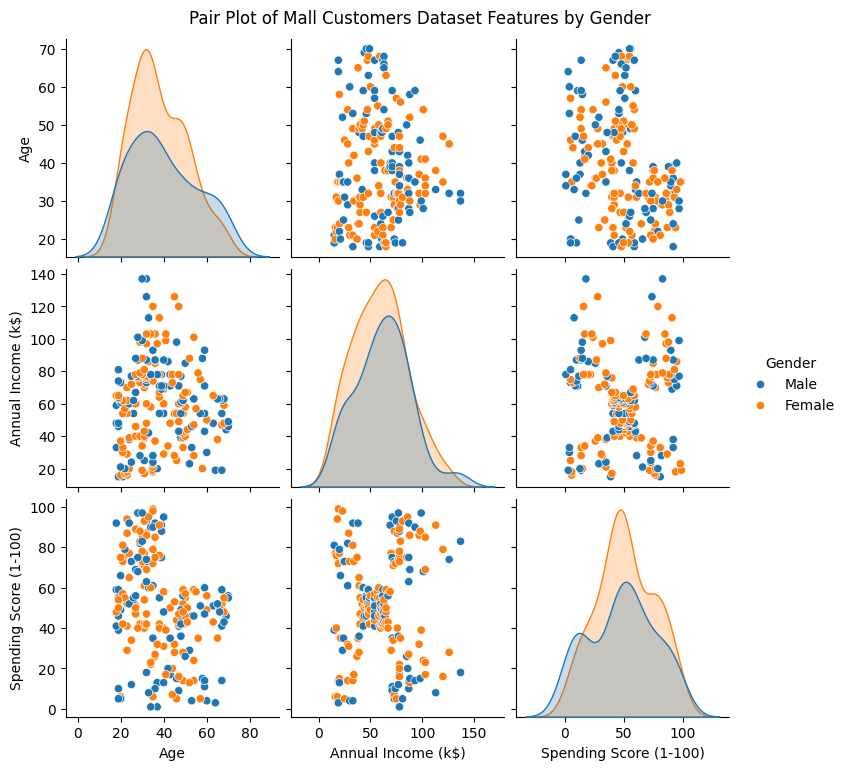

The pair plot provides a comprehensive view of relationships and distributions, clearly highlighting the clustering patterns between Annual Income and Spending Score, which will be crucial for segmentation.


In [67]:
sns.pairplot(df5_cleaned, hue='Gender', diag_kind='kde')
plt.suptitle('Pair Plot of Mall Customers Dataset Features by Gender', y=1.02) # Adjust suptitle position
plt.show()
print("The pair plot provides a comprehensive view of relationships and distributions, clearly highlighting the clustering patterns between Annual Income and Spending Score, which will be crucial for segmentation.")

In [68]:
df6 = pd.read_csv("StudentsPerformance.csv")
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [69]:
print("\n Statistics:")
print(df6.describe().T)


 Statistics:
                count    mean        std   min    25%   50%   75%    max
math score     1000.0  66.089  15.163080   0.0  57.00  66.0  77.0  100.0
reading score  1000.0  69.169  14.600192  17.0  59.00  70.0  79.0  100.0
writing score  1000.0  68.054  15.195657  10.0  57.75  69.0  79.0  100.0


In [70]:
print("\nMissing Values:")
missing_values = df6.isnull().sum()
print(missing_values)


Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [71]:
print("Number of duplicate rows:", df6.duplicated().sum())
print("\nUnique values for 'gender':", df6['gender'].unique())
print("Unique values for 'race/ethnicity':", df6['race/ethnicity'].unique())
print("Unique values for 'parental level of education':", df6['parental level of education'].unique())
print("Unique values for 'lunch':", df6['lunch'].unique())
print("Unique values for 'test preparation course':", df6['test preparation course'].unique())

Number of duplicate rows: 0

Unique values for 'gender': ['female' 'male']
Unique values for 'race/ethnicity': ['group B' 'group C' 'group A' 'group D' 'group E']
Unique values for 'parental level of education': ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Unique values for 'lunch': ['standard' 'free/reduced']
Unique values for 'test preparation course': ['none' 'completed']


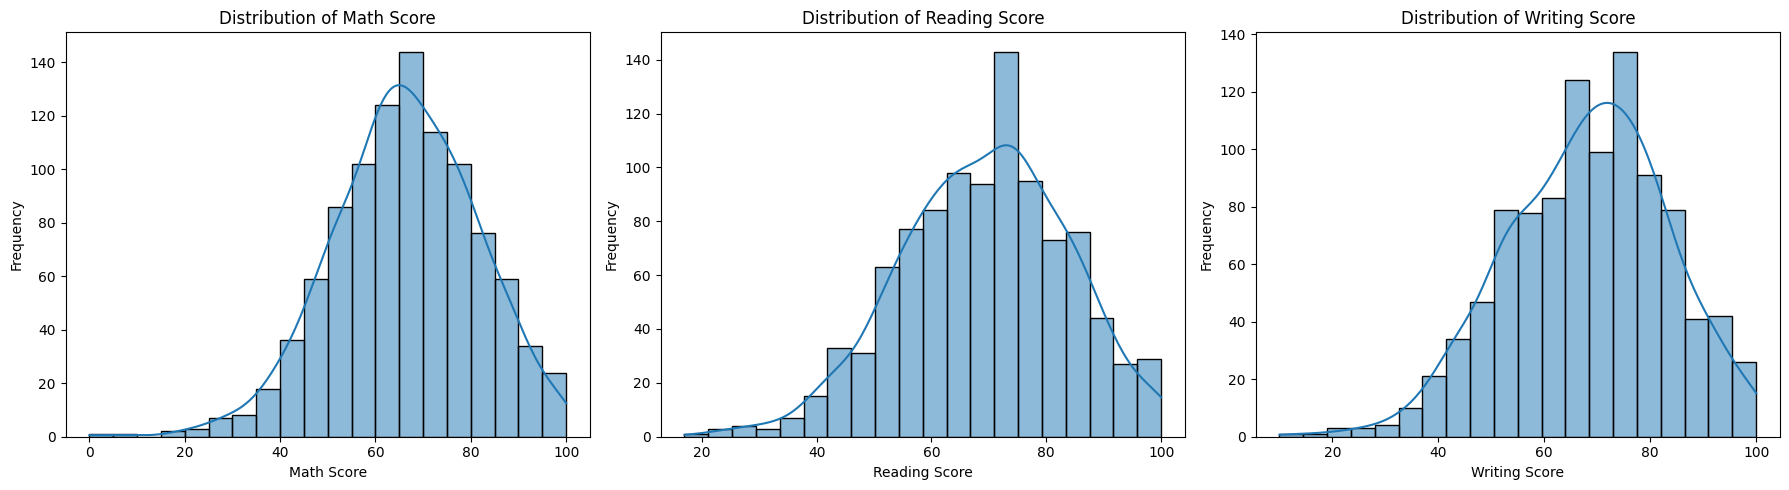

All three scores (math, reading, writing) show a generally normal distribution, centered around the 60s and 70s. There are some students with very low scores, indicating potential outliers or students struggling significantly.


In [72]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df6['math score'], kde=True, bins=20)
plt.title('Distribution of Math Score')
plt.xlabel('Math Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df6['reading score'], kde=True, bins=20)
plt.title('Distribution of Reading Score')
plt.xlabel('Reading Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df6['writing score'], kde=True, bins=20)
plt.title('Distribution of Writing Score')
plt.xlabel('Writing Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
print("All three scores (math, reading, writing) show a generally normal distribution, centered around the 60s and 70s. There are some students with very low scores, indicating potential outliers or students struggling significantly.")

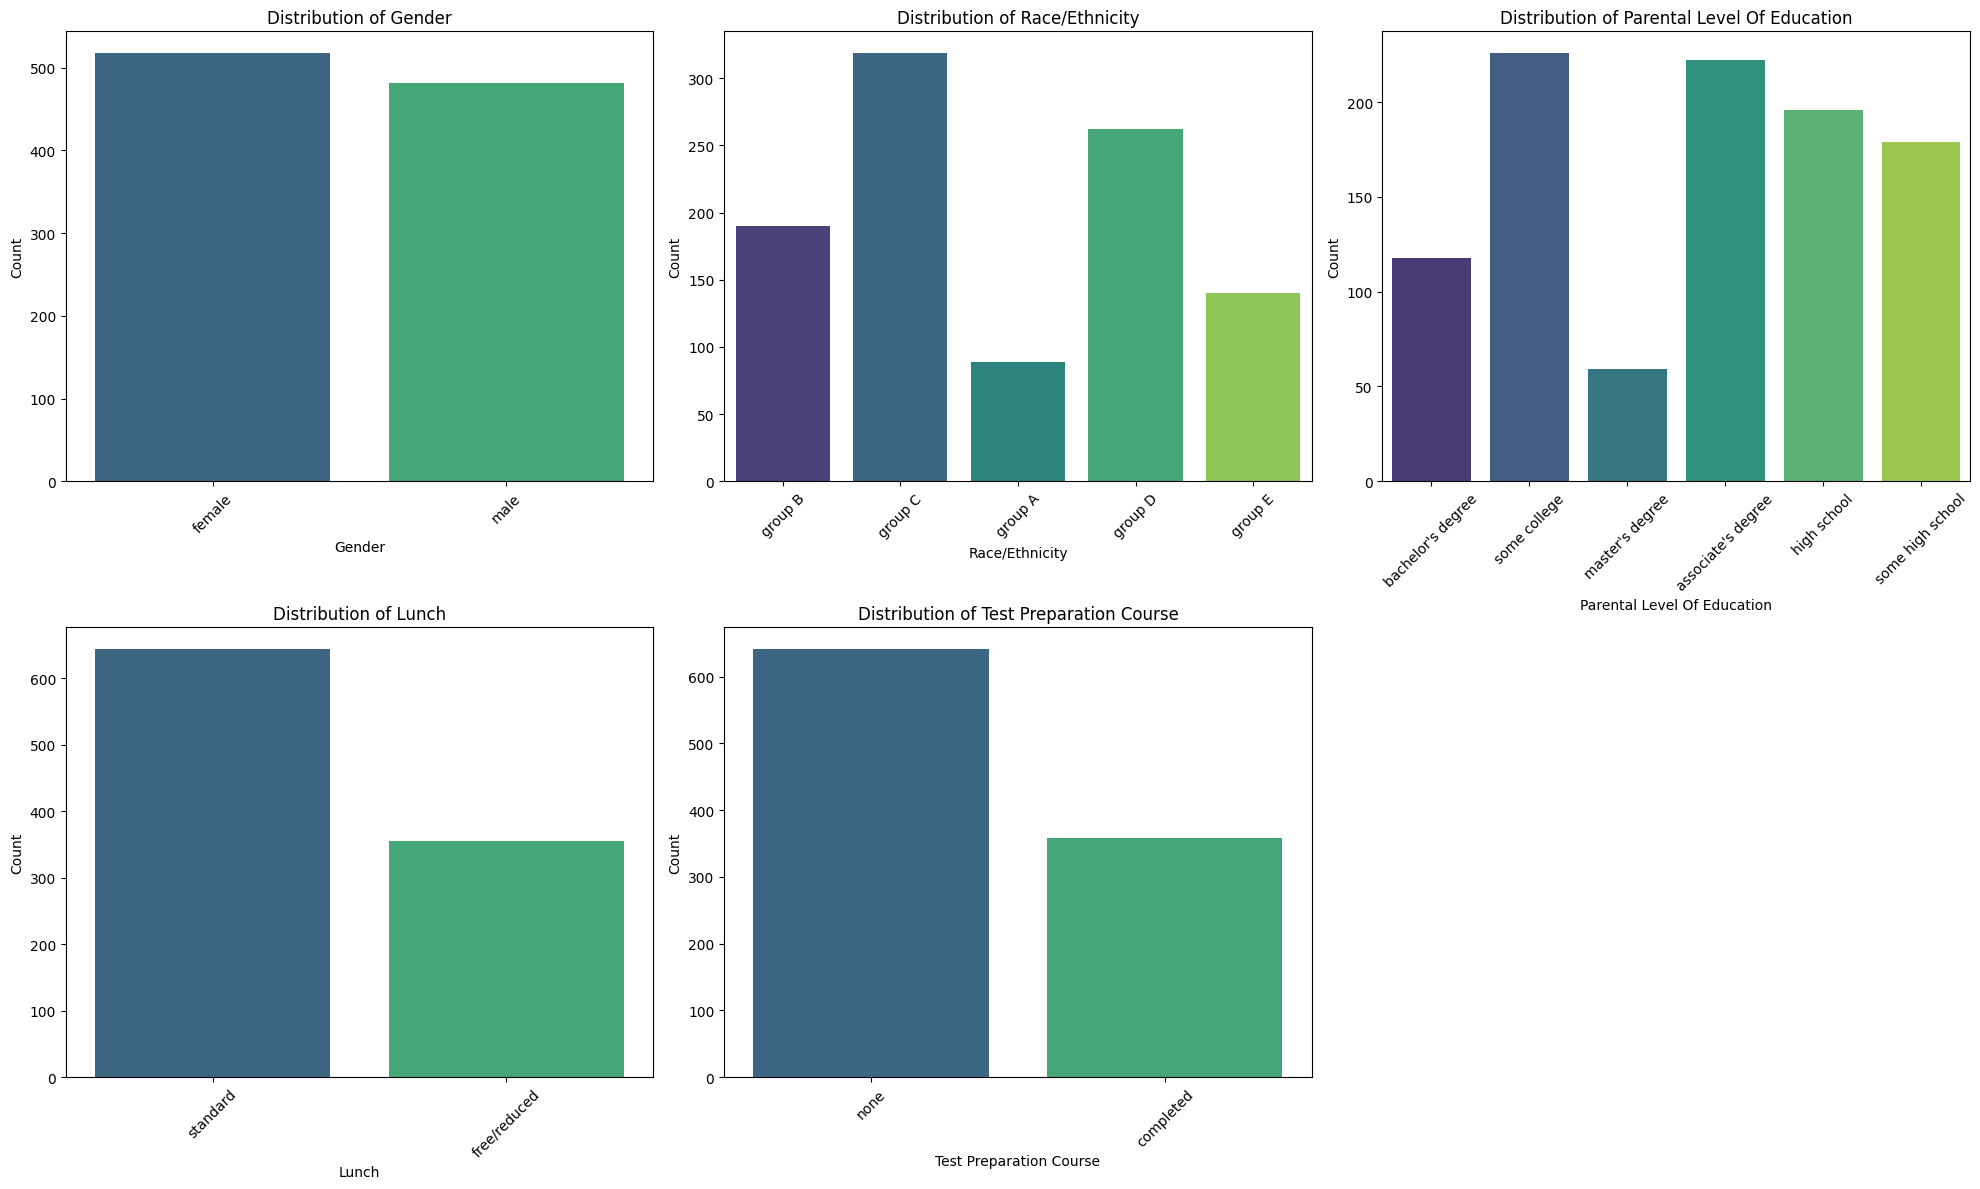

In [73]:
cat_cols = ['gender','race/ethnicity','parental level of education','lunch','test preparation course']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df6,x=col,hue=col,palette='viridis',legend=False,ax=axes[i])
    axes[i].set_title(f'Distribution of {col.title()}', fontsize=12)
    axes[i].set_xlabel(col.title())
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

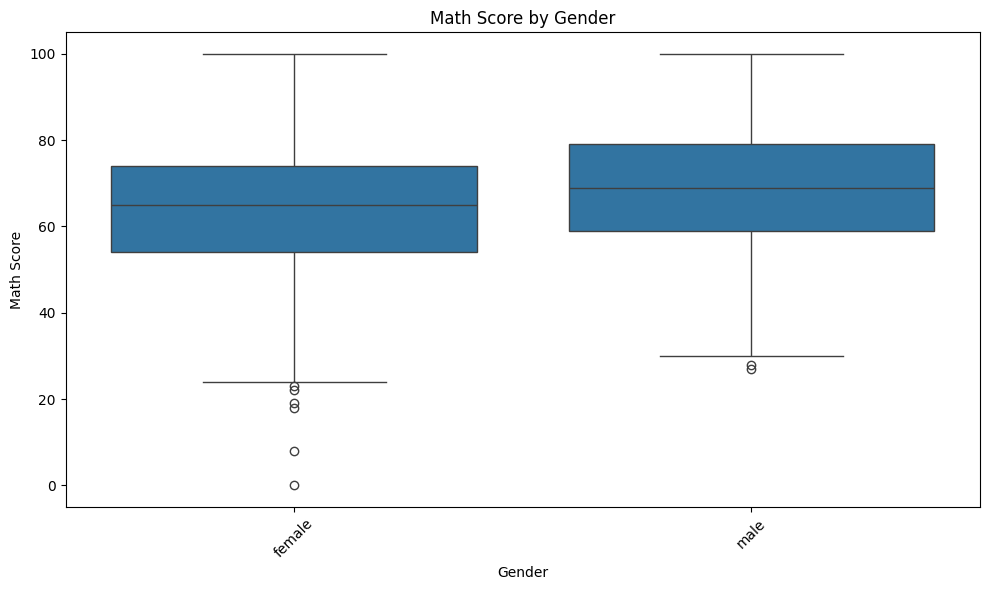

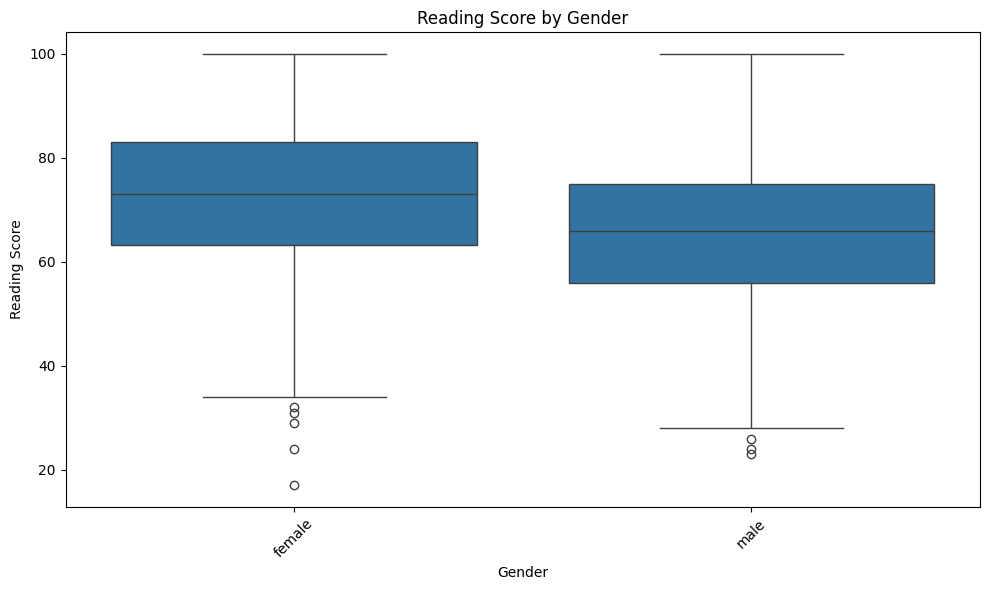

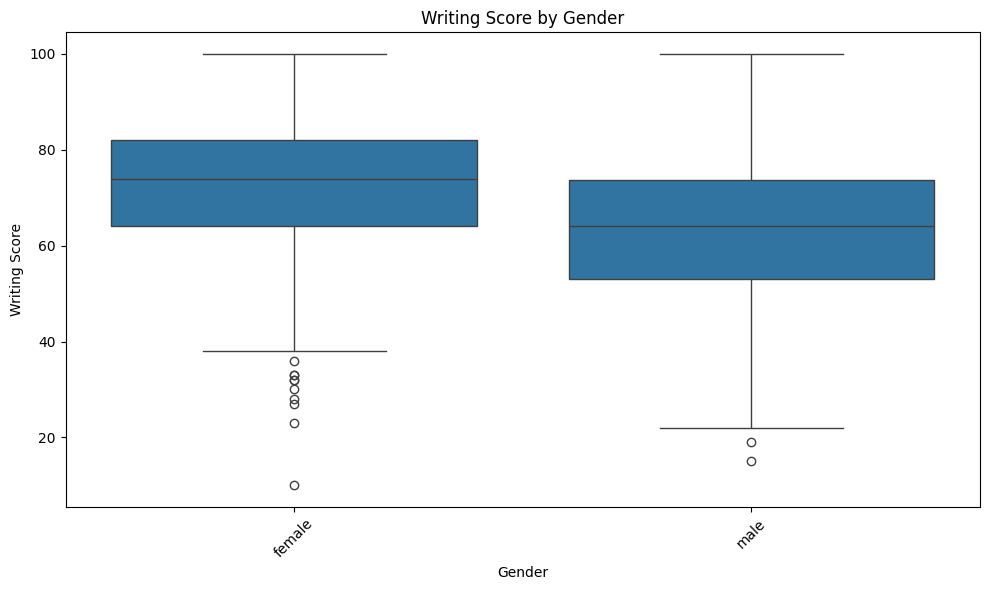


Observations for Gender:
 - Gender: Females tend to have higher reading and writing scores than males, while males often have slightly higher math scores.
 - Race/Ethnicity: Scores vary across groups, with Group E often showing higher performance and Group A showing lower. 
 - Parental Level of Education: Students with parents having higher education levels (e.g., master's, bachelor's) generally achieve higher scores. 
 - Lunch: Students with 'standard' lunch tend to perform better across all subjects compared to those with 'free/reduced' lunch.
 - Test Preparation Course: Students who completed the test preparation course consistently achieve higher scores in all three subjects.


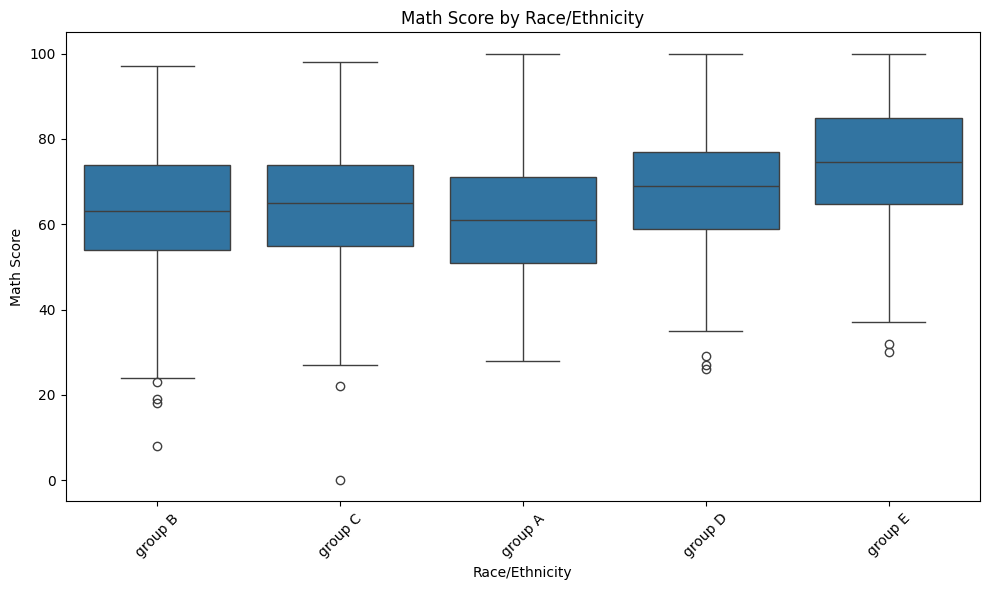

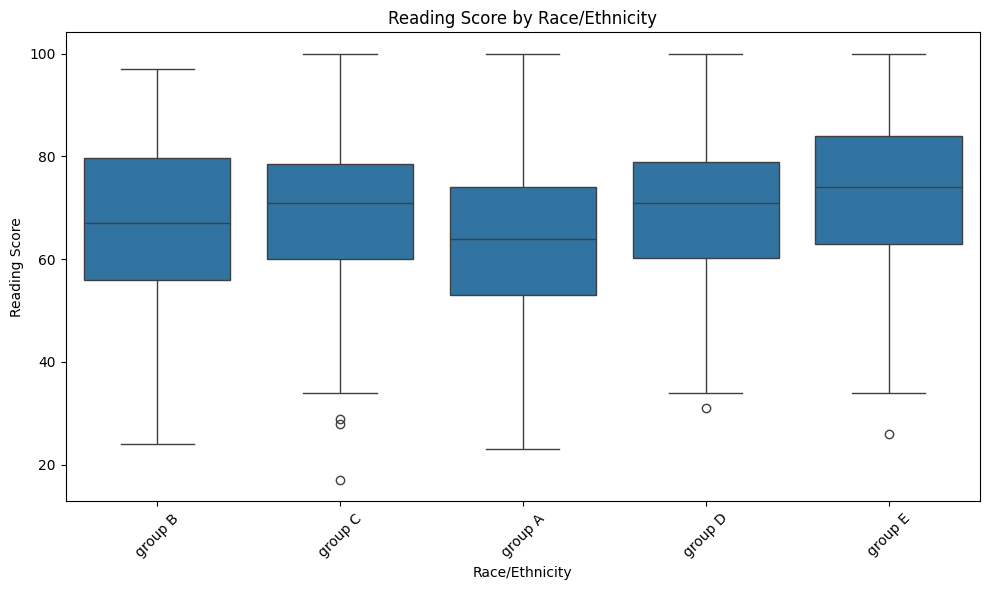

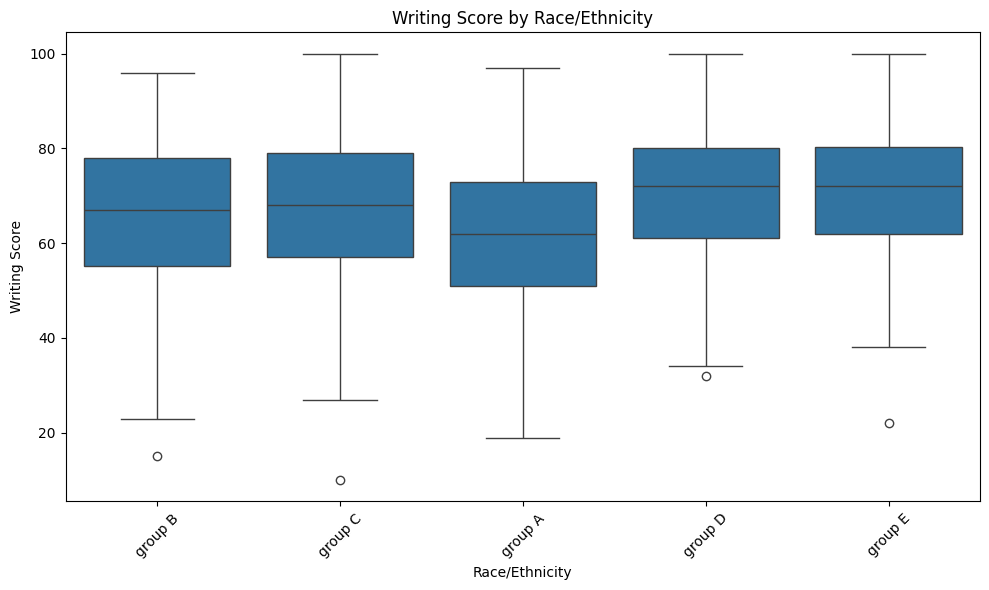


Observations for Race/Ethnicity:
 - Gender: Females tend to have higher reading and writing scores than males, while males often have slightly higher math scores.
 - Race/Ethnicity: Scores vary across groups, with Group E often showing higher performance and Group A showing lower. 
 - Parental Level of Education: Students with parents having higher education levels (e.g., master's, bachelor's) generally achieve higher scores. 
 - Lunch: Students with 'standard' lunch tend to perform better across all subjects compared to those with 'free/reduced' lunch.
 - Test Preparation Course: Students who completed the test preparation course consistently achieve higher scores in all three subjects.


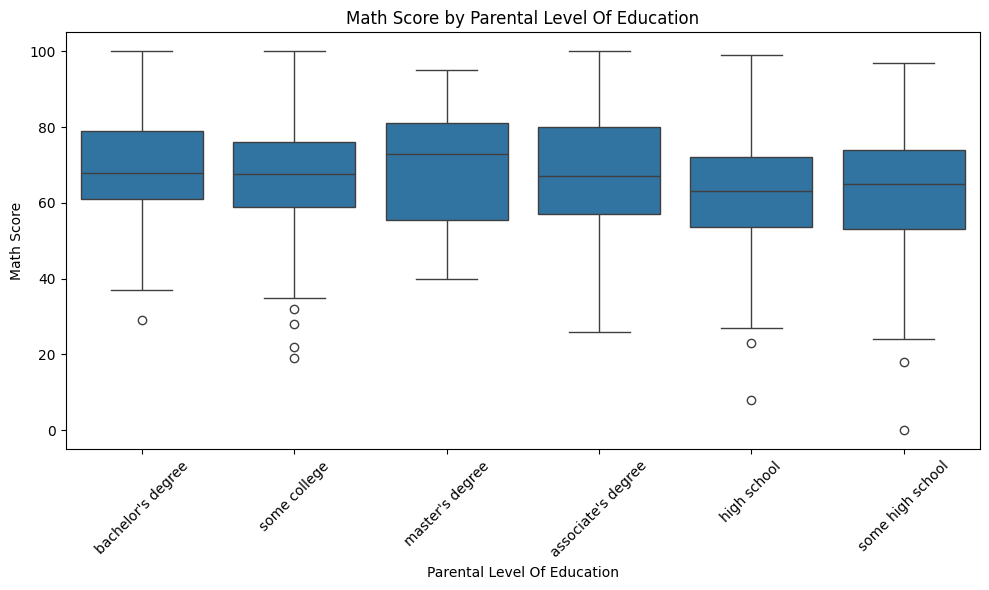

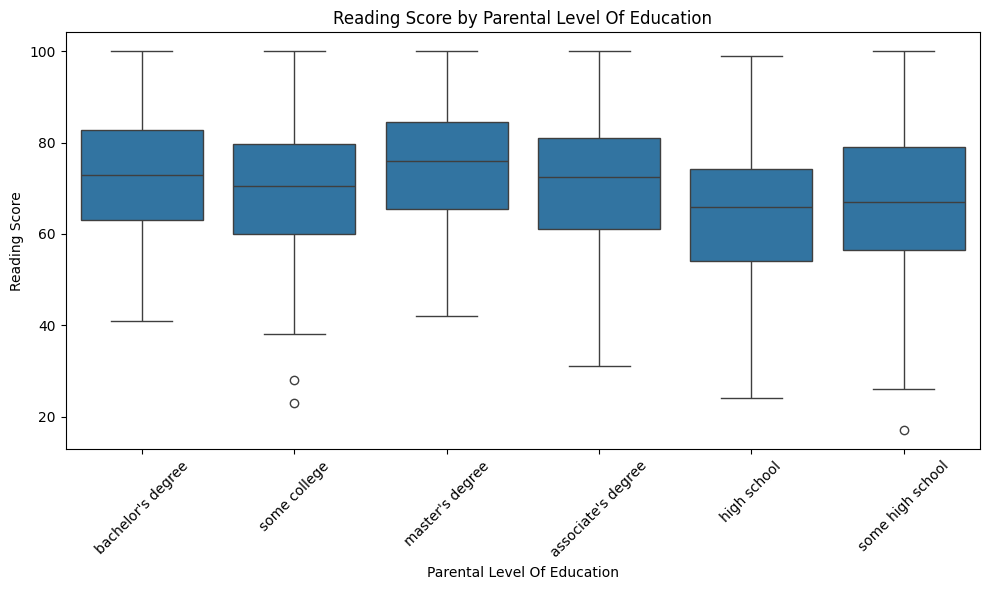

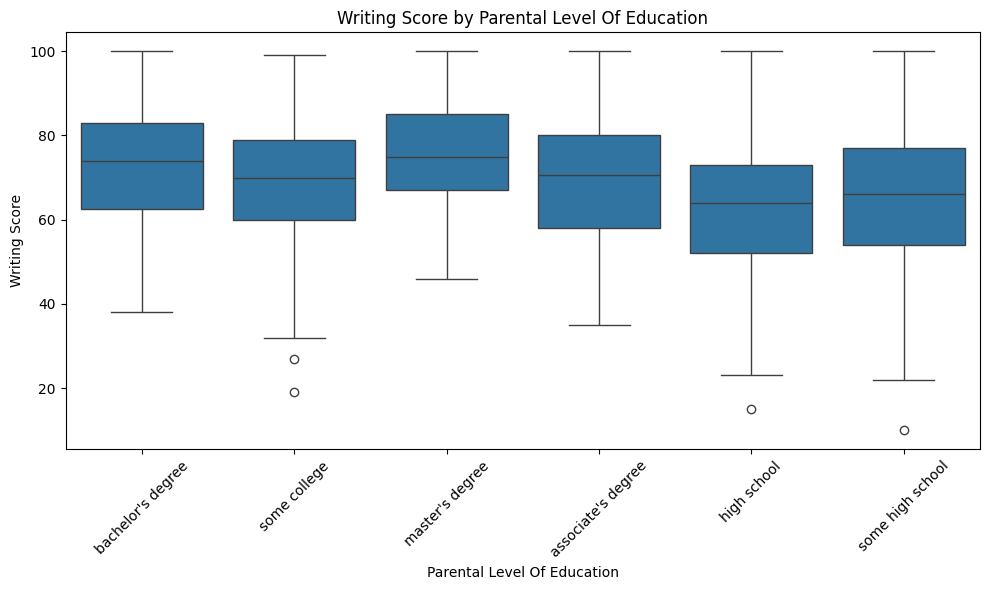


Observations for Parental_Level_Of_Education:
 - Gender: Females tend to have higher reading and writing scores than males, while males often have slightly higher math scores.
 - Race/Ethnicity: Scores vary across groups, with Group E often showing higher performance and Group A showing lower. 
 - Parental Level of Education: Students with parents having higher education levels (e.g., master's, bachelor's) generally achieve higher scores. 
 - Lunch: Students with 'standard' lunch tend to perform better across all subjects compared to those with 'free/reduced' lunch.
 - Test Preparation Course: Students who completed the test preparation course consistently achieve higher scores in all three subjects.


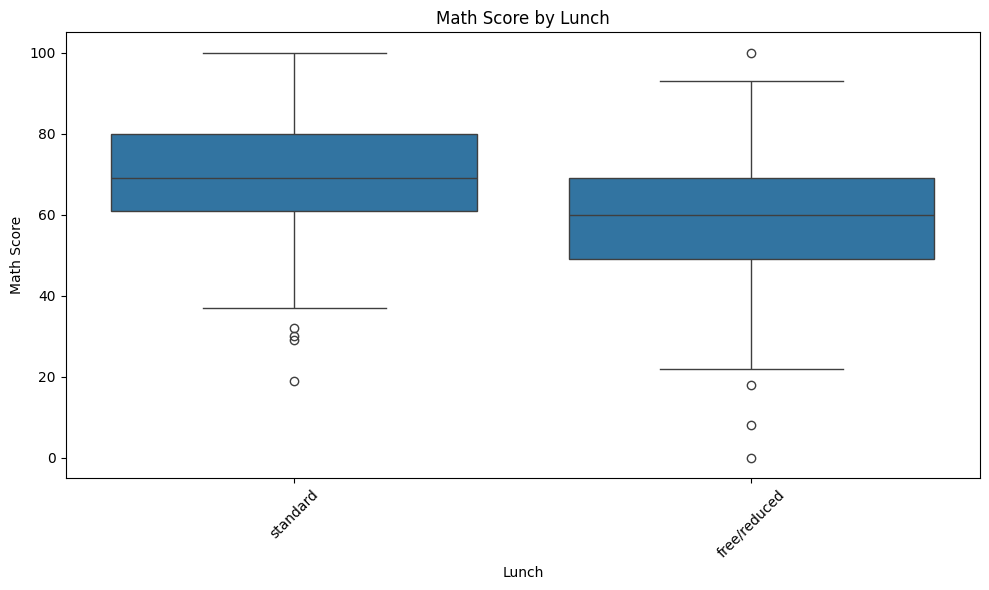

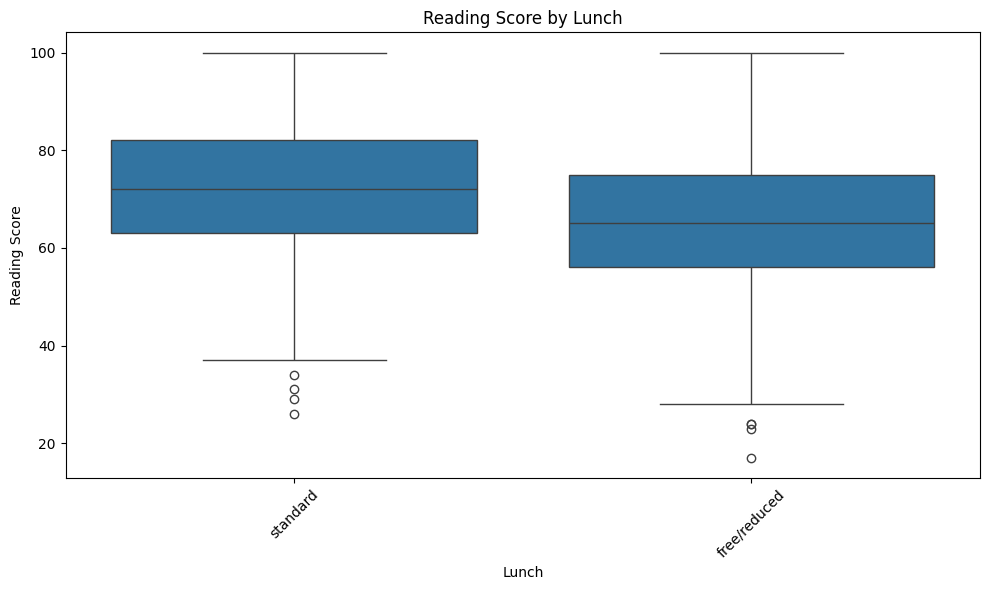

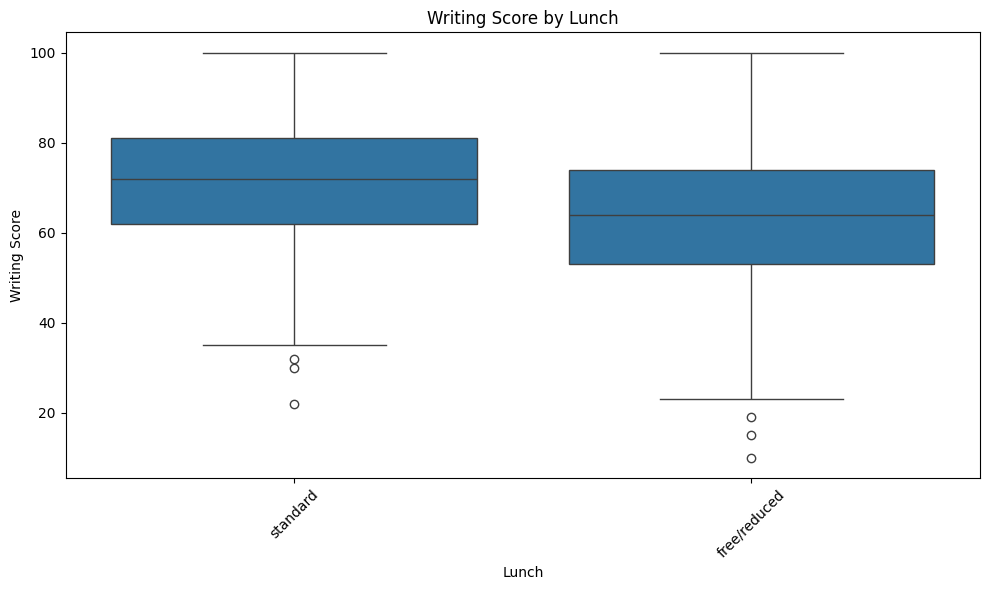


Observations for Lunch:
 - Gender: Females tend to have higher reading and writing scores than males, while males often have slightly higher math scores.
 - Race/Ethnicity: Scores vary across groups, with Group E often showing higher performance and Group A showing lower. 
 - Parental Level of Education: Students with parents having higher education levels (e.g., master's, bachelor's) generally achieve higher scores. 
 - Lunch: Students with 'standard' lunch tend to perform better across all subjects compared to those with 'free/reduced' lunch.
 - Test Preparation Course: Students who completed the test preparation course consistently achieve higher scores in all three subjects.


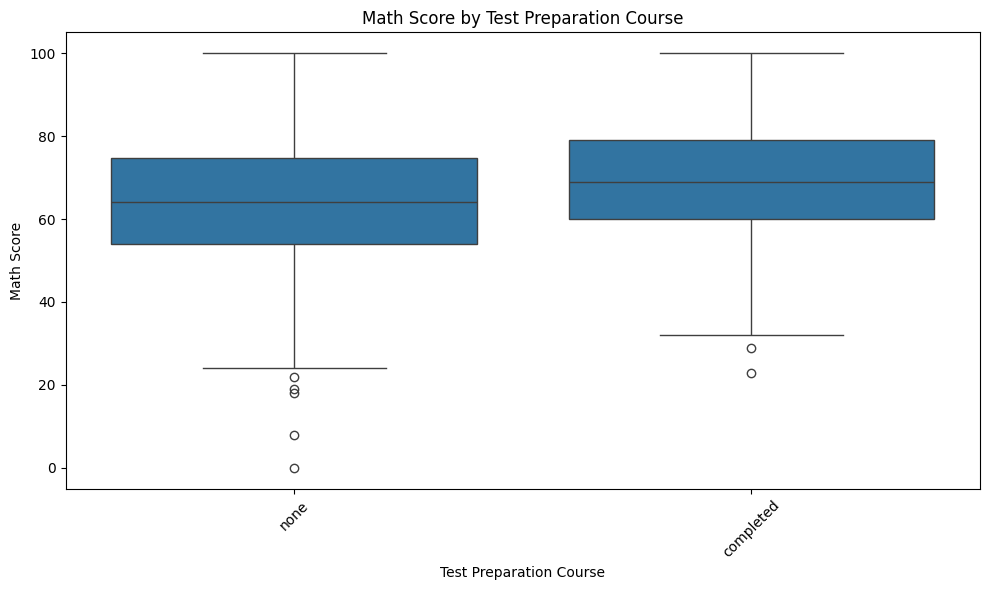

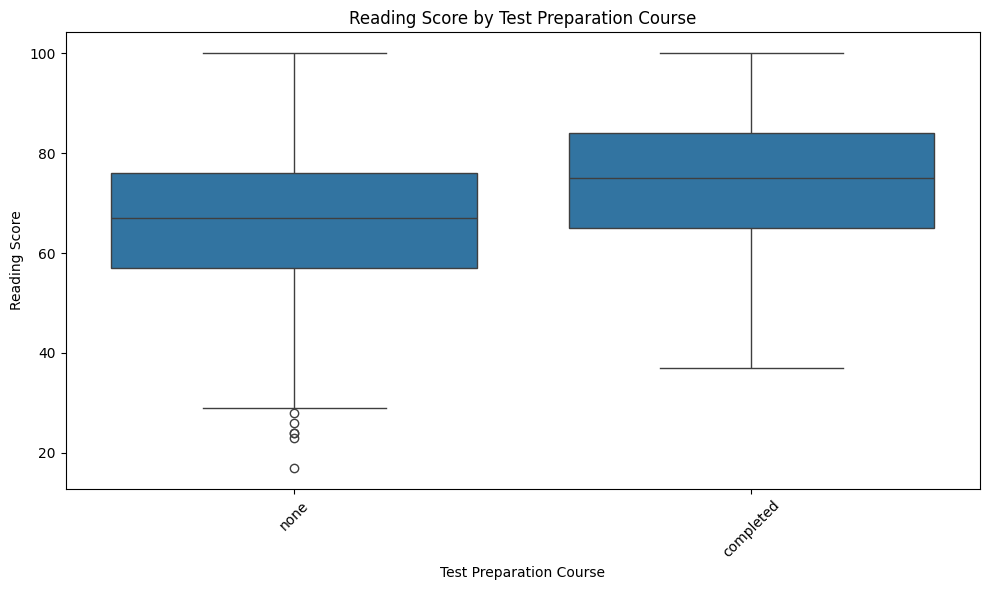

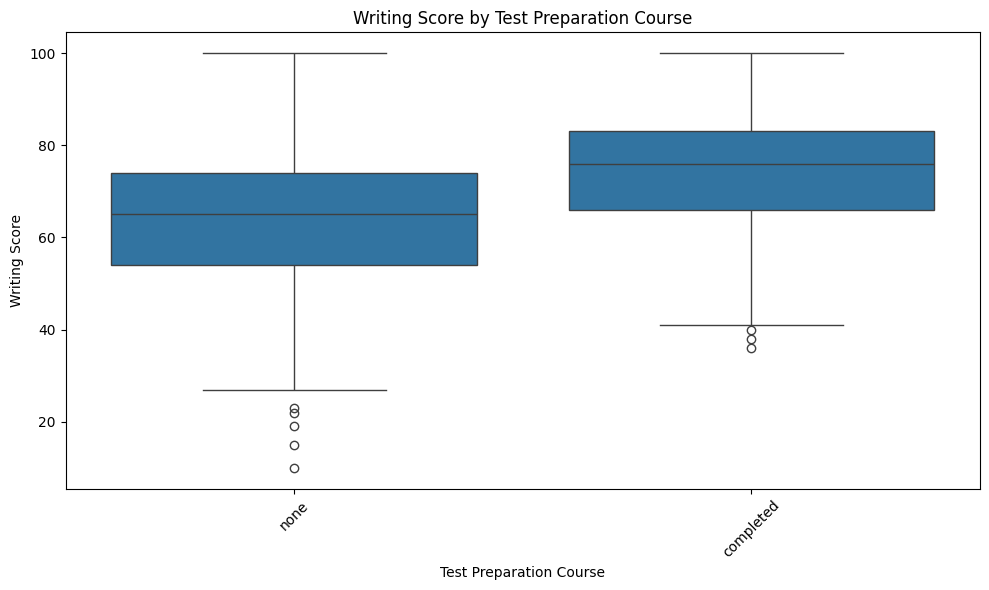


Observations for Test_Preparation_Course:
 - Gender: Females tend to have higher reading and writing scores than males, while males often have slightly higher math scores.
 - Race/Ethnicity: Scores vary across groups, with Group E often showing higher performance and Group A showing lower. 
 - Parental Level of Education: Students with parents having higher education levels (e.g., master's, bachelor's) generally achieve higher scores. 
 - Lunch: Students with 'standard' lunch tend to perform better across all subjects compared to those with 'free/reduced' lunch.
 - Test Preparation Course: Students who completed the test preparation course consistently achieve higher scores in all three subjects.


In [74]:
score_cols = ['math score', 'reading score', 'writing score']

for cat_col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=cat_col, y='math score', data=df6)
    plt.title(f'Math Score by {cat_col.replace("_", " ").title()}')
    plt.xlabel(cat_col.replace("_", " ").title())
    plt.ylabel('Math Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=cat_col, y='reading score', data=df6)
    plt.title(f'Reading Score by {cat_col.replace("_", " ").title()}')
    plt.xlabel(cat_col.replace("_", " ").title())
    plt.ylabel('Reading Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=cat_col, y='writing score', data=df6)
    plt.title(f'Writing Score by {cat_col.replace("_", " ").title()}')
    plt.xlabel(cat_col.replace("_", " ").title())
    plt.ylabel('Writing Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(f"\nObservations for {cat_col.replace(' ', '_').title()}:\n - Gender: Females tend to have higher reading and writing scores than males, while males often have slightly higher math scores.\n - Race/Ethnicity: Scores vary across groups, with Group E often showing higher performance and Group A showing lower. \n - Parental Level of Education: Students with parents having higher education levels (e.g., master's, bachelor's) generally achieve higher scores. \n - Lunch: Students with 'standard' lunch tend to perform better across all subjects compared to those with 'free/reduced' lunch.\n - Test Preparation Course: Students who completed the test preparation course consistently achieve higher scores in all three subjects.")

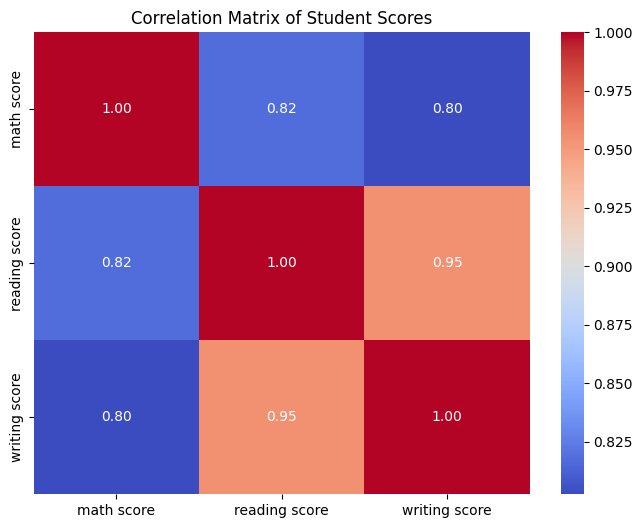

As expected, there is a very strong positive correlation between all three scores (math, reading, writing). This indicates that students who perform well in one subject tend to perform well in others.


In [75]:
plt.figure(figsize=(8, 6))
sns.heatmap(df6[score_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Student Scores')
plt.show()
print("As expected, there is a very strong positive correlation between all three scores (math, reading, writing). This indicates that students who perform well in one subject tend to perform well in others.")

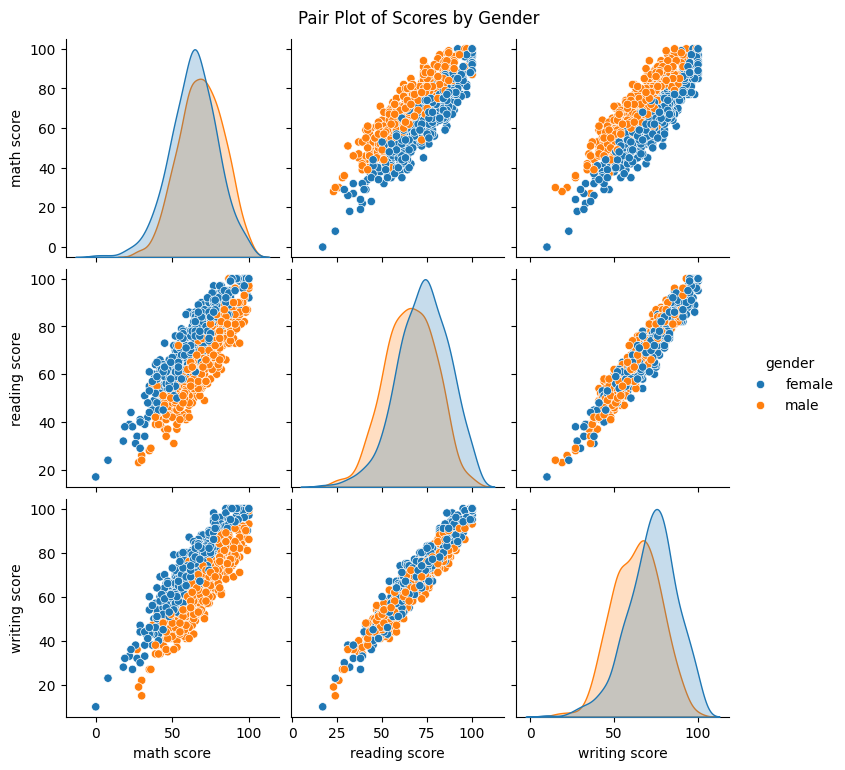

The pair plot visually reinforces the strong correlations between scores and highlights the slight gender differences in performance across subjects.


In [76]:
sns.pairplot(df6, vars=score_cols, hue='gender', diag_kind='kde')
plt.suptitle('Pair Plot of Scores by Gender', y=1.02)
plt.show()
print("The pair plot visually reinforces the strong correlations between scores and highlights the slight gender differences in performance across subjects.")

In [77]:
df7 = pd.read_csv("diabetes.csv")
df7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB


In [78]:
print("\n Statistics:")
print(df7.describe().T)


 Statistics:
          count          mean           std      min      25%       50%  \
id        403.0  15978.310174  11881.122124  1000.00  4792.50  15766.00   
chol      402.0    207.845771     44.445557    78.00   179.00    204.00   
stab.glu  403.0    106.672457     53.076655    48.00    81.00     89.00   
hdl       402.0     50.445274     17.262626    12.00    38.00     46.00   
ratio     402.0      4.521642      1.727886     1.50     3.20      4.20   
glyhb     390.0      5.589769      2.242595     2.68     4.38      4.84   
age       403.0     46.851117     16.312333    19.00    34.00     45.00   
height    398.0     66.020101      3.918515    52.00    63.00     66.00   
weight    402.0    177.592040     40.340666    99.00   151.00    172.50   
bp.1s     398.0    136.904523     22.741033    90.00   121.25    136.00   
bp.1d     398.0     83.321608     13.589227    48.00    75.00     82.00   
bp.2s     141.0    152.382979     21.712952   110.00   138.00    149.00   
bp.2d     1

In [79]:
print("\nMissing Values:")
missing_values = df7.isnull().sum()
print(missing_values)


Missing Values:
id            0
chol          1
stab.glu      0
hdl           1
ratio         1
glyhb        13
location      0
age           0
gender        0
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64


In [80]:
print(df7.duplicated().sum())

0


In [81]:
df7_cleaned = df7.copy()

drop_cols = ['bp.2s', 'bp.2d']
df7_cleaned = df7_cleaned.drop(columns=drop_cols)

numerical_cols_to_impute = df7_cleaned.select_dtypes(include=np.number).columns
for col in numerical_cols_to_impute:
    if df7_cleaned[col].isnull().any():
        df7_cleaned[col] = df7_cleaned[col].fillna(df7_cleaned[col].median())

categorical_cols_to_impute = df7_cleaned.select_dtypes(include='object').columns
for col in categorical_cols_to_impute:
    if df7_cleaned[col].isnull().any():
        df7_cleaned[col] = df7_cleaned[col].fillna(df7_cleaned[col].mode()[0])

print("Missing values after cleaning:")
print(df7_cleaned.isnull().sum())

Missing values after cleaning:
id          0
chol        0
stab.glu    0
hdl         0
ratio       0
glyhb       0
location    0
age         0
gender      0
height      0
weight      0
frame       0
bp.1s       0
bp.1d       0
waist       0
hip         0
time.ppn    0
dtype: int64


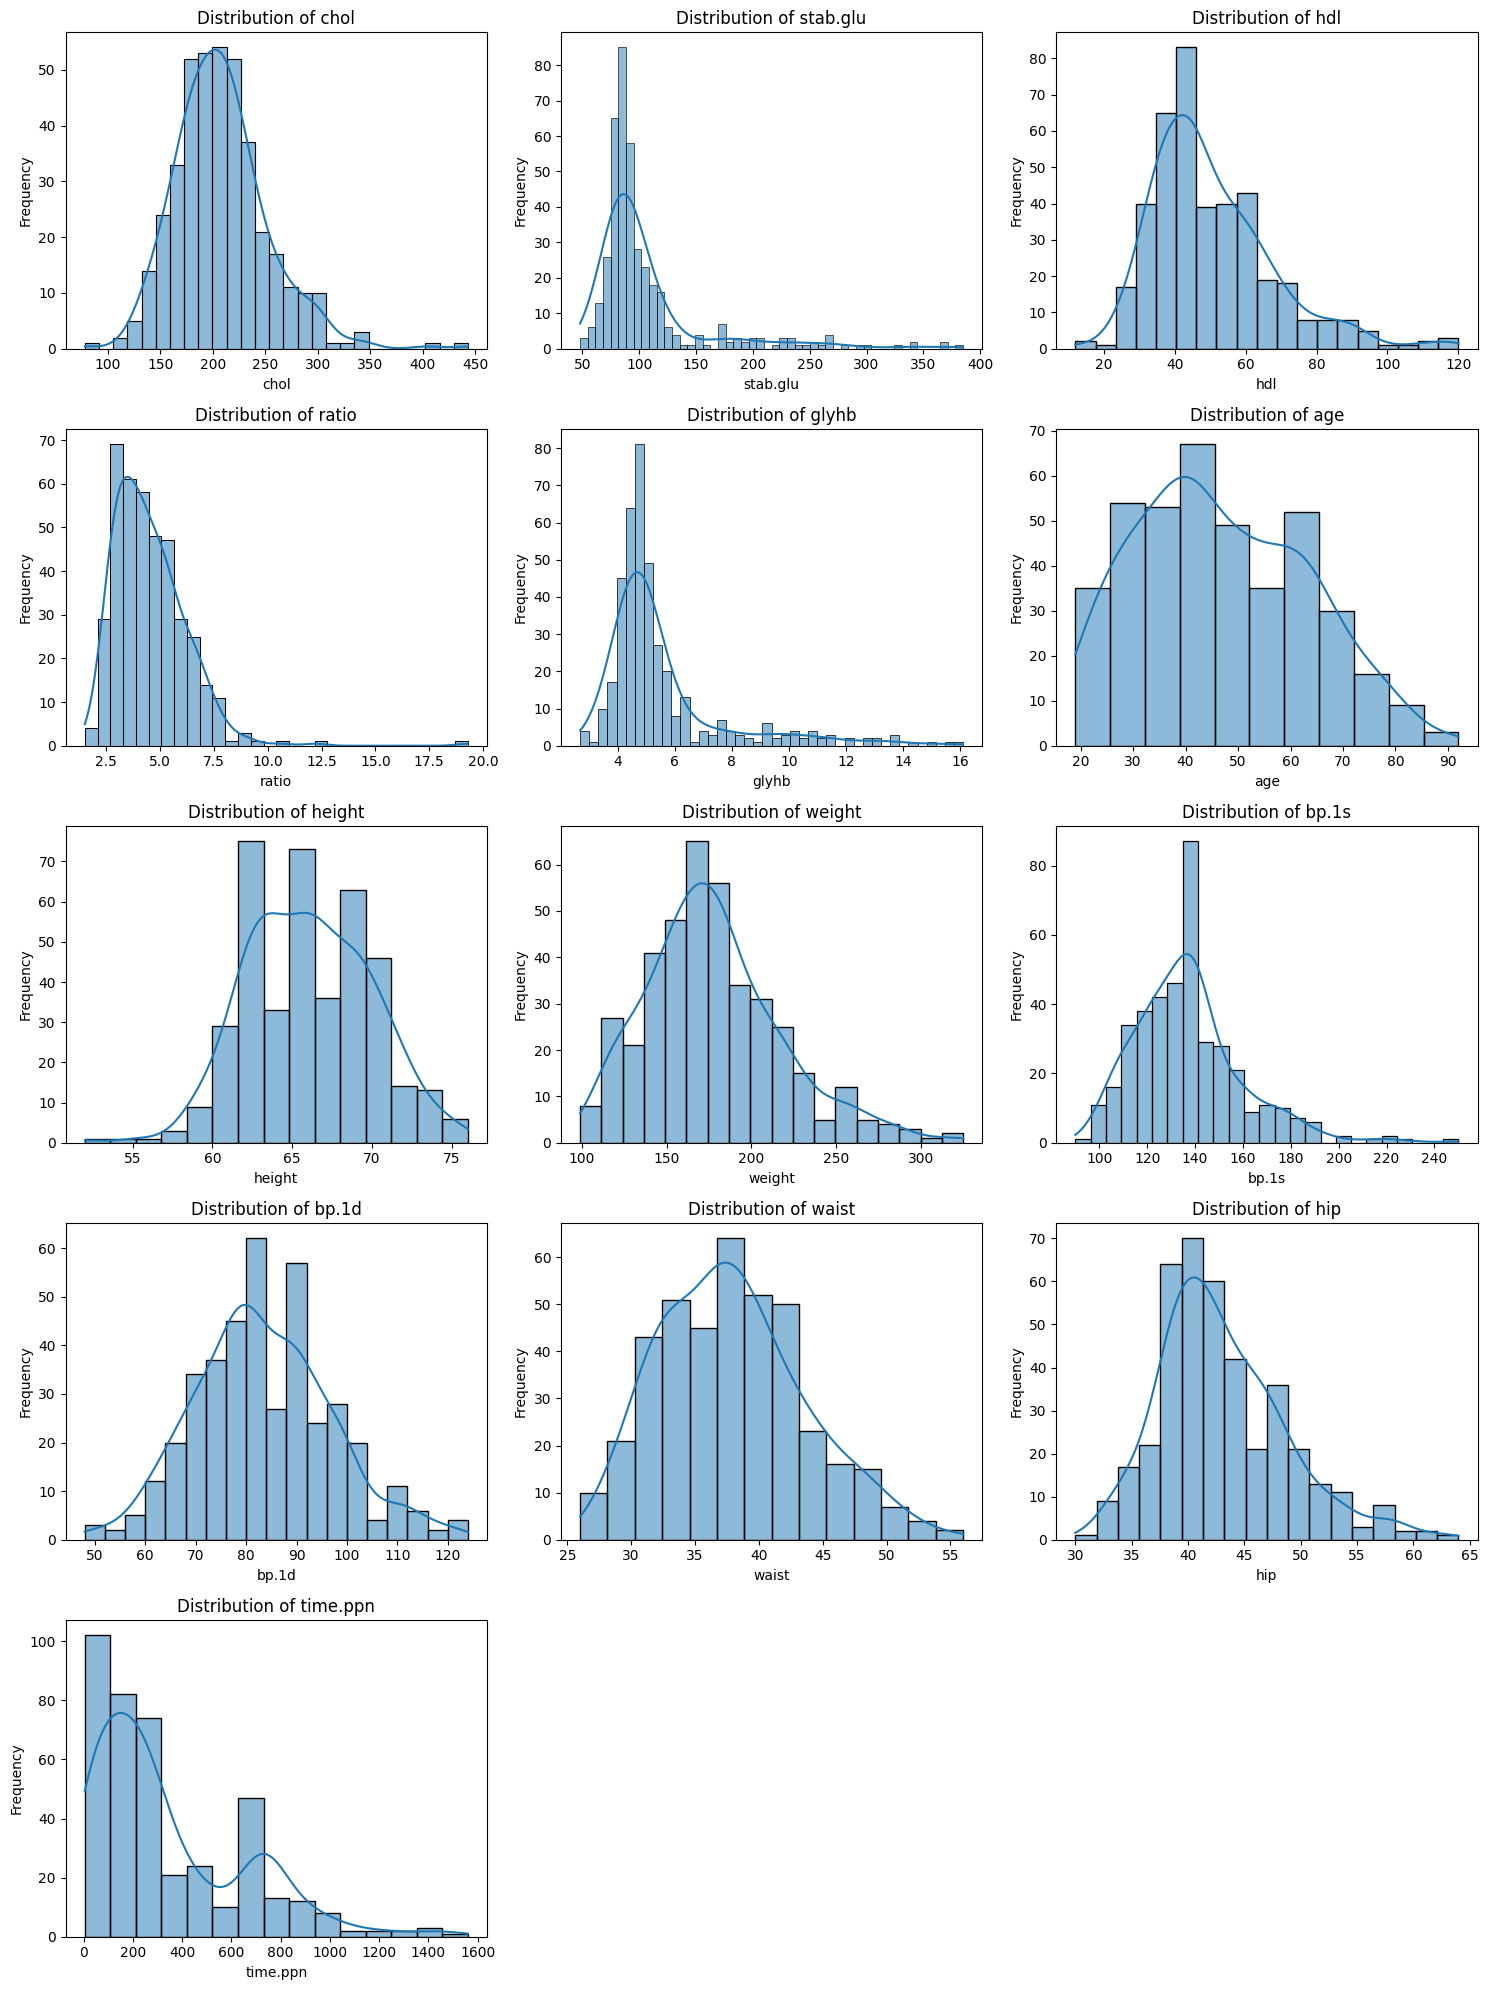

Insights: The numerical features show different distributions. Some variables are skewed, while others are relatively symmetrical. These distributions should be considered when analyzing the dataset.


In [82]:
numerical_features = df7_cleaned.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_features:
    numerical_features.remove('id')
n = len(numerical_features)
rows = (n + 2) // 3
plt.figure(figsize=(15, rows * 4))
for i, feature in enumerate(numerical_features):
    plt.subplot(rows, 3, i + 1)
    sns.histplot(data=df7_cleaned, x=feature, kde=True)
    plt.title(f'Distribution of {feature}', fontsize=12)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("Insights: The numerical features show different distributions. ""Some variables are skewed, while others are relatively symmetrical. ""These distributions should be considered when analyzing the dataset.")

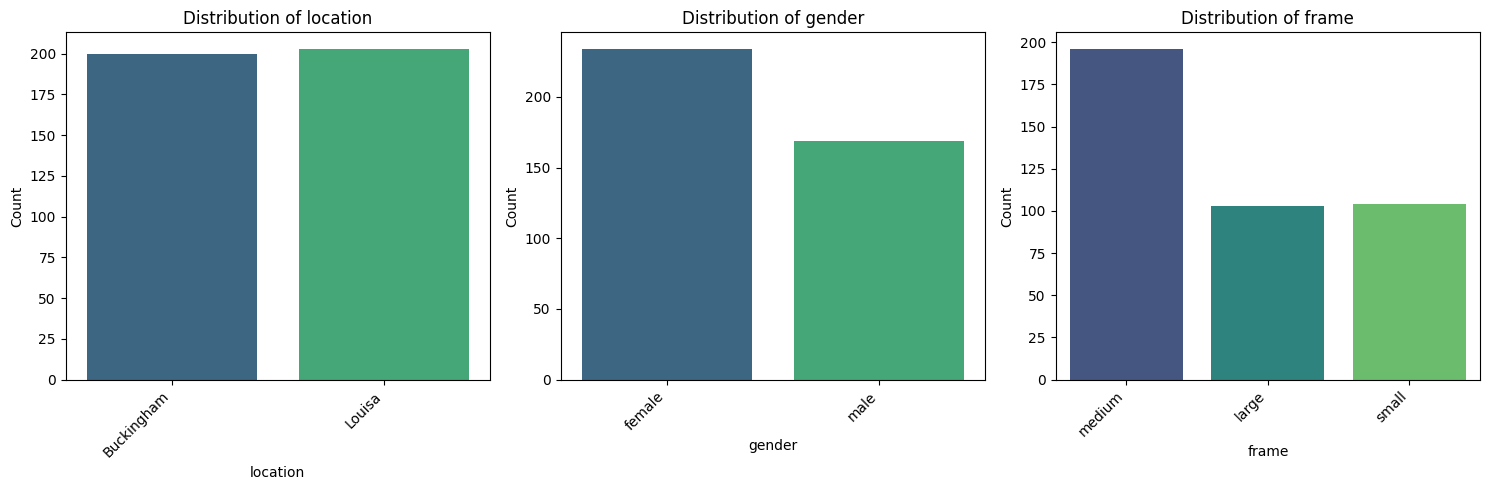

Categorical features show varying class balances, important for further analysis.


In [83]:
categorical_features = df7_cleaned.select_dtypes(include='object').columns

plt.figure(figsize=(15, 5))
for i, feature in enumerate(categorical_features):
    plt.subplot(1, len(categorical_features), i + 1)
    sns.countplot(x=feature, data=df7_cleaned, hue=feature, palette='viridis', legend=False)
    plt.title(f'Distribution of {feature}', fontsize=12)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Categorical features show varying class balances, important for further analysis.")

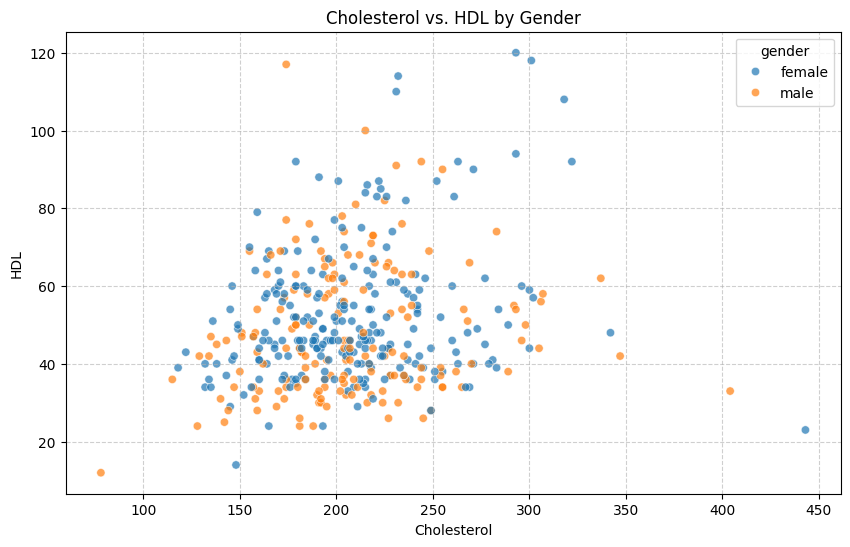

HDL generally increases with total cholesterol, with some gender-based separation.


In [84]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='chol', y='hdl', hue='gender', data=df7_cleaned, alpha=0.7)
plt.title('Cholesterol vs. HDL by Gender')
plt.xlabel('Cholesterol')
plt.ylabel('HDL')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print("HDL generally increases with total cholesterol, with some gender-based separation.")

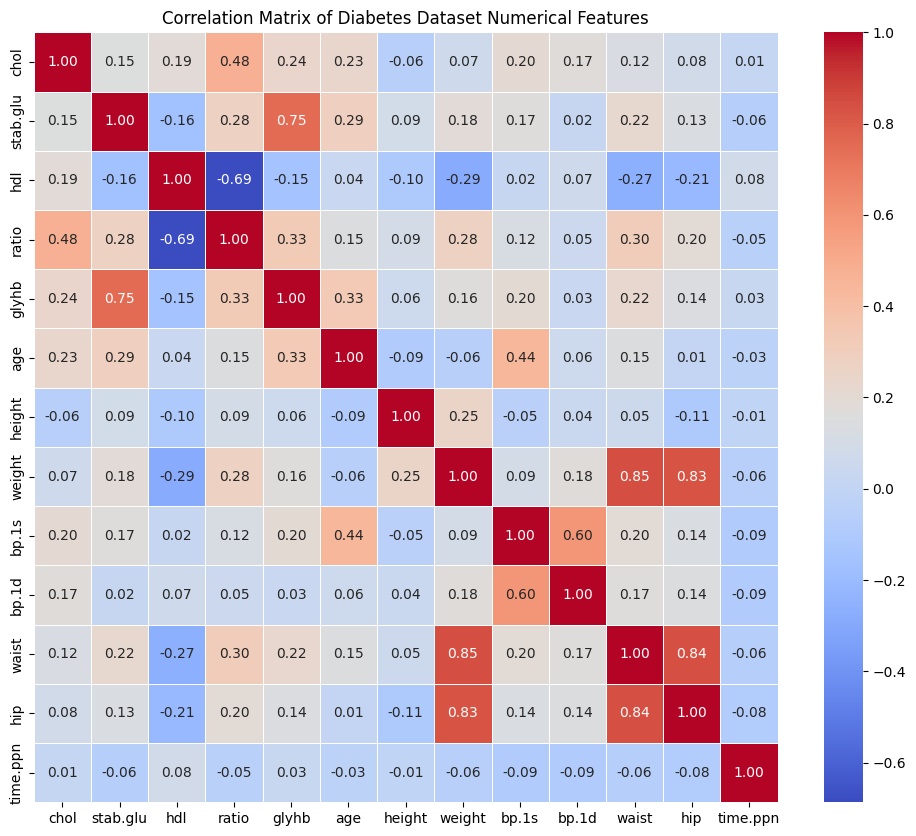

Strong correlations exist between some features like waist and hip, and blood pressure readings.


In [85]:
plt.figure(figsize=(12, 10))
correlation_matrix = df7_cleaned.select_dtypes(include=np.number).drop(columns=['id']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Diabetes Dataset Numerical Features')
plt.show()
print("Strong correlations exist between some features like waist and hip, and blood pressure readings.")

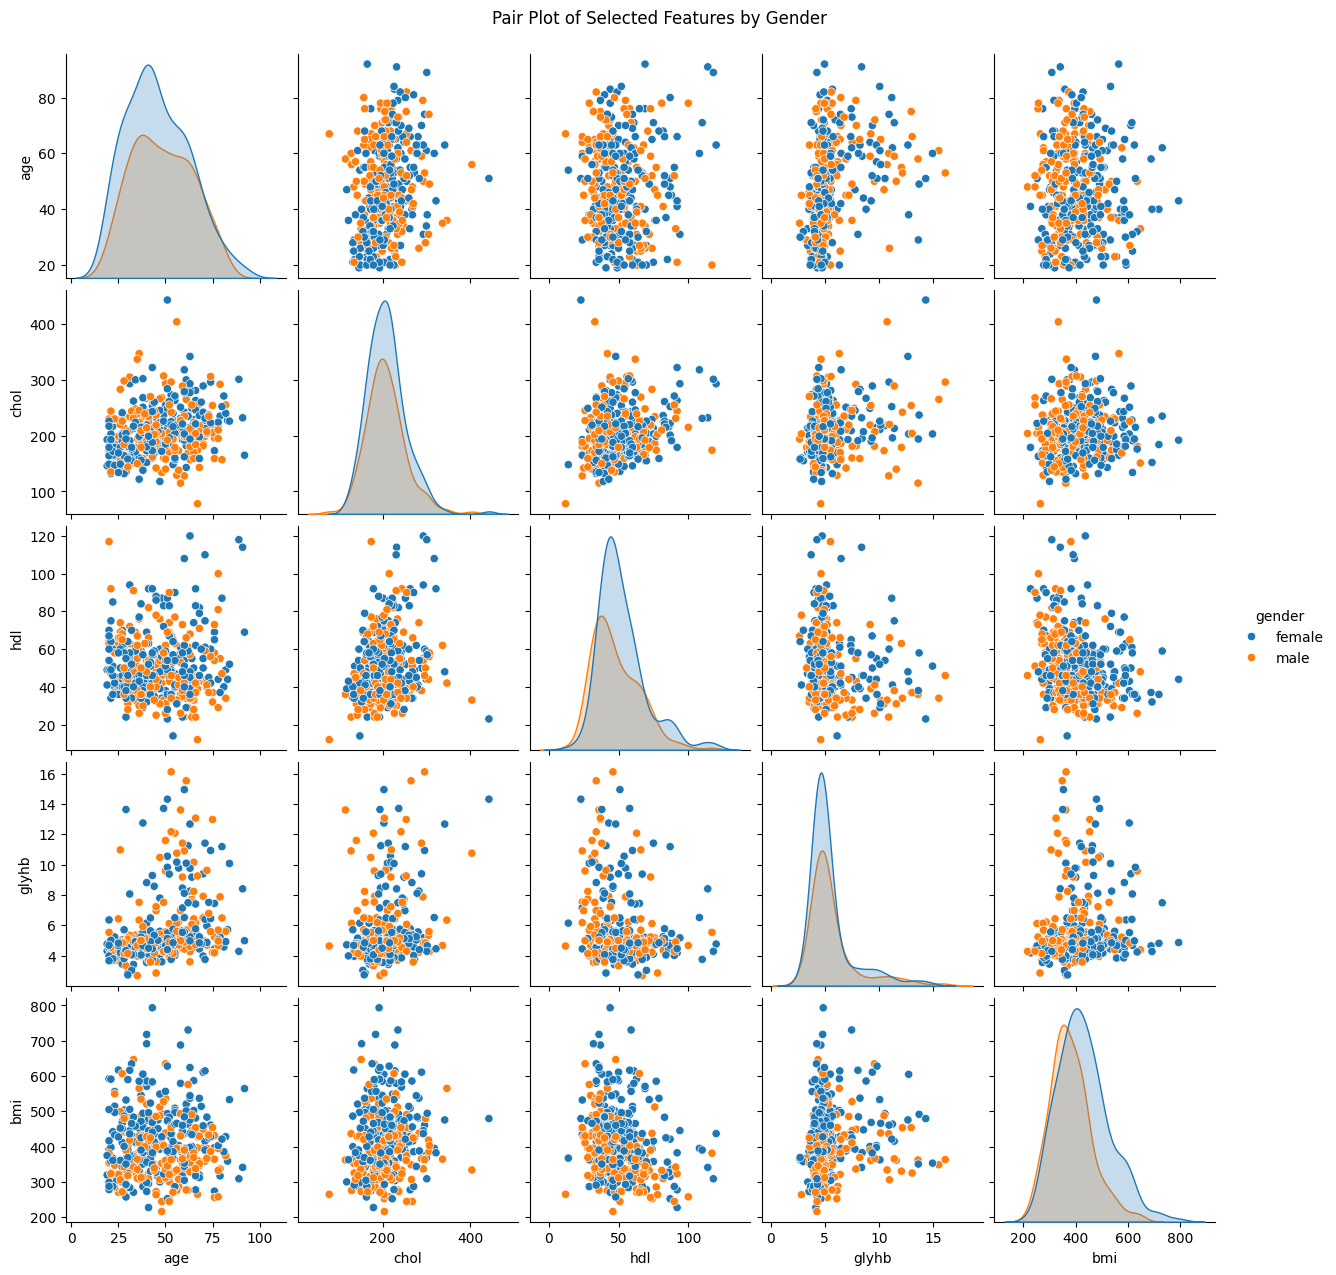

Pair plot reveals relationships and distributions between key health indicators, highlighting potential gender differences.


In [86]:
selected_features = ['age', 'chol', 'hdl', 'glyhb', 'bmi', 'gender']
df7_cleaned['bmi'] = df7_cleaned['weight'] / (df7_cleaned['height']/100)**2

sns.pairplot(df7_cleaned[selected_features].dropna(), hue='gender', diag_kind='kde')
plt.suptitle('Pair Plot of Selected Features by Gender', y=1.02)
plt.show()
print("Pair plot reveals relationships and distributions between key health indicators, highlighting potential gender differences.")

In [87]:
df8 = pd.read_csv("cancer.csv")
df8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [88]:
print("\n Statistics:")
print(df8.describe().T)


 Statistics:
                         count          mean           std          min  \
id                       569.0  3.037183e+07  1.250206e+08  8670.000000   
radius_mean              569.0  1.412729e+01  3.524049e+00     6.981000   
texture_mean             569.0  1.928965e+01  4.301036e+00     9.710000   
perimeter_mean           569.0  9.196903e+01  2.429898e+01    43.790000   
area_mean                569.0  6.548891e+02  3.519141e+02   143.500000   
smoothness_mean          569.0  9.636028e-02  1.406413e-02     0.052630   
compactness_mean         569.0  1.043410e-01  5.281276e-02     0.019380   
concavity_mean           569.0  8.879932e-02  7.971981e-02     0.000000   
concave points_mean      569.0  4.891915e-02  3.880284e-02     0.000000   
symmetry_mean            569.0  1.811619e-01  2.741428e-02     0.106000   
fractal_dimension_mean   569.0  6.279761e-02  7.060363e-03     0.049960   
radius_se                569.0  4.051721e-01  2.773127e-01     0.111500   
texture_se 

In [89]:
print("\nMissing Values:")
missing_values = df8.isnull().sum()
print(missing_values)


Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_wors

In [90]:
print(df8.duplicated().sum())

0


In [91]:
df8_cleaned = df8.copy()
df8_cleaned = df8_cleaned.drop(columns=['id', 'Unnamed: 32'])
print("\nMissing values after cleaning:")
print(df8_cleaned.isnull().sum())


Missing values after cleaning:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


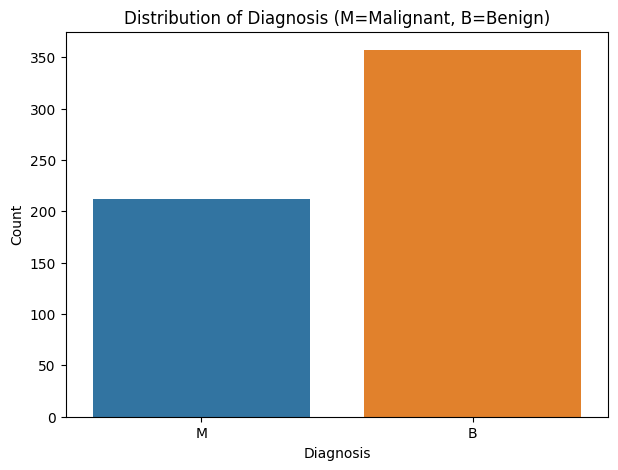

The dataset shows a higher count of Benign (B) diagnoses compared to Malignant (M).


In [92]:
plt.figure(figsize=(7, 5))
sns.countplot(x='diagnosis', data=df8_cleaned, hue='diagnosis', legend=False)
plt.title('Distribution of Diagnosis (M=Malignant, B=Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()
print("The dataset shows a higher count of Benign (B) diagnoses compared to Malignant (M).")

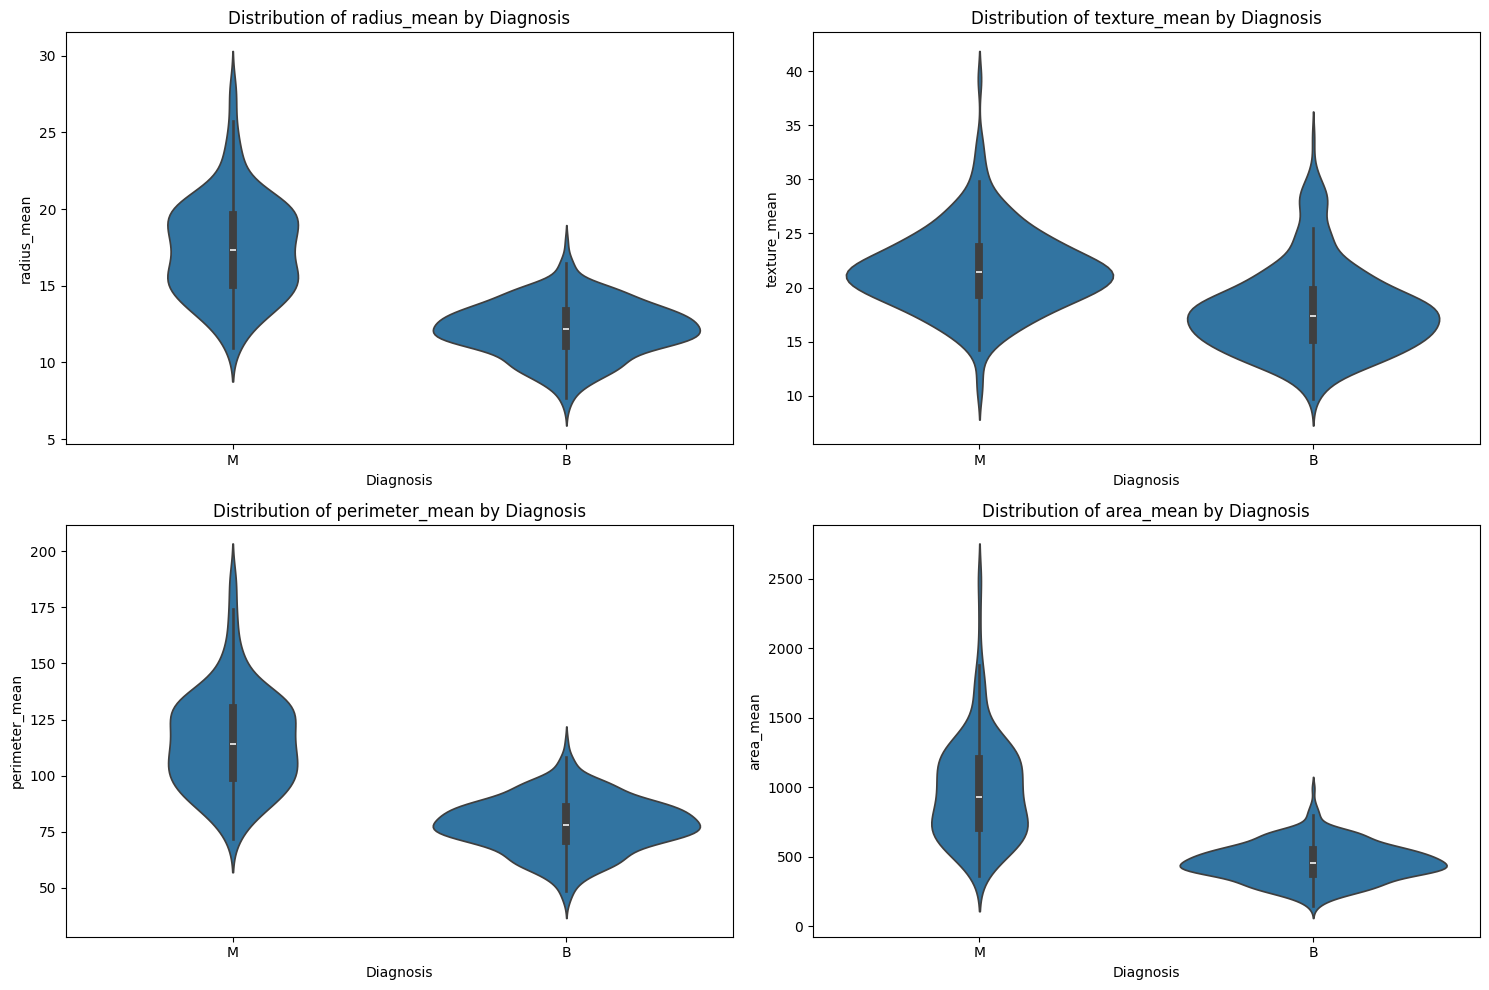

Malignant tumors generally show larger mean values for radius, texture, perimeter, and area compared to benign tumors, indicating these features are strong predictors.


In [93]:
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x='diagnosis', y=feature, data=df8_cleaned)
    plt.title(f'Distribution of {feature} by Diagnosis')
    plt.xlabel('Diagnosis')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()
print("Malignant tumors generally show larger mean values for radius, texture, perimeter, and area compared to benign tumors, indicating these features are strong predictors.")

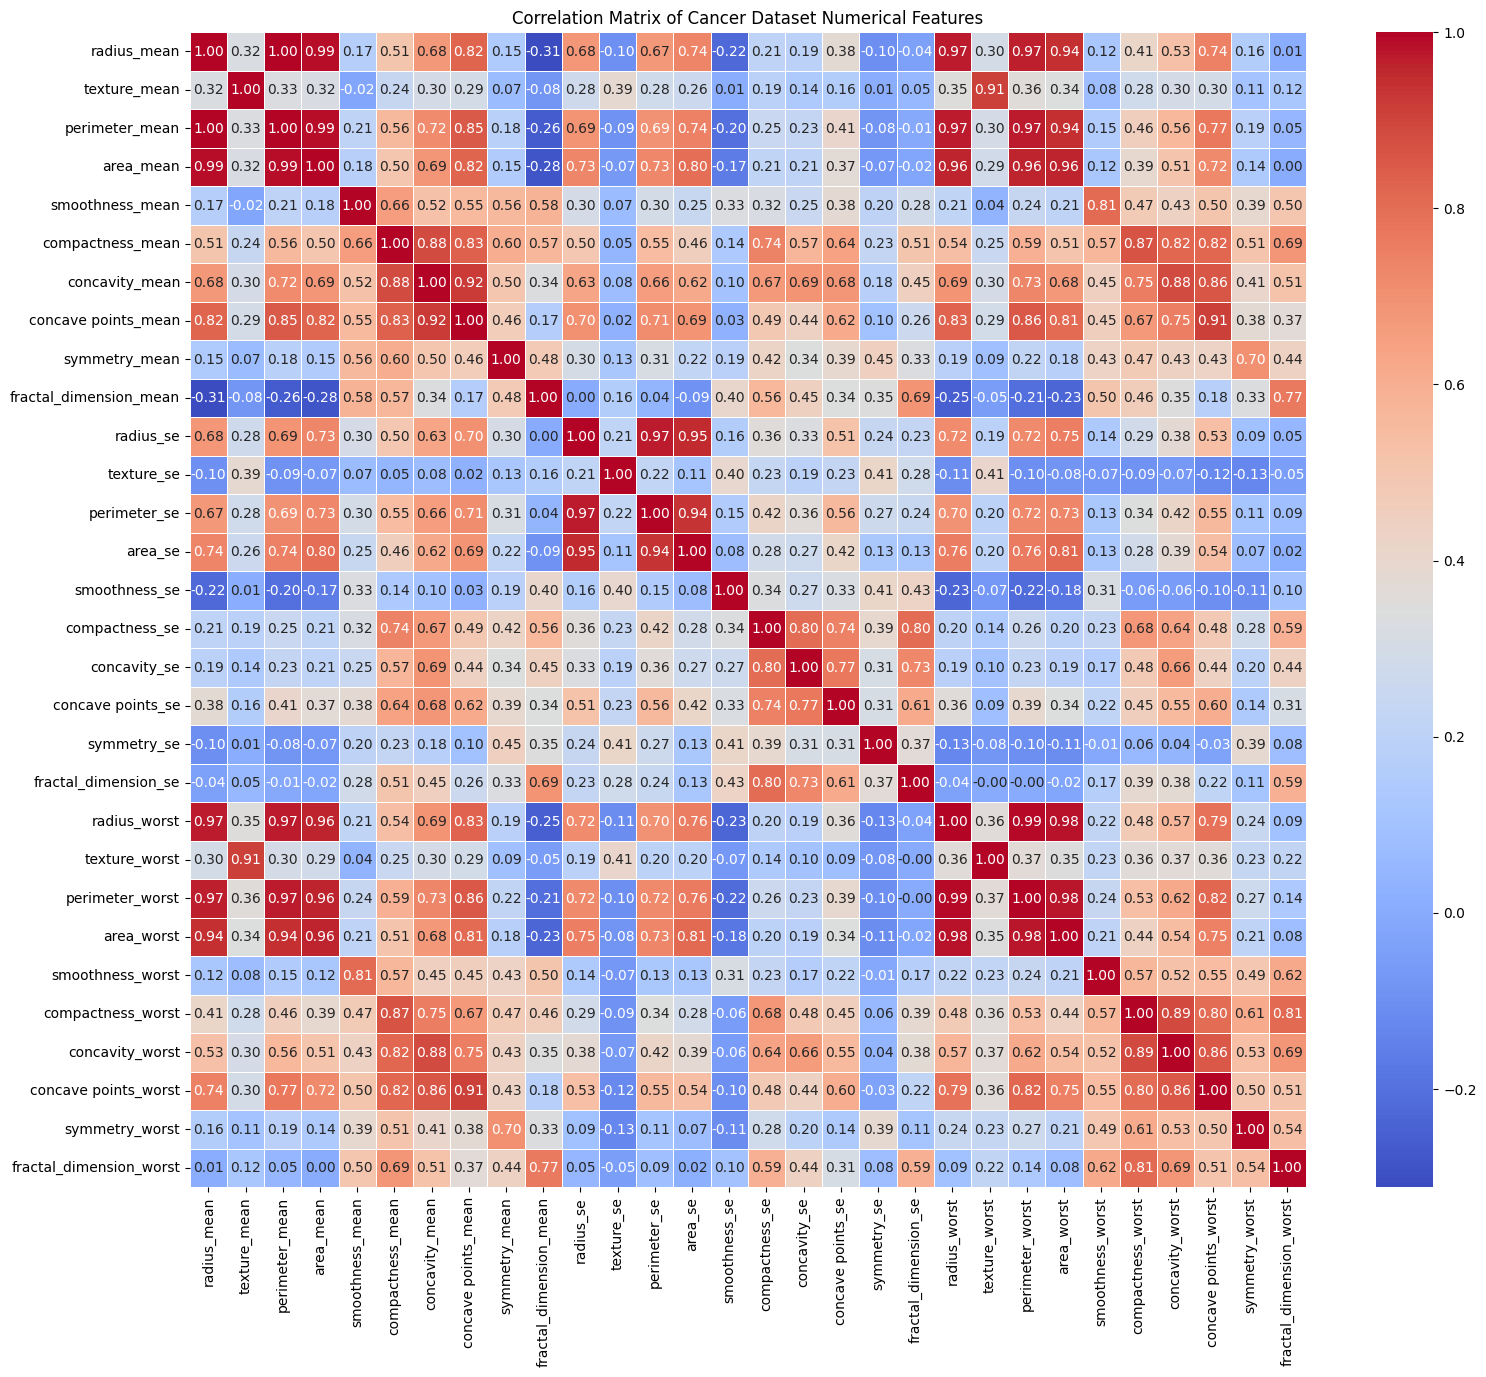

Many features related to size and shape (radius, perimeter, area) are highly correlated with each other, both in mean, standard error, and 'worst' categories. This suggests high multicollinearity but also that these characteristics are interconnected in tumor morphology.


In [94]:
plt.figure(figsize=(18, 15))
numerical_cols_df8 = df8_cleaned.select_dtypes(include=np.number).columns
sns.heatmap(df8_cleaned[numerical_cols_df8].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Cancer Dataset Numerical Features')
plt.show()
print("Many features related to size and shape (radius, perimeter, area) are highly correlated with each other, both in mean, standard error, and 'worst' categories. This suggests high multicollinearity but also that these characteristics are interconnected in tumor morphology.")

In [95]:
df9 = pd.read_csv("heart.csv")
df9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [96]:
print("\n Statistics:")
print(df9.describe().T)


 Statistics:
           count        mean        std    min    25%    50%    75%    max
age       1025.0   54.434146   9.072290   29.0   48.0   56.0   61.0   77.0
sex       1025.0    0.695610   0.460373    0.0    0.0    1.0    1.0    1.0
cp        1025.0    0.942439   1.029641    0.0    0.0    1.0    2.0    3.0
trestbps  1025.0  131.611707  17.516718   94.0  120.0  130.0  140.0  200.0
chol      1025.0  246.000000  51.592510  126.0  211.0  240.0  275.0  564.0
fbs       1025.0    0.149268   0.356527    0.0    0.0    0.0    0.0    1.0
restecg   1025.0    0.529756   0.527878    0.0    0.0    1.0    1.0    2.0
thalach   1025.0  149.114146  23.005724   71.0  132.0  152.0  166.0  202.0
exang     1025.0    0.336585   0.472772    0.0    0.0    0.0    1.0    1.0
oldpeak   1025.0    1.071512   1.175053    0.0    0.0    0.8    1.8    6.2
slope     1025.0    1.385366   0.617755    0.0    1.0    1.0    2.0    2.0
ca        1025.0    0.754146   1.030798    0.0    0.0    0.0    1.0    4.0
thal      1

In [97]:
print("\nMissing Values:")
missing_values = df9.isnull().sum()
print(missing_values)


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [98]:
print(df9.duplicated().sum())

723


In [99]:
df9_cleaned = df9.drop_duplicates().copy()
print(f"rows after dropping duplicates: {len(df9_cleaned)}")

rows after dropping duplicates: 302


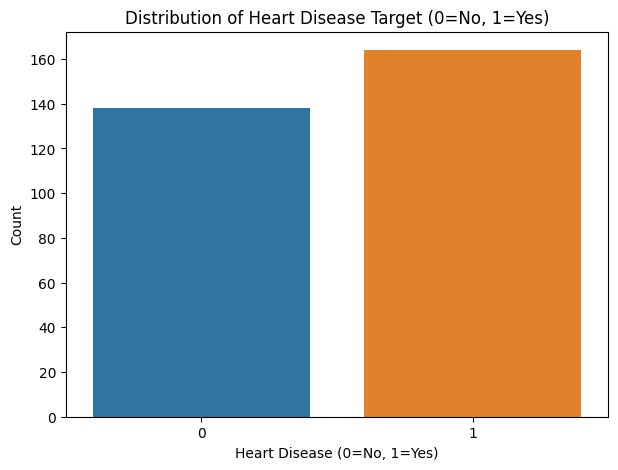

The dataset is relatively balanced between individuals with and without heart disease, which is good for model training.


In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='target', data=df9_cleaned, hue='target', legend=False)
plt.title('Distribution of Heart Disease Target (0=No, 1=Yes)')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()
print("The dataset is relatively balanced between individuals with and without heart disease, which is good for model training.")

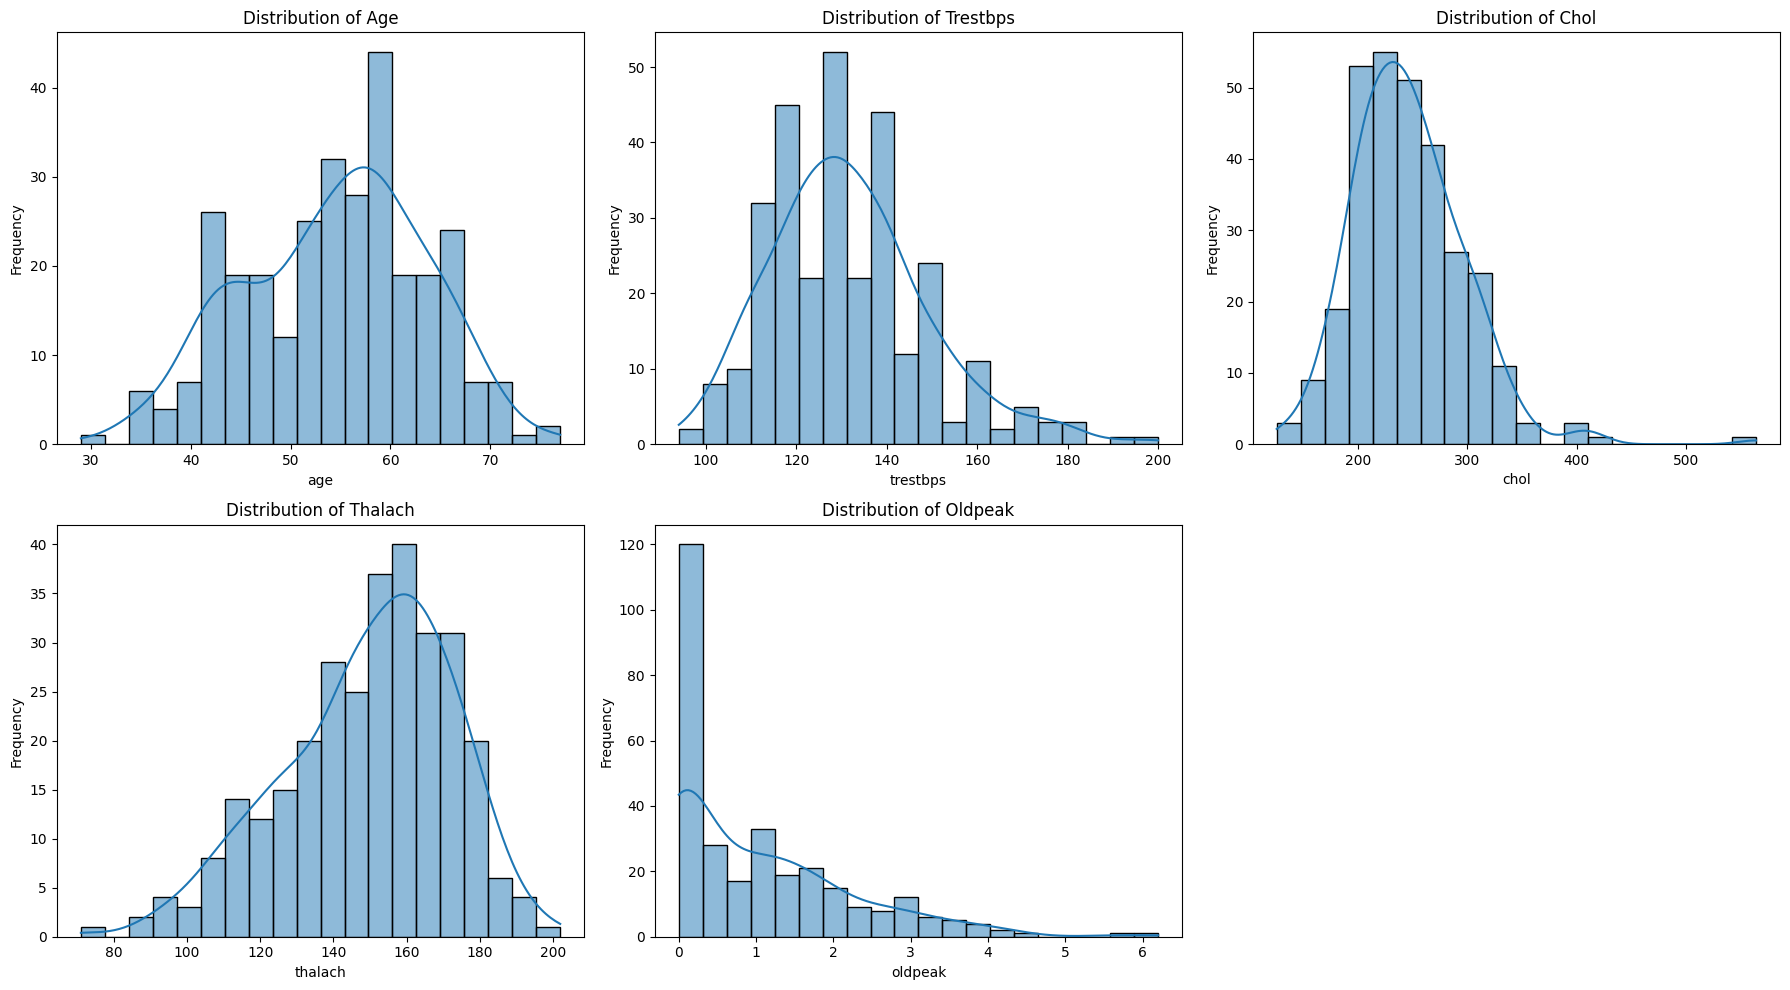

Numerical features like age, resting blood pressure, cholesterol, max heart rate, and ST depression show varied distributions, some approaching normal, others skewed.


In [101]:
numerical_features_df9 = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(18, 10))
for i, feature in enumerate(numerical_features_df9):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df9_cleaned[feature], kde=True, bins=20)
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("Numerical features like age, resting blood pressure, cholesterol, max heart rate, and ST depression show varied distributions, some approaching normal, others skewed.")

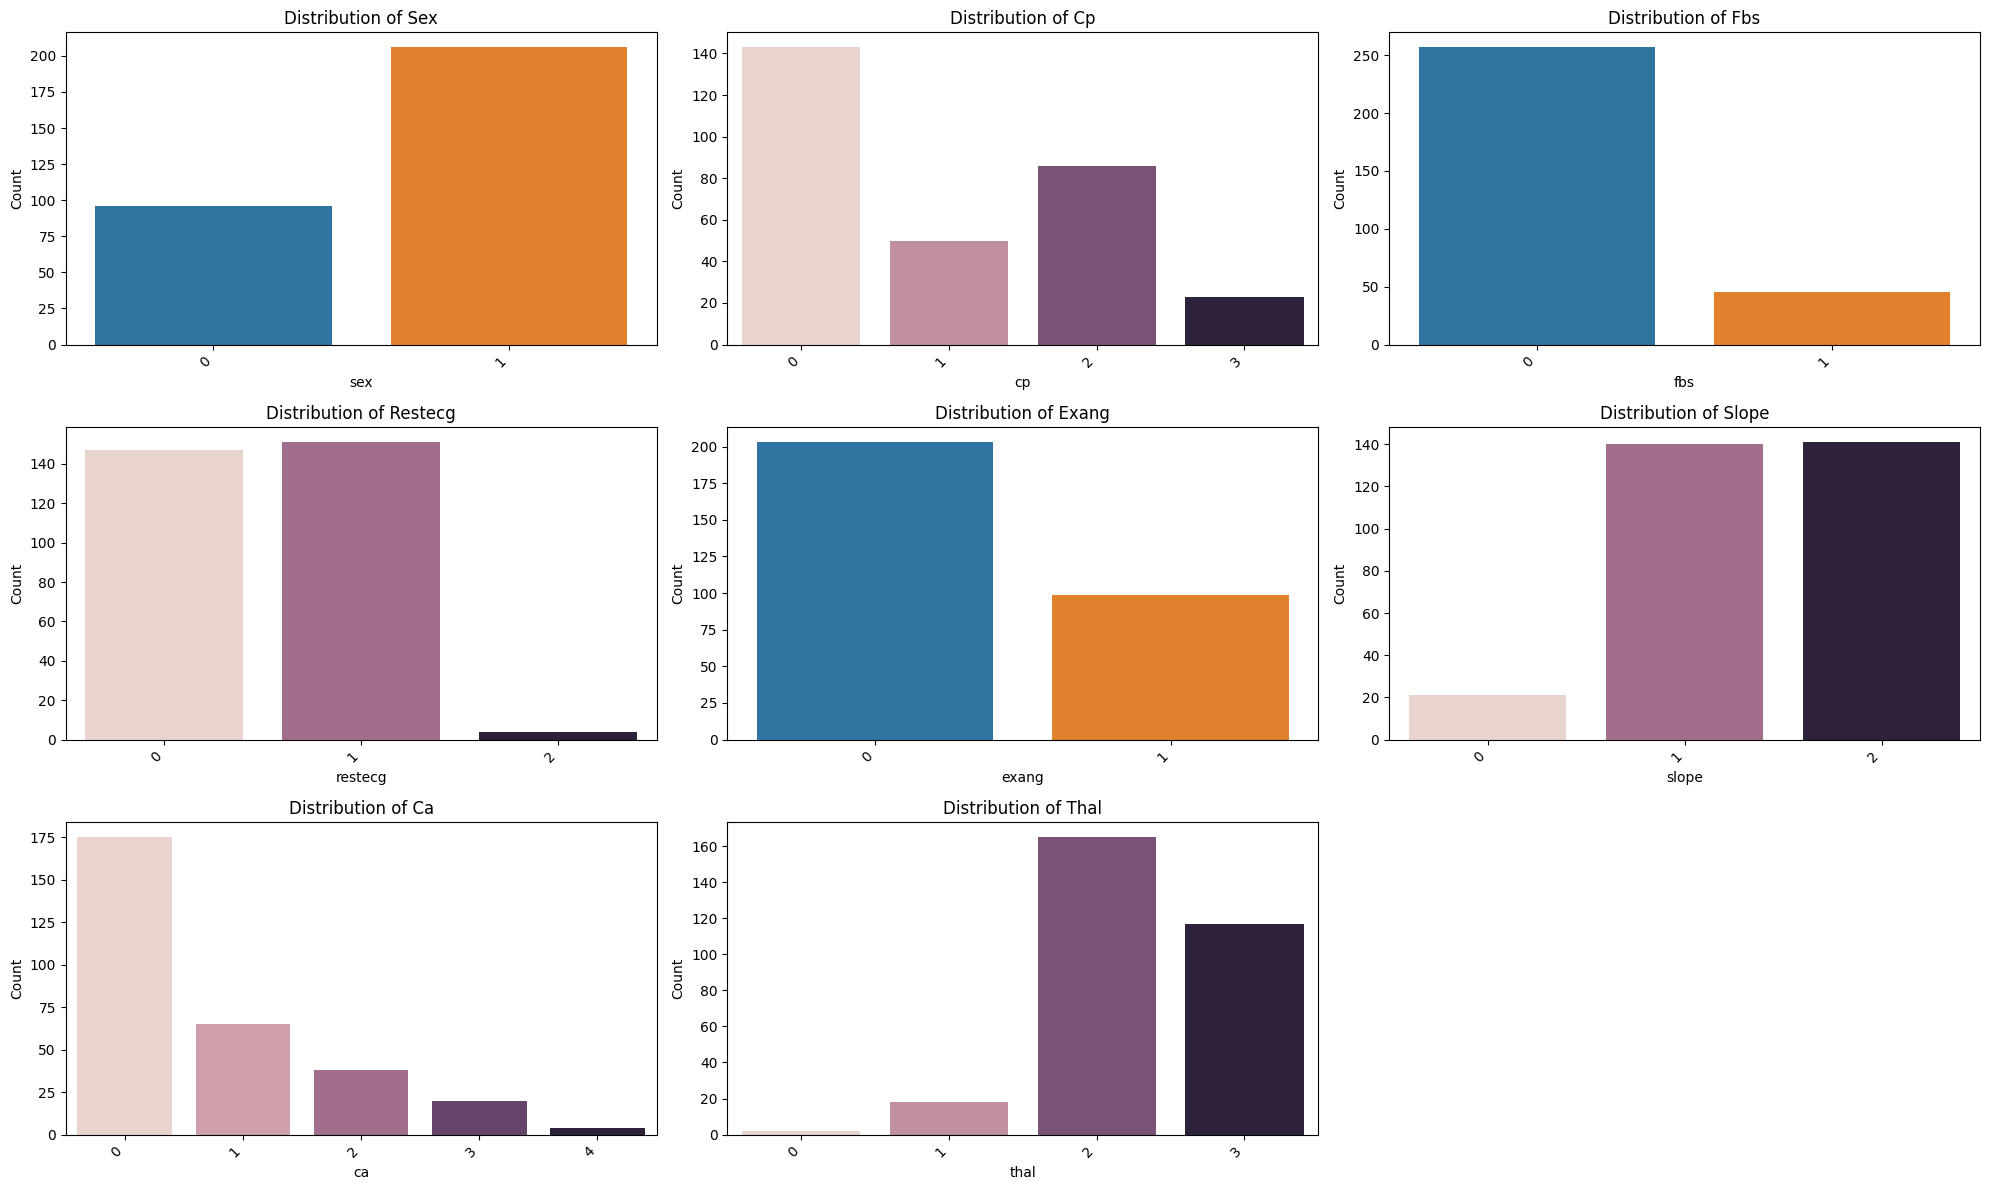

Categorical features show distinct distributions, for example, sex is predominantly male, and chest pain types are varied.


In [102]:
categorical_features_df9 = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(20, 12))
for i, feature in enumerate(categorical_features_df9):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=feature, data=df9_cleaned, hue=feature, legend=False)
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Categorical features show distinct distributions, for example, sex is predominantly male, and chest pain types are varied.")

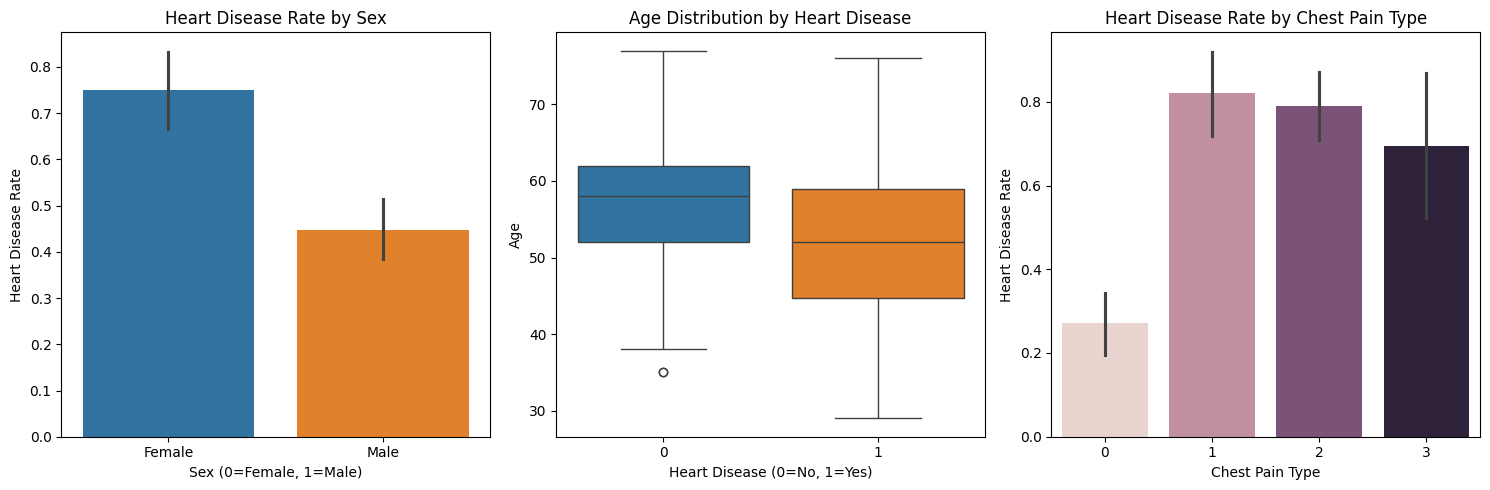

Females tend to have a higher heart disease rate than males. Individuals with heart disease show a slightly different age distribution. Certain chest pain types are more prevalent in heart disease patients.


In [103]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='sex', y='target', data=df9_cleaned, hue='sex', legend=False)
plt.title('Heart Disease Rate by Sex')
plt.xlabel('Sex (0=Female, 1=Male)')
plt.ylabel('Heart Disease Rate')
plt.xticks([0, 1], ['Female', 'Male'])

plt.subplot(1, 3, 2)
sns.boxplot(x='target', y='age', data=df9_cleaned, hue='target', legend=False)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Age')

plt.subplot(1, 3, 3)
sns.barplot(x='cp', y='target', data=df9_cleaned, hue='cp', legend=False)
plt.title('Heart Disease Rate by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Heart Disease Rate')

plt.tight_layout()
plt.show()
print("Females tend to have a higher heart disease rate than males. Individuals with heart disease show a slightly different age distribution. Certain chest pain types are more prevalent in heart disease patients.")

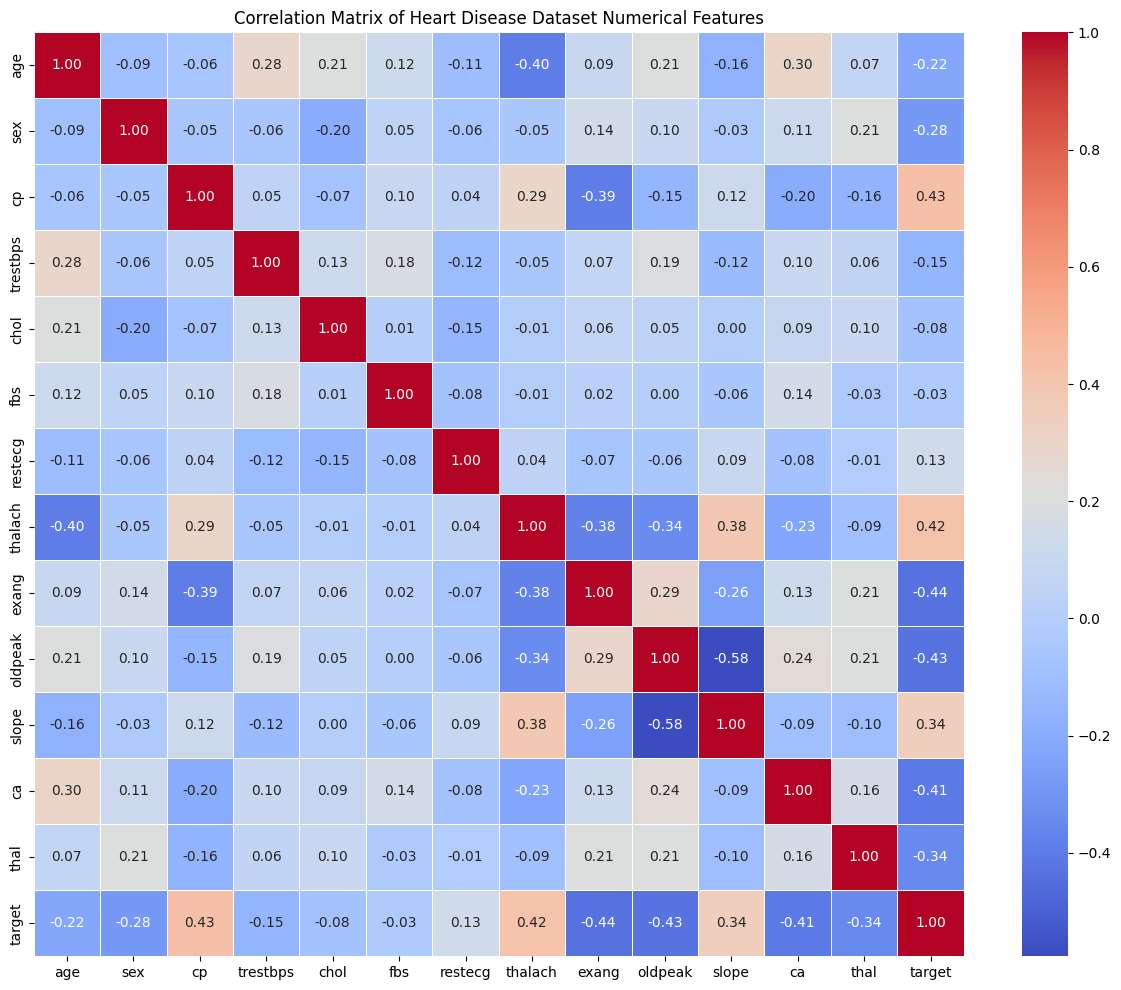

The correlation matrix reveals relationships between various features. For example, 'thalach' (maximum heart rate achieved) shows a notable correlation with the 'target' variable, as does 'exang' (exercise induced angina).


In [104]:
plt.figure(figsize=(15, 12))
correlation_matrix_df9 = df9_cleaned.corr(numeric_only=True)
sns.heatmap(correlation_matrix_df9, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Heart Disease Dataset Numerical Features')
plt.show()
print("The correlation matrix reveals relationships between various features. For example, 'thalach' (maximum heart rate achieved) shows a notable correlation with the 'target' variable, as does 'exang' (exercise induced angina).")

In [105]:
df10 = pd.read_csv("vgsales.csv")

In [106]:
print(df10.info())
print("\n Statistics:")
print(df10.describe().T)
print("\nMissing Values:")
print(df10.isnull().sum())
print("\nDuplicate rows:")
print(df10.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None

 Statistics:
                count         mean          std      min      25%      50%  \
Rank          16598.0  8300.605254  4791.853933     1.00  4151.25  8300.50   
Year          16327.0  2006.406443     5.828981  1980.00  2003.00  2007.00   
NA_Sales      165

In [107]:
df10_cleaned = df10.copy()
df10_cleaned = df10_cleaned.drop(columns=['Rank'])

if 'Year' in df10_cleaned.columns:
    df10_cleaned['Year'] = df10_cleaned['Year'].fillna(df10_cleaned['Year'].median())
if 'Publisher' in df10_cleaned.columns:
    df10_cleaned['Publisher'] = df10_cleaned['Publisher'].fillna(df10_cleaned['Publisher'].mode()[0])
print("Missing values after cleaning:")
print(df10_cleaned.isnull().sum())

Missing values after cleaning:
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


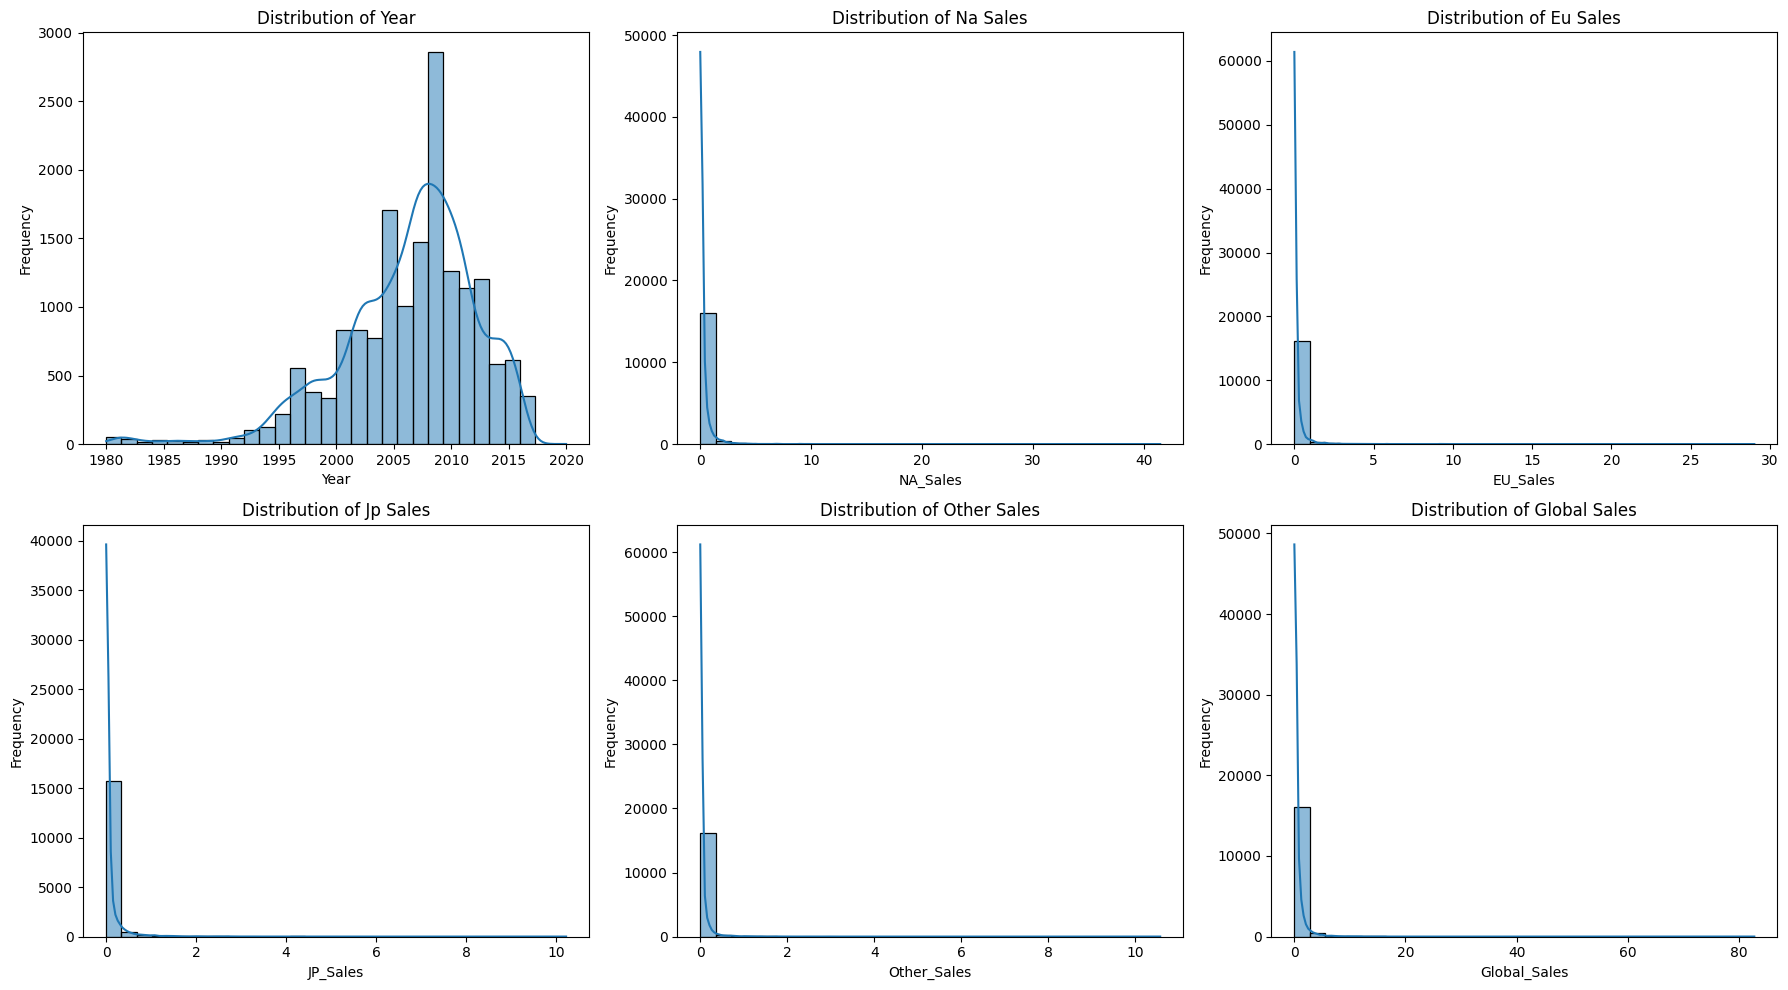

Insights: The distribution of game releases peaks around 2007-2010. Sales figures are highly skewed towards lower values, indicating a few blockbuster titles and many games with modest sales.


In [108]:
numerical_features_df10 = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

plt.figure(figsize=(18, 10))
for i, feature in enumerate(numerical_features_df10):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df10_cleaned[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("Insights: The distribution of game releases peaks around 2007-2010. Sales figures are highly skewed towards lower values, indicating a few blockbuster titles and many games with modest sales.")

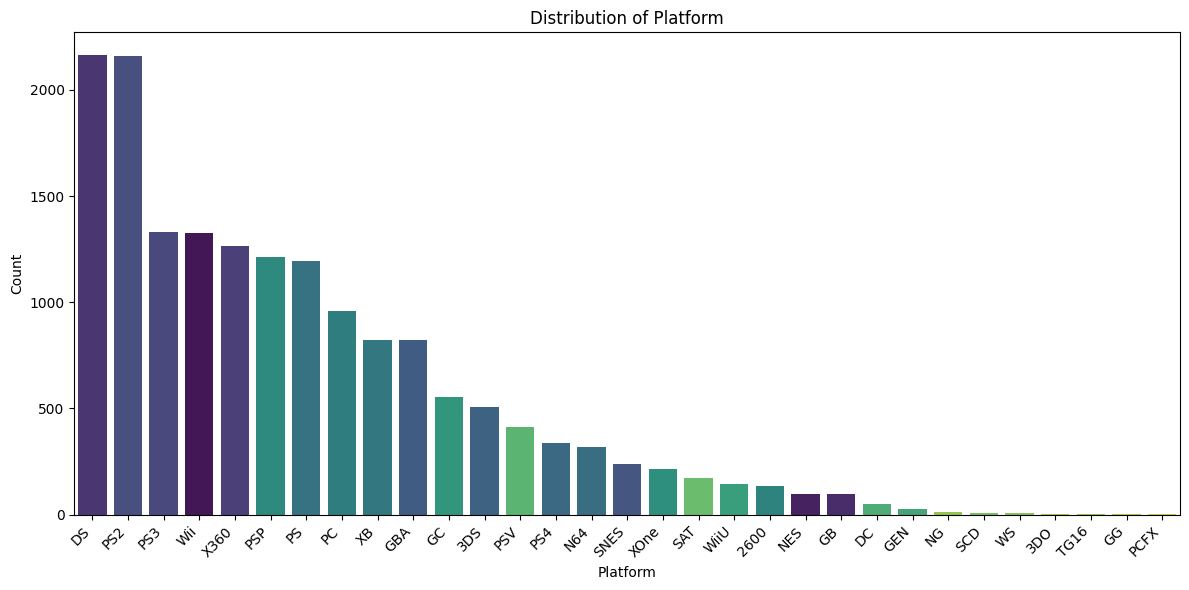

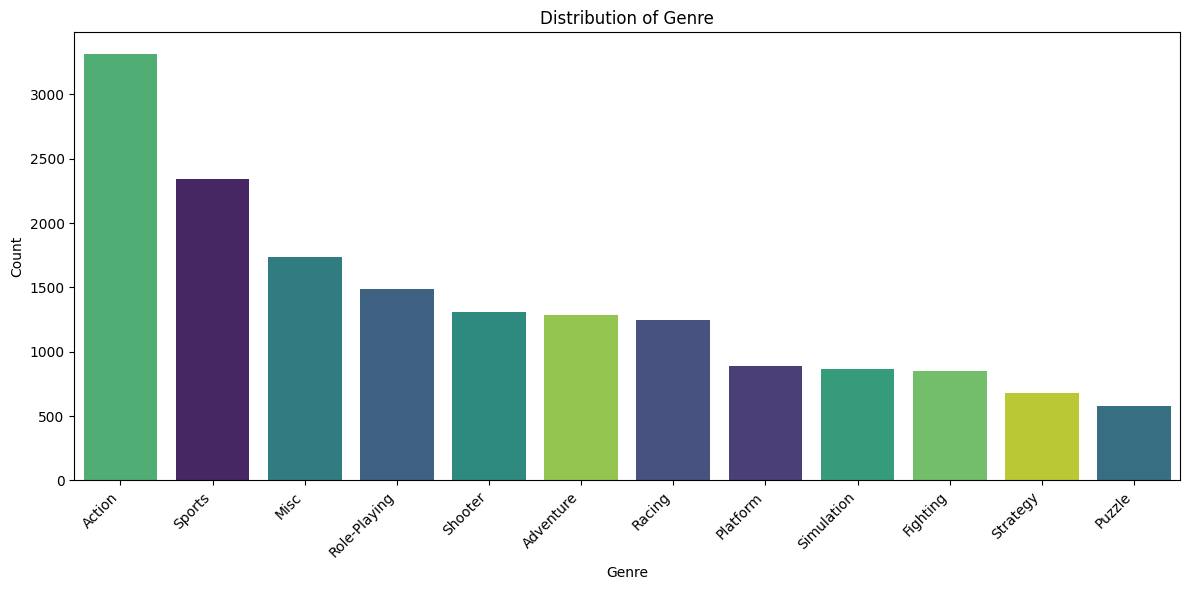

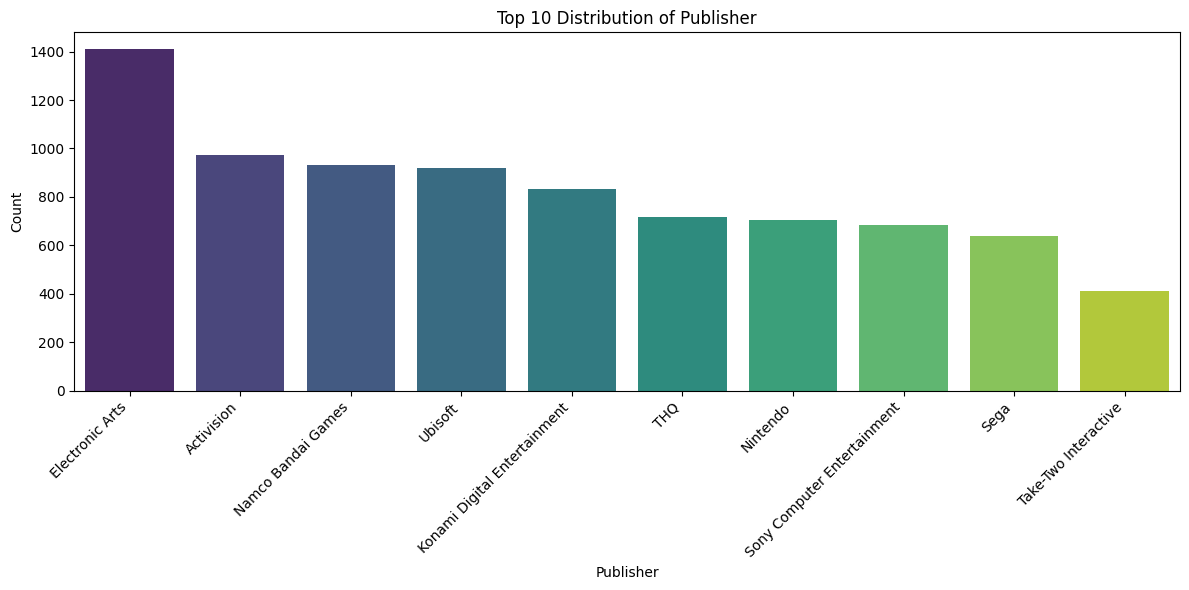

PlayStation platforms and Nintendo platforms are prominent. Action and Sports are the most common genres. Nintendo is the leading publisher.


In [109]:
categorical_features_df10 = ['Platform', 'Genre', 'Publisher']

for feature in categorical_features_df10:
    plt.figure(figsize=(12, 6))
    if feature == 'Publisher':
        top_10 = df10_cleaned[feature].value_counts().head(10)
        sns.barplot(x=top_10.index, y=top_10.values, palette='viridis', hue=top_10.index, legend=False)
        plt.title(f'Top 10 Distribution of {feature.replace("_", " ").title()}')
    else:
        sns.countplot(x=feature, data=df10_cleaned, palette='viridis', order=df10_cleaned[feature].value_counts().index, hue=df10_cleaned[feature], legend=False)
        plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("PlayStation platforms and Nintendo platforms are prominent. Action and Sports are the most common genres. Nintendo is the leading publisher.")

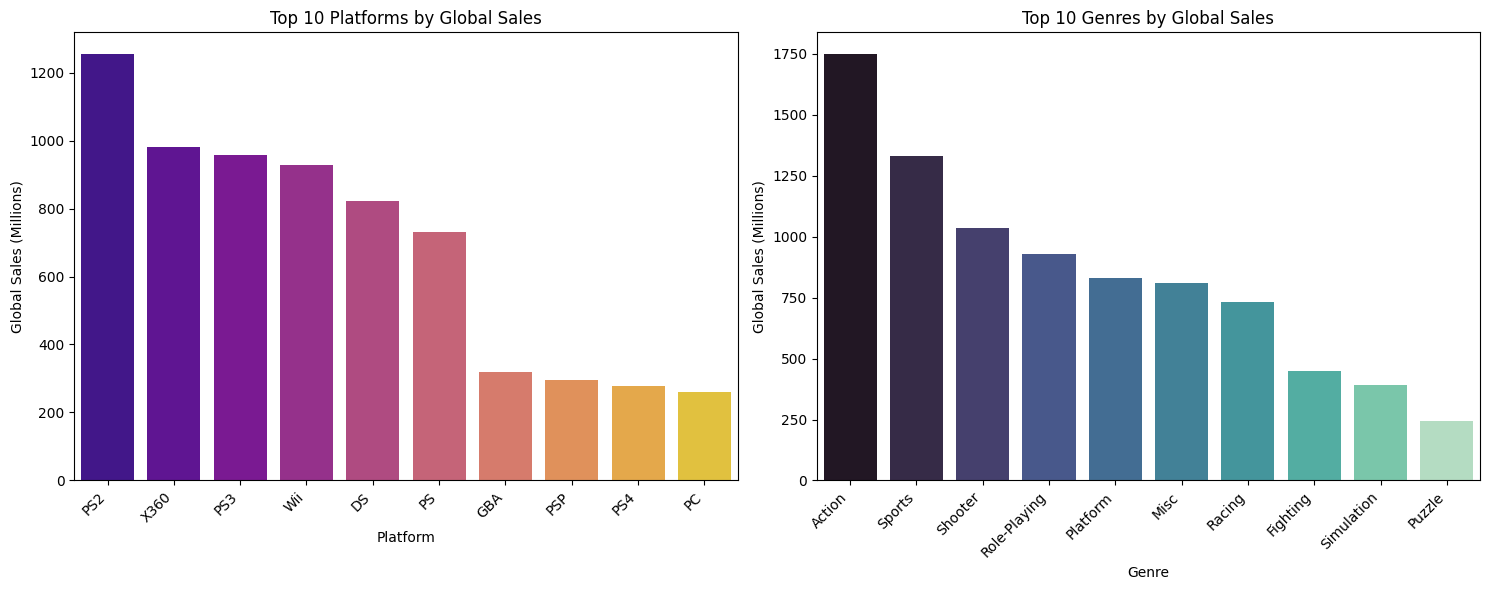

Insights: Wii and PS2 are among the highest-selling platforms, while Action and Sports are the highest-grossing genres.


In [110]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
platform_sales = df10_cleaned.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=platform_sales.index, y=platform_sales.values, palette='plasma', hue=platform_sales.index, legend=False)
plt.title('Top 10 Platforms by Global Sales')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
genre_sales = df10_cleaned.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='mako', hue=genre_sales.index, legend=False)
plt.title('Top 10 Genres by Global Sales')
plt.xlabel('Genre')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()
print("Insights: Wii and PS2 are among the highest-selling platforms, while Action and Sports are the highest-grossing genres.")

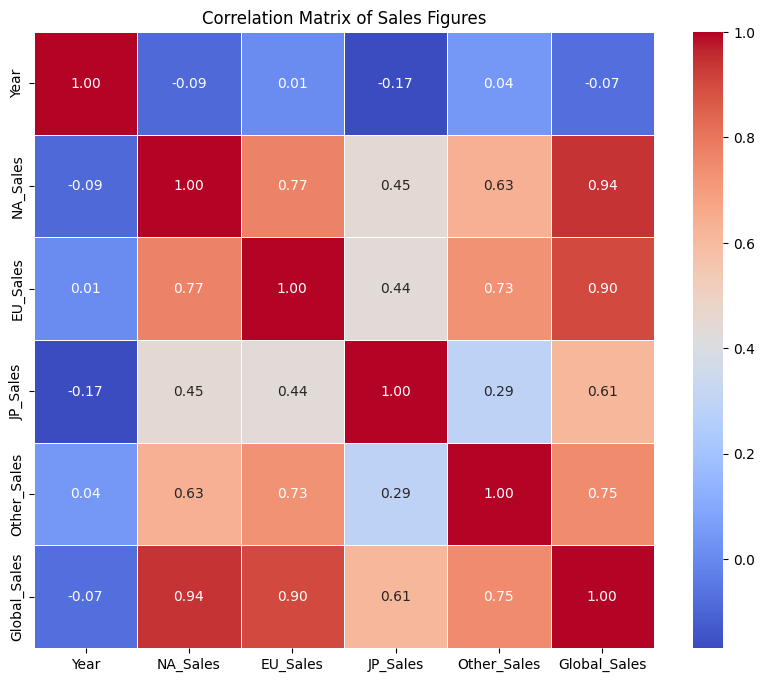

All regional sales figures are highly positively correlated with Global_Sales, as expected. NA_Sales and EU_Sales show the strongest correlations.


In [111]:
plt.figure(figsize=(10, 8))
correlation_matrix_df10 = df10_cleaned[numerical_features_df10].corr()
sns.heatmap(correlation_matrix_df10, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Sales Figures')
plt.show()
print("All regional sales figures are highly positively correlated with Global_Sales, as expected. NA_Sales and EU_Sales show the strongest correlations.")